# VoD 하이브리드 위험도 파이프라인 단일 Run-All 노트북

목표는 점수 미세 개선보다 **일관성/신뢰성/운영성 강화**입니다.

- Full mode: 분석/발표 중심
- Ops mode: burden 축소 중심
- 결과 저장: `results/tables`, `results/figures`, `results/artifacts`


## Section 0. 개요 및 실행 가이드

- 최종 summary는 반드시 본문의 honest anti-leakage 결과와 일치해야 함
- calibration은 조건부 채택(Brier/ECE/ranking/saturation 기준)
- temporal feature는 분포/효과/top-k 변화 사례로 실효성 검증
- ops는 `<20`, `<18`, `<15` 후보/frame 목표 실험 포함


## Section 1. 환경 설정 및 공통 유틸

## Section Guide (이론/입출력/검증 포인트)

이 노트북은 단순 실행 스크립트가 아니라 **실험 보고서형 문서**를 목표로 하며, 각 섹션은 다음 3요소를 반드시 포함한다.

- **이론(Why)**: 해당 단계가 필요한 이유와 실패 시 리스크
- **출력(What)**: 표/describe/head/plot으로 남겨야 할 결과
- **검증(How)**: assert/trace/비교표로 재현성과 정합성 점검

### 1) 환경 설정
- Why: 재현 가능한 실험 조건 고정
- What: 경로/seed/dependency/모드 출력
- How: 경로 존재/저장 디렉터리 확인

### 2) 데이터 로딩/EDA
- Why: 분포 편향/결측 확인 없이 모델링 금지
- What: head/describe/분포 plot/프레임 통계
- How: 샘플 수/핵심 컬럼 유효성 점검

### 3) 전처리
- Why: 노이즈 제거와 정보 보존 균형
- What: 전처리 전후 수량/비율/분포
- How: 과필터링 여부 검증

### 4) clustering
- Why: 안정적인 후보 생성이 핵심
- What: DBSCAN/HDBSCAN 품질 지표
- How: noise/cluster size/spread 비교

### 5) suppression
- Why: 중복 및 저품질 후보 제거로 burden 절감
- What: suppression 전후 후보 수/성능
- How: burden-성능 trade-off 확인

### 6) corroboration
- Why: LiDAR 보조 증거로 신뢰도 보강
- What: min_dist, multi-radius density, score
- How: none/binary/continuous ablation

### 7) tracking
- Why: 단일 프레임 노이즈를 시간축으로 보정
- What: track_len/fragmentation/speed/heading
- How: baseline vs improved 비교

### 8) rule risk
- Why: 해석 가능한 운영 baseline
- What: score 분포/threshold sensitivity
- How: high=0 방지 검증

### 9) feature sets / anti-leakage
- Why: 누설 방지 없이는 성능 해석 무의미
- What: feature set 정의/요약
- How: blacklist + rule-like + naming assert

### 10) splits / honest eval
- Why: random split 과대평가 방지
- What: group/time/contiguous split 요약
- How: high support 포함 sanity check

### 11) ML refinement
- Why: 최종 판정기가 아니라 보조 정렬기
- What: cls/reg/ranking 지표
- How: overfit gap + high recall + AP 동시 평가

### 12) calibration
- Why: 확률 해석 보정
- What: Brier/ECE/reliability/saturation
- How: raw 대비 개선 시에만 채택

### 13) hybrid score
- Why: rule+temporal+corroboration+ML 결합
- What: weight sweep/성능 변화
- How: rule_only 대비 솔직 비교

### 14) ranking
- Why: 불균형 환경에서 우선순위화가 실용적
- What: P@k/R@k/Hit@k/AP/NDCG/PR
- How: hard/soft positive 동시 검증

### 15) ablation
- Why: 구성요소 기여 분해
- What: 모듈 제거 시 성능/부담 변화
- How: 비교표와 사례 병행

### 16) runtime
- Why: 운영 가능성 판단 지표
- What: 단계별/모드별 소요시간
- How: 병목 구간 식별

### 17) explainability
- Why: 모델 신뢰성 확보
- What: feature importance/hard case
- How: hybrid가 유리한 사례 추적

### 18) temporal effectiveness
- Why: 시간축 특징의 실질 기여 검증
- What: 분포/상관/top-k 변화
- How: temporal 가중치 민감도 분석

### 19) final summary + source trace
- Why: 보고서 단일 진실원
- What: best_model_summary_overall/honest 분리
- How: source trace, anti-leakage assert, sanity check

### 20) 최종 한국어 결론
- Why: 결과 해석/한계/운영 권고 명확화
- What: research_full vs ops를 분리해 기술
- How: 과대해석 방지 문구 포함

In [1]:
from __future__ import annotations

import logging
import math
import os
import random
import sys
import warnings
from collections import defaultdict
from pathlib import Path
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from matplotlib.patches import Circle
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import DBSCAN
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

try:
    import hdbscan
    HDBSCAN_OK = True
except Exception:
    HDBSCAN_OK = False

NOTEBOOK_DIR = Path.cwd().resolve()
sys.path.insert(0, str(NOTEBOOK_DIR))

import bev_lidar_detector_train as bev
import vod_hybrid_pipeline_v2 as v2
from scipy.stats import kendalltau, spearmanr

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# 한글 폰트
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"
available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if Path(FONT_PATH).is_file():
    font_manager.fontManager.addfont(FONT_PATH)
    primary_font = font_manager.FontProperties(fname=FONT_PATH).get_name()
else:
    primary_font = "Malgun Gothic" if "Malgun Gothic" in available_fonts else None

font_candidates = [primary_font, "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
active_fonts = []
for fam in font_candidates:
    if fam and fam in available_fonts and fam not in active_fonts:
        active_fonts.append(fam)

sns.set_theme(style="whitegrid")
if active_fonts:
    rc("font", family=active_fonts)
    matplotlib.rcParams["font.family"] = active_fonts
rc("axes", unicode_minus=False)
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

print("ready:", NOTEBOOK_DIR)
print("active fonts:", matplotlib.rcParams.get("font.family"))
print("HDBSCAN available:", HDBSCAN_OK, "| SCIPY available:", SCIPY_OK)
if not HDBSCAN_OK:
    print("[안내] HDBSCAN 미설치 시 DBSCAN만 비교됩니다. 설치: python -m pip install hdbscan (동일 커널 환경)")
import vod_hybrid_pipeline_stage3 as s3

DEFAULT_ROOT = NOTEBOOK_DIR / "vod-received" / "view_of_delft_PUBLIC"
DATASET_ROOT = Path(os.environ.get("VOD_ROOT", str(DEFAULT_ROOT))).resolve()

RADAR_MODE = os.environ.get("VOD_RADAR_MODE", "5-scan")
MAX_FRAMES = int(os.environ.get("VOD_REDESIGN_MAX_FRAMES", "180"))
MAX_POINTS_PER_FRAME = int(os.environ.get("VOD_REDESIGN_MAX_POINTS_PER_FRAME", "2200"))

# ROI/전처리 파라미터
ROI = {
    "x_min": 0.0,
    "x_max": 70.0,
    "y_min": -35.0,
    "y_max": 35.0,
    "z_min": -3.5,
    "z_max": 4.0,
}
RCS_CLIP = (-35.0, 35.0)
SPEED_CLIP = (-25.0, 25.0)

# clustering
DBSCAN_EPS = float(os.environ.get("VOD_DBSCAN_EPS", "1.2"))
DBSCAN_MIN_SAMPLES = int(os.environ.get("VOD_DBSCAN_MIN_SAMPLES", "6"))
HDBSCAN_MIN_CLUSTER_SIZE = int(os.environ.get("VOD_HDBSCAN_MIN_CLUSTER_SIZE", "10"))

# LiDAR corroboration
LIDAR_VERIFY_RADIUS = float(os.environ.get("VOD_LIDAR_VERIFY_RADIUS", "1.8"))
LIDAR_DENSITY_RADIUS = float(os.environ.get("VOD_LIDAR_DENSITY_RADIUS", "2.0"))

# tracking
TRACK_GATE_DIST = float(os.environ.get("VOD_TRACK_GATE_DIST", "3.5"))
RADAR_DT_SEC = float(os.environ.get("VOD_RADAR_DT_SEC", str(1.0 / 13.0)))

frames_all = bev.list_vod_sync_frames(DATASET_ROOT, radar_mode=RADAR_MODE)
frames = [fr for fr in frames_all if fr["radar_path"] and Path(fr["radar_path"]).is_file()][:MAX_FRAMES]
if not frames:
    raise RuntimeError("Radar 프레임을 찾지 못했습니다. VOD_ROOT/RADAR_MODE 확인 필요")

frame_order_map = {fr["frame_id"]: i for i, fr in enumerate(frames)}
DEMO_FRAME_ID = os.environ.get("VOD_DEMO_FRAME", frames[len(frames)//2]["frame_id"])

print("DATASET_ROOT:", DATASET_ROOT)
print("RADAR_MODE:", RADAR_MODE)
print("사용 프레임:", len(frames), "/", len(frames_all))
print("DEMO_FRAME_ID:", DEMO_FRAME_ID)
RADAR_COLS = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "time"]


def preprocess_radar_points(pts: np.ndarray) -> np.ndarray:
    if pts.size == 0:
        return np.zeros((0, 7), dtype=np.float32)

    m = (
        (pts[:, 0] >= ROI["x_min"])
        & (pts[:, 0] <= ROI["x_max"])
        & (pts[:, 1] >= ROI["y_min"])
        & (pts[:, 1] <= ROI["y_max"])
        & (pts[:, 2] >= ROI["z_min"])
        & (pts[:, 2] <= ROI["z_max"])
    )
    out = pts[m].copy()
    if out.shape[0] == 0:
        return out

    out[:, 3] = np.clip(out[:, 3], RCS_CLIP[0], RCS_CLIP[1])
    out[:, 4] = np.clip(out[:, 4], SPEED_CLIP[0], SPEED_CLIP[1])
    out[:, 5] = np.clip(out[:, 5], SPEED_CLIP[0], SPEED_CLIP[1])

    # frame당 과도 포인트 샘플링
    if out.shape[0] > MAX_POINTS_PER_FRAME:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(out.shape[0], size=MAX_POINTS_PER_FRAME, replace=False)
        out = out[idx]

    return out


def build_radar_dataframe(frames_subset: list[dict[str, Any]]) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    frame_rows = []
    for fr in frames_subset:
        frame_id = fr["frame_id"]
        arr = bev.parse_radar_bin(Path(fr["radar_path"]))
        proc = preprocess_radar_points(arr)

        if proc.shape[0] > 0:
            df = pd.DataFrame(proc, columns=RADAR_COLS)
            df["frame_id"] = frame_id
            df["frame_order"] = int(frame_order_map[frame_id])
            rows.append(df)

        frame_rows.append(
            {
                "frame_id": frame_id,
                "frame_order": int(frame_order_map[frame_id]),
                "raw_points": int(arr.shape[0]),
                "processed_points": int(proc.shape[0]),
                "kept_ratio": float(proc.shape[0] / max(arr.shape[0], 1)),
            }
        )

    radar_df_local = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=RADAR_COLS + ["frame_id", "frame_order"])
    frame_summary_local = pd.DataFrame(frame_rows)

    if not radar_df_local.empty:
        radar_df_local["range_xy"] = np.hypot(radar_df_local["x"], radar_df_local["y"])
        radar_df_local["abs_vr_comp"] = radar_df_local["v_r_compensated"].abs()

    return radar_df_local, frame_summary_local


radar_df, frame_summary = build_radar_dataframe(frames)
print("radar_df shape:", radar_df.shape)
display(frame_summary.head())
display(radar_df.head())

print("\n[EDA summary]")
eda_cols = ["x", "y", "z", "RCS", "v_r", "v_r_compensated", "range_xy", "abs_vr_comp"]
display(radar_df[eda_cols].describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99]).T)

import importlib.util
from contextlib import contextmanager
import os

import vod_e2e_pipeline as e2e

OPT = {
    "hdbscan": HDBSCAN_OK,
    "shap": importlib.util.find_spec("shap") is not None,
    "xgboost": importlib.util.find_spec("xgboost") is not None,
    "lightgbm": importlib.util.find_spec("lightgbm") is not None,
    "catboost": importlib.util.find_spec("catboost") is not None,
}

RESULT_ROOT = NOTEBOOK_DIR / "results"
FIG_DIR = RESULT_ROOT / "figures"
TABLE_DIR = RESULT_ROOT / "tables"
ART_DIR = RESULT_ROOT / "artifacts"
for p in [RESULT_ROOT, FIG_DIR, TABLE_DIR, ART_DIR]:
    p.mkdir(parents=True, exist_ok=True)

runtime_records: list[dict[str, float | str]] = []

@contextmanager
def timed(stage: str):
    import time
    t0 = time.perf_counter()
    yield
    dt = time.perf_counter() - t0
    runtime_records.append({"stage": stage, "sec": float(dt)})
    print(f"[timed] {stage}: {dt:.3f}s")

NOTEBOOK_TAG = "v22"

def _tag_name(name: str, tag: str = NOTEBOOK_TAG) -> str:
    return name if name.endswith(f"_{tag}") else f"{name}_{tag}"

def save_table(df: pd.DataFrame, name: str):
    tagged = _tag_name(name)
    path = TABLE_DIR / f"{tagged}.csv"
    df.to_csv(path, index=False, encoding="utf-8-sig")
    return path

def save_fig(name: str):
    tagged = _tag_name(name)
    path = FIG_DIR / f"{tagged}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path

env_summary_df = pd.DataFrame(
    [{"key": k, "value": v} for k, v in {
        "NOTEBOOK_DIR": str(NOTEBOOK_DIR),
        "DATASET_ROOT": str(DATASET_ROOT),
        "RADAR_MODE": RADAR_MODE,
        "MAX_FRAMES": MAX_FRAMES,
        "MAX_POINTS_PER_FRAME": MAX_POINTS_PER_FRAME,
        **{f"opt_{k}": v for k, v in OPT.items()},
    }.items()]
)
display(env_summary_df)


ready: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit
active fonts: ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
HDBSCAN available: True | SCIPY available: True
DATASET_ROOT: C:\Users\taehu\Desktop\projects\hanhwa_final\vod-devkit\vod-received\view_of_delft_PUBLIC
RADAR_MODE: 5-scan
사용 프레임: 180 / 8682
DEMO_FRAME_ID: 00090
radar_df shape: (175703, 11)


,frame_id,frame_order,raw_points,processed_points,kept_ratio
0,00000,0,284,247,0.869718
1,00001,1,597,505,0.845896
2,00002,2,916,770,0.840611
3,00003,3,1242,1039,0.836554
4,00004,4,1590,1307,0.822013


,x,y,z,RCS,v_r,v_r_compensated,time,frame_id,frame_order,range_xy,abs_vr_comp
0,2.259143,-1.677923,-0.461345,-35.000000,-0.846359,0.003345,0.0,00000,0,2.814099,0.003345
1,2.892353,-1.702031,-0.484078,-35.000000,-0.945826,0.000521,0.0,00000,0,3.355982,0.000521
2,3.198316,-1.740433,-0.461826,-35.000000,-0.966848,0.008980,0.0,00000,0,3.641199,0.008980
3,5.296023,-1.029389,-0.228245,-21.281502,0.313759,1.494236,0.0,00000,0,5.395137,1.494236
4,4.892861,-1.705152,-0.610011,-31.324360,-1.089766,0.004509,0.0,00000,0,5.181470,0.004509



[EDA summary]


,count,mean,std,min,1%,10%,50%,90%,99%,max
x,175703.0,15.983723,11.847740,9.466823e-05,1.301708,3.633923,13.374722,31.994848,56.760800,69.993187
y,175703.0,-0.154490,7.879354,-3.499952e+01,-20.846053,-8.495228,-0.672569,8.886865,23.873991,34.993893
z,175703.0,0.124951,1.357401,-3.499551e+00,-2.959447,-1.330584,-0.116773,2.250831,3.751892,3.999733
RCS,175703.0,-12.368604,12.228426,-3.500000e+01,-35.000000,-29.210594,-12.427605,2.849743,20.241974,35.000000
v_r,175703.0,-1.348927,1.359421,-2.500000e+01,-3.378249,-2.302750,-1.564913,0.000000,1.655319,25.000000
v_r_compensated,175703.0,0.098715,1.219165,-2.480089e+01,-1.734941,-0.045923,0.000213,0.195696,3.763902,25.000000
range_xy,175703.0,17.563778,12.225785,8.306847e-02,1.901605,4.550952,14.670855,34.093372,58.514092,72.384438
abs_vr_comp,175703.0,0.286446,1.189141,1.815528e-07,0.000079,0.001003,0.007314,0.940383,3.885222,25.000000


,key,value
0,NOTEBOOK_DIR,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
1,DATASET_ROOT,C:\Users\taehu\Desktop\projects\hanhwa_final\v...
2,RADAR_MODE,5-scan
3,MAX_FRAMES,180
4,MAX_POINTS_PER_FRAME,2200
5,opt_hdbscan,True
6,opt_shap,False
7,opt_xgboost,False
8,opt_lightgbm,False
9,opt_catboost,False


## Section 2. 데이터 로딩 및 기본 EDA

[timed] section2_load_and_eda: 3.161s


,frame_id,frame_order,radar_points_processed,lidar_points
0,00000,0,247,178104
1,00001,1,505,178500
2,00002,2,770,179092
3,00003,3,1039,179140
4,00004,4,1307,179550


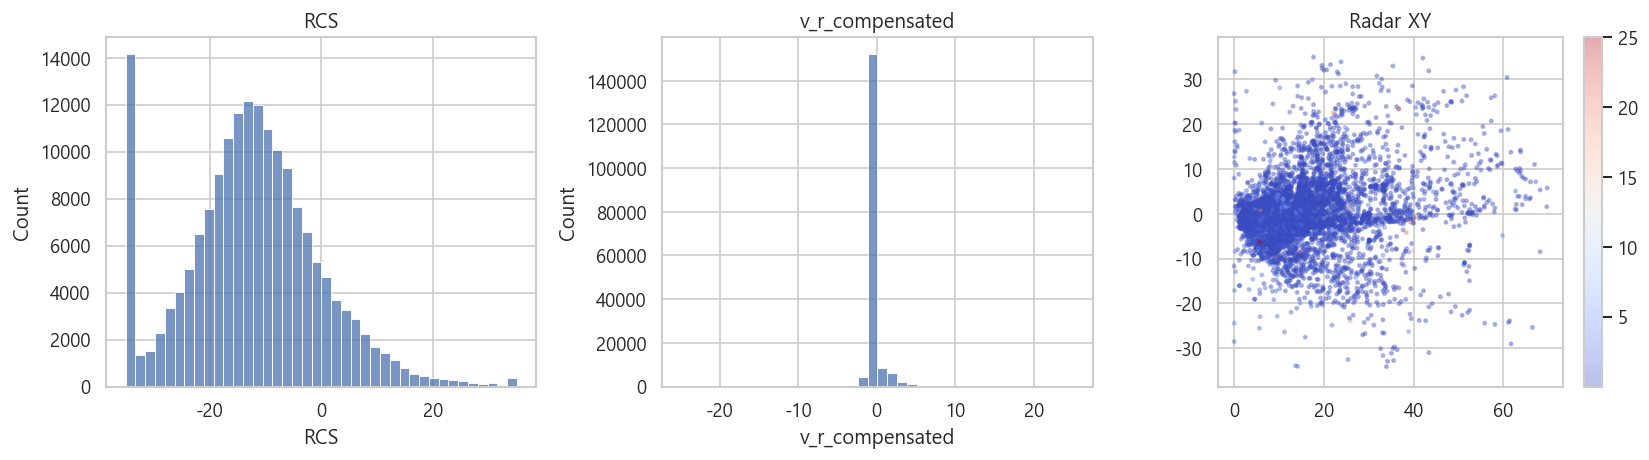

WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/sec2_frame_index_v22.csv')

In [2]:

with timed("section2_load_and_eda"):
    lidar_by_frame: dict[str, np.ndarray] = {}
    rows = []
    for fr in frames:
        fid = fr["frame_id"]
        lp = fr.get("lidar_path")
        larr = np.zeros((0, 4), dtype=np.float32)
        if lp and Path(lp).is_file():
            try:
                larr = bev.parse_lidar_bin(Path(lp))
            except Exception:
                larr = np.zeros((0, 4), dtype=np.float32)
        lidar_by_frame[fid] = larr
        rows.append(
            {
                "frame_id": fid,
                "frame_order": int(frame_order_map[fid]),
                "radar_points_processed": int(frame_summary.loc[frame_summary["frame_id"] == fid, "processed_points"].iloc[0]),
                "lidar_points": int(larr.shape[0]),
            }
        )
    frame_index_df = pd.DataFrame(rows).sort_values("frame_order").reset_index(drop=True)

display(frame_index_df.head())

# RCS
plt.figure(figsize=(6, 4))
sns.histplot(radar_df["RCS"], bins=40)
plt.title("RCS")
plt.tight_layout()
save_fig("sec2_basic_eda_rcs")
plt.show()

# v_r_compensated
plt.figure(figsize=(6, 4))
sns.histplot(radar_df["v_r_compensated"], bins=40)
plt.title("v_r_compensated")
plt.tight_layout()
save_fig("sec2_basic_eda_vr_comp")
plt.show()

# Radar XY
sxy = radar_df.sample(min(6000, len(radar_df)), random_state=SEED)
plt.figure(figsize=(6, 4))
sc = plt.scatter(sxy["x"], sxy["y"], c=sxy["abs_vr_comp"], s=4, alpha=0.35, cmap="coolwarm")
plt.axis("equal")
plt.title("Radar XY")
plt.colorbar(sc)
plt.tight_layout()
save_fig("sec2_basic_eda_xy")
plt.show()

save_table(frame_index_df, "sec2_frame_index")


## Section 3. Radar 전처리

[timed] section3_preprocess: 0.010s


,metric,value
0,n_raw_total,199319.000000
1,n_clean_total,175703.000000
2,keep_ratio_global,0.881517
3,keep_ratio_mean_frame,0.904775


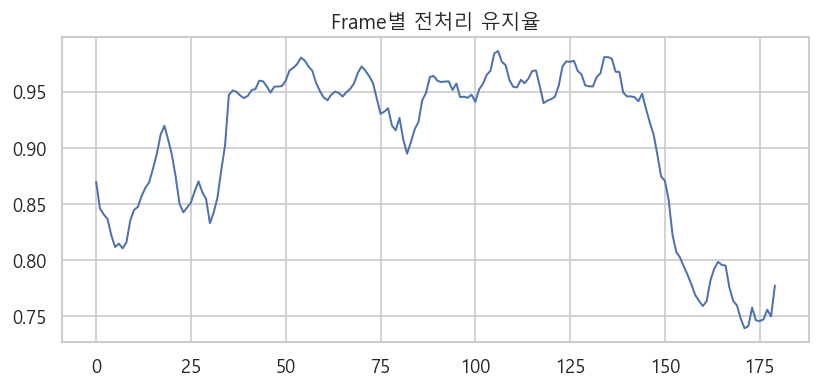

WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/sec3_preprocess_summary_v22.csv')

In [3]:

with timed("section3_preprocess"):
    radar_df_clean = radar_df.copy()
    preproc_summary_df = pd.DataFrame(
        [
            {"metric": "n_raw_total", "value": int(frame_summary["raw_points"].sum())},
            {"metric": "n_clean_total", "value": int(len(radar_df_clean))},
            {"metric": "keep_ratio_global", "value": float(len(radar_df_clean) / max(frame_summary["raw_points"].sum(), 1))},
            {"metric": "keep_ratio_mean_frame", "value": float(frame_summary["kept_ratio"].mean())},
        ]
    )
display(preproc_summary_df)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(frame_summary["frame_order"], frame_summary["kept_ratio"], lw=1.2)
ax.set_title("Frame별 전처리 유지율")
plt.tight_layout(); save_fig("sec3_keep_ratio"); plt.show()
save_table(preproc_summary_df, "sec3_preprocess_summary")


## Section 4. Candidate generation

[timed] section4_candidate_generation: 21.291s


,algorithm,cluster_count,noise_ratio,mean_trackable_size_proxy,mean_spread_xy,mean_clusters_per_frame,quality_score
0,hdbscan,7561,0.224032,18.046951,0.741456,42.005556,0.975227
1,dbscan,2107,0.062720,78.592311,2.130424,11.705556,0.403371


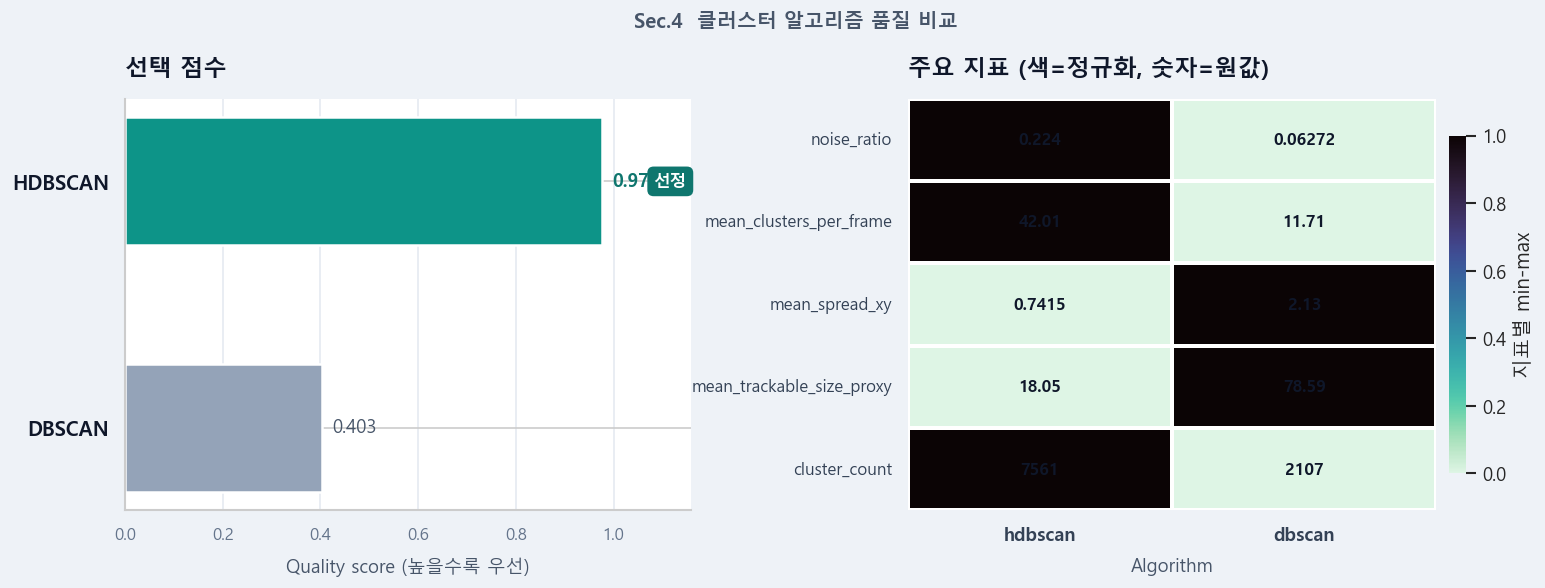

In [4]:

with timed("section4_candidate_generation"):
    methods = ["dbscan"] + (["hdbscan"] if OPT["hdbscan"] else [])
    cluster_df_all, cluster_quality = s3.build_cluster_tables(radar_df_clean, methods)
    rows = []
    for alg in sorted(cluster_df_all["algorithm"].unique()):
        sub = cluster_df_all[cluster_df_all["algorithm"] == alg]
        fq = cluster_quality[cluster_quality["algorithm"] == alg]
        rows.append(
            {
                "algorithm": alg,
                "cluster_count": int(len(sub)),
                "noise_ratio": float(fq["noise_ratio"].mean()) if not fq.empty else np.nan,
                "mean_trackable_size_proxy": float(sub["n_points"].mean()),
                "mean_spread_xy": float(sub["spread_xy"].mean()),
                "mean_clusters_per_frame": float(fq["n_clusters"].mean()) if not fq.empty else np.nan,
            }
        )
    cluster_algo_summary = pd.DataFrame(rows)
    cluster_algo_summary["quality_score"] = (
        -cluster_algo_summary["noise_ratio"].fillna(1.0)
        + 0.04 * cluster_algo_summary["mean_clusters_per_frame"].fillna(0).clip(0, 30)
        - 0.001 * cluster_algo_summary["mean_spread_xy"].fillna(0)
    )
    cluster_algo_summary = cluster_algo_summary.sort_values("quality_score", ascending=False).reset_index(drop=True)
    selected_cluster_algo = str(cluster_algo_summary.iloc[0]["algorithm"])
    cluster_df_raw = cluster_df_all[cluster_df_all["algorithm"] == selected_cluster_algo].copy().reset_index(drop=True)
display(cluster_algo_summary)
save_table(cluster_algo_summary, "sec4_cluster_algo_summary")

# Sec4: 발표용 클러스터 알고리즘 비교 시각화
if not cluster_algo_summary.empty:
    winner = str(cluster_algo_summary.iloc[0]["algorithm"])
    dord = cluster_algo_summary.sort_values("quality_score", ascending=True)
    fig = plt.figure(figsize=(13.0, 5.2), facecolor="#eef2f7")
    gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.18], wspace=0.36, left=0.07, right=0.98, top=0.82, bottom=0.16)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])

    y = np.arange(len(dord))
    qs = dord["quality_score"].astype(float).to_numpy()
    names = dord["algorithm"].astype(str).to_numpy()
    bar_colors = np.where(names == winner, "#0d9488", "#94a3b8")
    ax0.barh(y, qs, height=0.52, color=bar_colors, edgecolor="white", linewidth=1.5, zorder=2)
    ax0.axvline(0, color="#cbd5e1", lw=1.0, zorder=0)
    ax0.set_yticks(y, [n.upper() for n in names])
    for t in ax0.get_yticklabels():
        t.set_fontsize(12)
        t.set_fontweight("semibold")
        t.set_color("#0f172a")
    ax0.set_xlabel("Quality score (높을수록 우선)", fontsize=11, color="#475569", labelpad=8)
    ax0.set_title("선택 점수", loc="left", fontsize=14, fontweight="bold", color="#0f172a", pad=14)
    ax0.set_facecolor("#ffffff")
    ax0.grid(axis="x", color="#e2e8f0", linestyle="-", linewidth=0.9, zorder=1)
    ax0.tick_params(axis="x", colors="#64748b", labelsize=10)
    x0, x1 = ax0.get_xlim()
    pad = max((x1 - x0) * 0.06, 0.025)
    ax0.set_xlim(x0, x1 + pad * 2.2)
    for yi, sc, nm in zip(y, qs, names):
        ax0.text(
            sc + pad * 0.35,
            yi,
            f"{sc:.3f}",
            va="center",
            fontsize=11,
            fontweight="bold" if nm == winner else "medium",
            color="#0f766e" if nm == winner else "#475569",
        )
    wi = int(np.where(names == winner)[0][0])
    ax0.text(
        ax0.get_xlim()[1] - pad * 0.15,
        wi,
        "선정",
        fontsize=10,
        fontweight="bold",
        color="white",
        va="center",
        ha="right",
        bbox=dict(boxstyle="round,pad=0.38", facecolor="#0f766e", edgecolor="none"),
    )
    sns.despine(ax=ax0, left=False, bottom=False)

    metric_cols = [
        "noise_ratio",
        "mean_clusters_per_frame",
        "mean_spread_xy",
        "mean_trackable_size_proxy",
        "cluster_count",
    ]
    heat = cluster_algo_summary.set_index("algorithm")[metric_cols].astype(float)
    denom = (heat.max(axis=0) - heat.min(axis=0)).replace(0, np.nan)
    heat_norm = ((heat - heat.min(axis=0)) / denom).fillna(0.5)
    ann = np.vectorize(lambda x: f"{x:.4g}")(heat.T.to_numpy())
    try:
        _cmap = sns.color_palette("mako_r", as_cmap=True)
    except Exception:
        _cmap = "viridis"
    sns.heatmap(
        heat_norm.T,
        annot=ann,
        fmt="",
        cmap=_cmap,
        ax=ax1,
        linewidths=1.4,
        linecolor="white",
        cbar_kws={"label": "지표별 min-max", "shrink": 0.82, "pad": 0.02},
        annot_kws={"fontsize": 10, "fontweight": "semibold", "color": "#0f172a"},
    )
    ax1.set_title("주요 지표 (색=정규화, 숫자=원값)", loc="left", fontsize=14, fontweight="bold", color="#0f172a", pad=14)
    ax1.set_xlabel("Algorithm", fontsize=11, color="#475569", labelpad=8)
    ax1.set_ylabel("")
    ax1.set_facecolor("#ffffff")
    ax1.tick_params(axis="x", labelsize=11, colors="#334155")
    ax1.tick_params(axis="y", labelsize=10, colors="#334155")
    plt.setp(ax1.get_xticklabels(), fontweight="semibold")
    fig.suptitle(
        "Sec.4  클러스터 알고리즘 품질 비교",
        fontsize=12,
        fontweight="bold",
        color="#475569",
        y=0.96,
    )
    save_fig("sec4_cluster_algo_summary_viz")
    plt.show()


## Section 5. Candidate suppression (stronger ops 포함)

[timed] section5_suppression: 1.316s


,stage,n_candidates,remove_ratio,mode,topk_useful_keep_proxy
0,raw,7561,0.000000,full,0.00
1,S1_geometric,7561,0.000000,full,0.00
2,S2_temporal,7185,0.049729,full,0.00
3,S3_utility,6088,0.194816,full,0.00
4,raw,7561,0.000000,ops,0.02
5,S1_geometric,7561,0.000000,ops,0.02
6,S2_temporal,6629,0.123264,ops,0.02
7,S3_utility,4497,0.405237,ops,0.02
8,raw_ops_base,4497,0.000000,ops_t20,NaN
9,extra_gate_0.62,2370,0.472982,ops_t20,NaN


,mode,n_candidates_after_suppression,candidates_per_frame_after_suppression
4,ops_t15,1758,9.766667
3,ops_t18,2064,11.466667
2,ops_t20,2370,13.166667
1,ops,4497,24.983333
0,full,6088,33.822222


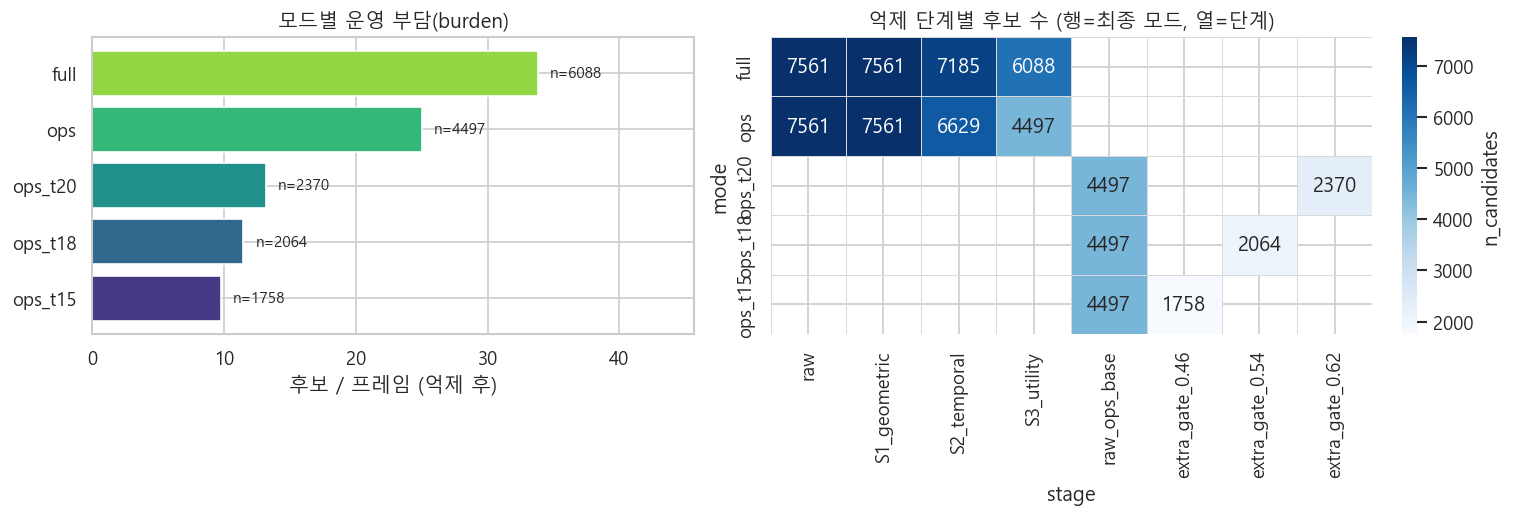

In [5]:

with timed("section5_suppression"):
    sup_full, sum_full = e2e.suppress_candidates(cluster_df_raw, mode="full")
    sup_ops, sum_ops = e2e.suppress_candidates(cluster_df_raw, mode="ops")

    suppressed_by_mode = {"full": sup_full, "ops": sup_ops}
    suppression_by_mode = {"full": sum_full, "ops": sum_ops}

    # stronger ops targets: <20 / <18 / <15 후보/frame 목표
    target_keep = {"ops_t20": 0.62, "ops_t18": 0.54, "ops_t15": 0.46}
    for m, frac in target_keep.items():
        d = s3.gate_top_fraction(sup_ops.copy(), keep_fraction=frac)
        d = d[d["proposal_quality_score"] >= d["proposal_quality_score"].quantile(0.15)].copy()
        suppressed_by_mode[m] = d.reset_index(drop=True)
        suppression_by_mode[m] = pd.DataFrame(
            [
                {"stage": "raw_ops_base", "n_candidates": int(len(sup_ops)), "remove_ratio": 0.0, "mode": m},
                {"stage": f"extra_gate_{frac:.2f}", "n_candidates": int(len(d)), "remove_ratio": float(1 - len(d) / max(len(sup_ops), 1)), "mode": m},
            ]
        )

    suppression_summary_df = pd.concat(list(suppression_by_mode.values()), ignore_index=True)
    frame_n = max(frame_summary["frame_id"].nunique(), 1)
    ops_burden_preview_df = pd.DataFrame(
        [
            {"mode": m, "n_candidates_after_suppression": int(len(dfm)), "candidates_per_frame_after_suppression": float(len(dfm) / frame_n)}
            for m, dfm in suppressed_by_mode.items()
        ]
    ).sort_values("candidates_per_frame_after_suppression")

display(suppression_summary_df)
display(ops_burden_preview_df)
save_table(suppression_summary_df, "sec5_suppression_summary")
save_table(ops_burden_preview_df, "sec5_ops_burden_preview")

# Sec5: 억제 단계·모드별 부담 시각화
if not ops_burden_preview_df.empty and not suppression_summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)
    b = ops_burden_preview_df.sort_values("candidates_per_frame_after_suppression", ascending=True)
    pal = sns.color_palette("viridis", n_colors=len(b))
    y = np.arange(len(b))
    axes[0].barh(y, b["candidates_per_frame_after_suppression"], color=pal)
    axes[0].set_yticks(y, b["mode"].astype(str))
    axes[0].set_xlabel("후보 / 프레임 (억제 후)")
    axes[0].set_title("모드별 운영 부담(burden)")
    xmax = float(b["candidates_per_frame_after_suppression"].max()) * 1.35
    axes[0].set_xlim(0, max(xmax, 1e-6))
    for yi, (_, row) in zip(y, b.iterrows()):
        axes[0].text(
            float(row["candidates_per_frame_after_suppression"]) + xmax * 0.02,
            float(yi),
            f"n={int(row['n_candidates_after_suppression'])}",
            va="center",
            fontsize=9,
        )

    def _stage_sort_key(s: str) -> tuple:
        order = ["raw", "S1_geometric", "S2_temporal", "S3_utility", "raw_ops_base"]
        if s in order:
            return (0, order.index(s))
        if str(s).startswith("extra_gate"):
            try:
                return (1, float(str(s).rsplit("_", 1)[-1]))
            except ValueError:
                return (1, 0.0)
        return (2, str(s))

    stages = sorted(suppression_summary_df["stage"].unique().tolist(), key=_stage_sort_key)
    modes = ops_burden_preview_df.sort_values("candidates_per_frame_after_suppression", ascending=False)[
        "mode"
    ].astype(str).tolist()
    pv = suppression_summary_df.pivot_table(
        index="mode", columns="stage", values="n_candidates", aggfunc="first"
    )
    pv = pv.reindex(index=modes, columns=stages)
    mask = pv.isna()
    sns.heatmap(
        pv.astype(float),
        mask=mask,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        ax=axes[1],
        cbar_kws={"label": "n_candidates"},
        linewidths=0.5,
        linecolor="0.85",
    )
    axes[1].set_title("억제 단계별 후보 수 (행=최종 모드, 열=단계)")
    axes[1].set_xlabel("stage")
    axes[1].set_ylabel("mode")
    save_fig("sec5_suppression_burden_and_stages")
    plt.show()


## Section 6. Dual pipeline 실행 (full / ops / ops_t20 / ops_t18 / ops_t15)

In [6]:

with timed("section6_dual_pipeline"):
    frame_by_id = {fr["frame_id"]: fr for fr in frames}
    RESULTS = {}
    modes_to_run = ["full", "ops", "ops_t20", "ops_t18", "ops_t15"]
    for m in modes_to_run:
        RESULTS[m] = e2e.run_branch(
            suppressed_by_mode[m],
            suppression_by_mode[m],
            mode=m,
            frames=frames,
            frame_by_id=frame_by_id,
            roi=ROI,
            track_gate_dist=TRACK_GATE_DIST,
            seed=SEED,
            opt=OPT,
        )
for m, R in RESULTS.items():
    print("===", m, "clusters", len(R.cluster_df_suppressed), "tracked rows", len(R.cluster_df_tracked))


[timed] section6_dual_pipeline: 764.100s
=== full clusters 6088 tracked rows 6088
=== ops clusters 4497 tracked rows 4497
=== ops_t20 clusters 2370 tracked rows 2370
=== ops_t18 clusters 2064 tracked rows 2064
=== ops_t15 clusters 1758 tracked rows 1758


## Section 7. Tracking summary (분포 지표 포함)

In [7]:

for m, R in RESULTS.items():
    display(R.tracking_summary_df.assign(mode=m))
    save_table(R.tracking_summary_df, f"sec7_tracking_summary_{m}")


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,full,528,11.530303,0.176136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,full,470,12.953191,0.114894,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,ops,435,10.337931,0.211494,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ops,355,12.667606,0.098592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,ops_t20,291,8.14433,0.264605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ops_t20,250,9.48000,0.124000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,ops_t18,267,7.730337,0.314607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ops_t18,231,8.935065,0.173160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,mode,n_tracks,mean_track_len,fragmentation,approach_score_mean,approach_score_std,approach_score_median,approach_score_p90,approach_score_min,approach_score_max,approach_score_nonzero_ratio,temporal_stability_mean,temporal_stability_std,temporal_stability_median,temporal_stability_p90,temporal_stability_min,temporal_stability_max,temporal_stability_nonzero_ratio
0,ops_t15,247,7.117409,0.319838,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ops_t15,202,8.702970,0.207921,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Section 8. Rule risk / threshold sensitivity

In [8]:

for m, R in RESULTS.items():
    display(R.threshold_sensitivity_df.head())
    display(R.track_threshold_sensitivity_df.head())
    save_table(R.threshold_sensitivity_df, f"sec8_threshold_sensitivity_cluster_{m}")
    save_table(R.track_threshold_sensitivity_df, f"sec8_threshold_sensitivity_track_{m}")


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,6071,17,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,5215,730,143,1.0,0.0,3.964491,0.562154
2,quantile_only_q0.92,4992,609,487,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,5114,608,366,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,5235,609,244,NaN,NaN,NaN,NaN


,setting,n_low,n_medium,n_high,n_tracks
0,track_quantile_0.9,366,57,47,470
1,track_quantile_0.93,380,57,33,470
2,track_quantile_0.96,394,57,19,470
3,track_quantile_0.98,404,56,10,470


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,4486,11,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,3852,539,106,1.0,0.0,3.729895,0.566554
2,quantile_only_q0.92,3687,450,360,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,3777,450,270,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,3867,450,180,NaN,NaN,NaN,NaN


,setting,n_low,n_medium,n_high,n_tracks
0,track_quantile_0.9,277,42,36,355
1,track_quantile_0.93,287,43,25,355
2,track_quantile_0.96,298,42,15,355
3,track_quantile_0.98,305,42,8,355


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,2364,6,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,2030,284,56,1.0,0.0,3.121656,0.569458
2,quantile_only_q0.92,1943,237,190,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,1990,237,143,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,2038,237,95,NaN,NaN,NaN,NaN


,setting,n_low,n_medium,n_high,n_tracks
0,track_quantile_0.9,195,30,25,250
1,track_quantile_0.93,202,30,18,250
2,track_quantile_0.96,210,30,10,250
3,track_quantile_0.98,215,30,5,250


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,2059,5,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,1768,247,49,1.0,0.0,3.106938,0.570658
2,quantile_only_q0.92,1692,206,166,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,1733,207,124,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,1775,206,83,NaN,NaN,NaN,NaN


,setting,n_low,n_medium,n_high,n_tracks
0,track_quantile_0.9,180,27,24,231
1,track_quantile_0.93,187,27,17,231
2,track_quantile_0.96,194,27,10,231
3,track_quantile_0.98,198,28,5,231


,setting,n_low,n_medium,n_high,avg_track_len_high,avg_approach_high,avg_ttc_high,avg_lidar_cor_high
0,fixed_0.70_0.42,1754,4,0,NaN,NaN,NaN,NaN
1,hybrid_quantile,1506,210,42,1.0,0.0,3.103474,0.573037
2,quantile_only_q0.92,1441,176,141,NaN,NaN,NaN,NaN
3,quantile_only_q0.94,1476,176,106,NaN,NaN,NaN,NaN
4,quantile_only_q0.96,1512,175,71,NaN,NaN,NaN,NaN


,setting,n_low,n_medium,n_high,n_tracks
0,track_quantile_0.9,157,24,21,202
1,track_quantile_0.93,163,24,15,202
2,track_quantile_0.96,169,24,9,202
3,track_quantile_0.98,173,24,5,202


## Section 9. Anti-leakage feature set 검증

In [9]:

R0 = RESULTS["full"]
display(R0.feature_set_summary_df)
save_table(R0.feature_set_summary_df, "sec9_feature_set_summary")

SUSPECT_PATTERNS = ["future", "target", "label", "gt", "oracle", "leak"]
ANTI_LEAKAGE_SET = {"A_strict_anti_leakage", "B_moderate_anti_leakage"}

for fs, cols in R0.feature_set_dict.items():
    cols_set = set(cols)
    # 1) 명시 블랙리스트
    assert cols_set.isdisjoint(e2e.LEAKAGE_BLACKLIST), f"blacklist leakage in {fs}: {cols_set & e2e.LEAKAGE_BLACKLIST}"
    # 2) rule-like score 변수
    if fs in ANTI_LEAKAGE_SET:
        assert not (cols_set & e2e.RULE_SCORE_LIKE), f"rule-like leakage in {fs}: {cols_set & e2e.RULE_SCORE_LIKE}"
    # 3) 이름 패턴 기반 추가 점검
    risky = [c for c in cols if any(p in str(c).lower() for p in SUSPECT_PATTERNS)]
    if fs in ANTI_LEAKAGE_SET:
        assert len(risky) == 0, f"suspicious leakage-like naming in {fs}: {risky}"

print("[anti-leakage assert] feature-set level 검사 통과")

# best row가 anti-leakage 조건을 위반하지 않는지 추가 검증
for m, R in RESULTS.items():
    hb = R.honest_best_row
    if hb is None or len(hb) == 0:
        continue
    fs = str(hb["feature_set"])
    sp = str(hb["split"])
    assert fs in ANTI_LEAKAGE_SET, f"[{m}] honest_best_row feature_set not anti-leakage: {fs}"
    assert sp in e2e.HONEST_SPLITS, f"[{m}] honest_best_row split not honest: {sp}"

print("[anti-leakage assert] best-row level 검사 통과")

,feature_set,n_features,contains_leakage_core,contains_ttc,contains_range_xy,contains_abs_vr_comp,contains_rule_score_like_feature,anti_leakage_passed,sample_features
0,A_strict_anti_leakage,31,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
1,B_moderate_anti_leakage,37,False,False,False,False,False,True,"spread_xy, density_proxy, n_points, mean_rcs, ..."
2,C_diagnostic_leakage,39,True,False,False,False,True,False,"spread_xy, density_proxy, n_points, mean_rcs, ..."


[anti-leakage assert] feature-set level 검사 통과
[anti-leakage assert] best-row level 검사 통과


## Section 10. Honest split summary

In [10]:

for m, R in RESULTS.items():
    display(R.split_summary_df.assign(mode=m))
    save_table(R.split_summary_df, f"sec10_split_summary_{m}")


,split,n_train,n_test,train_high,test_high,mode
0,group_frame,4549,1539,110,33,full
1,time,4560,1528,103,40,full
2,contiguous_block,4079,2009,87,56,full


,split,n_train,n_test,train_high,test_high,mode
0,group_frame,3398,1099,85,21,ops
1,time,3361,1136,82,24,ops
2,contiguous_block,2986,1511,76,30,ops


,split,n_train,n_test,train_high,test_high,mode
0,group_frame,1735,635,44,12,ops_t20
1,time,1772,598,47,9,ops_t20
2,contiguous_block,1574,796,44,12,ops_t20


,split,n_train,n_test,train_high,test_high,mode
0,group_frame,1507,557,38,11,ops_t18
1,time,1535,529,43,6,ops_t18
2,contiguous_block,1361,703,43,6,ops_t18


,split,n_train,n_test,train_high,test_high,mode
0,group_frame,1292,466,38,4,ops_t15
1,time,1318,440,41,1,ops_t15
2,contiguous_block,1175,583,41,1,ops_t15


## Section 11. ML refinement (honest anti-leakage)

In [11]:

for m, R in RESULTS.items():
    display(R.experiment_results_df.head(40))
    display(pd.DataFrame([R.honest_best_row]).assign(mode=m))
    save_table(R.experiment_results_df, f"sec11_experiment_results_{m}")


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,group_frame,0.917697,0.787879,0.529878,1.0,0.644444,-0.097206,NaN,NaN
1,classification,rf,A_strict_anti_leakage,group_frame,0.967079,0.878788,0.553846,1.0,0.644444,0.032921,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.950618,0.848485,0.472348,1.0,0.644444,-0.003018,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,group_frame,0.984043,0.939394,0.587849,1.0,0.688889,0.015957,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.934586,NaN,NaN,NaN,0.005570,0.962576
5,regression,hgb_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.918761,NaN,NaN,NaN,0.005573,0.968713
6,classification,logreg,A_strict_anti_leakage,time,0.694502,0.275000,0.642061,0.8,0.517241,0.176551,NaN,NaN
7,classification,rf,A_strict_anti_leakage,time,0.690920,0.250000,0.673098,0.9,0.379310,0.309080,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,time,0.863015,0.650000,0.573319,1.0,1.068966,0.092886,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,time,0.597850,0.125000,0.668139,0.7,0.275862,0.402150,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,mode
21,classification,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.81905,1.0,0.688889,0.015957,NaN,NaN,0.935417,full


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,group_frame,0.923610,0.809524,0.527063,1.0,0.422222,-0.162484,NaN,NaN
1,classification,rf,A_strict_anti_leakage,group_frame,0.974537,0.904762,0.411484,1.0,0.422222,0.025463,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.975727,0.952381,0.435269,1.0,0.466667,-0.007730,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,group_frame,0.987573,0.952381,0.453802,1.0,0.444444,0.012427,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.927410,NaN,NaN,NaN,0.004831,0.949021
5,regression,hgb_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.910947,NaN,NaN,NaN,0.005236,0.951911
6,classification,logreg,A_strict_anti_leakage,time,0.725374,0.541667,0.579886,0.7,1.185185,0.094049,NaN,NaN
7,classification,rf,A_strict_anti_leakage,time,0.494662,0.000000,0.433042,0.5,0.000000,0.505338,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,time,0.680755,0.375000,0.537674,0.4,0.888889,0.286016,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,time,0.491723,0.000000,0.390374,0.0,0.481481,0.508277,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,mode
18,classification,logreg,B_moderate_anti_leakage,group_frame,1.0,1.0,0.750812,1.0,0.466667,-0.01831,NaN,NaN,0.950162,ops


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,group_frame,0.847600,0.583333,0.585029,0.7,0.177778,-0.143204,NaN,NaN
1,classification,rf,A_strict_anti_leakage,group_frame,0.898400,0.666667,0.475531,0.8,0.177778,0.101600,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.812992,0.500000,0.497784,0.7,0.155556,0.149537,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,group_frame,0.861233,0.666667,0.591805,0.8,0.222222,0.138767,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.854562,NaN,NaN,NaN,0.004746,0.948906
5,regression,hgb_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.824414,NaN,NaN,NaN,0.004831,0.951881
6,classification,logreg,A_strict_anti_leakage,time,0.574801,0.222222,0.369496,0.1,0.555556,0.202426,NaN,NaN
7,classification,rf,A_strict_anti_leakage,time,0.495784,0.000000,0.376133,0.2,0.037037,0.504216,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,time,0.548764,0.111111,0.319758,0.1,0.333333,0.390267,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,time,0.494505,0.000000,0.482691,0.1,0.148148,0.505495,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,mode
18,classification,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397,1.0,0.222222,0.008785,NaN,NaN,0.886531,ops_t20


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,group_frame,0.830596,0.545455,0.377056,0.7,0.155556,-0.017653,NaN,NaN
1,classification,rf,A_strict_anti_leakage,group_frame,0.887064,0.636364,0.495314,0.8,0.155556,0.112936,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.850662,0.545455,0.444055,0.7,0.133333,0.084428,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,group_frame,0.919683,0.727273,0.547229,0.9,0.177778,0.080317,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.900052,NaN,NaN,NaN,0.004908,0.953554
5,regression,hgb_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.879238,NaN,NaN,NaN,0.004861,0.957620
6,classification,logreg,A_strict_anti_leakage,time,0.496190,0.000000,0.195564,0.0,0.074074,0.381257,NaN,NaN
7,classification,rf,A_strict_anti_leakage,time,0.497148,0.000000,0.487613,0.1,0.000000,0.502852,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,time,0.490857,0.000000,0.308558,0.0,0.481481,0.444971,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,time,0.495710,0.000000,0.410029,0.0,0.111111,0.504290,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,mode
18,classification,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777,1.0,0.222222,-0.004191,NaN,NaN,0.894217,ops_t18


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2
0,classification,logreg,A_strict_anti_leakage,group_frame,0.862008,1.0,0.315661,0.4,0.155556,0.049891,NaN,NaN
1,classification,rf,A_strict_anti_leakage,group_frame,0.943903,1.0,0.380075,0.4,0.111111,0.056097,NaN,NaN
2,classification,svm_rbf,A_strict_anti_leakage,group_frame,0.943903,1.0,0.326531,0.4,0.111111,0.009247,NaN,NaN
3,classification,hgb,A_strict_anti_leakage,group_frame,0.943903,1.0,0.413711,0.4,0.111111,0.056097,NaN,NaN
4,regression,rf_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.836411,NaN,NaN,NaN,0.004253,0.961583
5,regression,hgb_reg,A_strict_anti_leakage,group_frame,NaN,NaN,0.822855,NaN,NaN,NaN,0.004357,0.962921
6,classification,logreg,A_strict_anti_leakage,time,0.499431,0.0,0.165412,0.0,0.000000,0.397640,NaN,NaN
7,classification,rf,A_strict_anti_leakage,time,0.497717,0.0,0.391447,0.0,0.111111,0.502283,NaN,NaN
8,classification,svm_rbf,A_strict_anti_leakage,time,0.495991,0.0,0.246291,0.0,0.222222,0.472909,NaN,NaN
9,classification,hgb,A_strict_anti_leakage,time,0.497143,0.0,0.455242,0.0,0.148148,0.502857,NaN,NaN


,task,model,feature_set,split,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden,overfit_gap,mae,r2,score,mode
21,classification,hgb,B_moderate_anti_leakage,group_frame,1.0,1.0,0.551982,0.4,0.088889,0.0,NaN,NaN,0.910396,ops_t15


## Section 12. Calibration selection + saturation

[full] calibration 미채택(raw 유지)


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.001428,0.001747,0.477405,1.0,0.018843,0.017544,0.977258
1,platt_cv,0.001703,0.006008,0.814324,1.0,0.010396,0.000650,0.001949
2,isotonic_cv,0.001758,0.004448,0.655248,1.0,0.016244,0.016244,0.898635


,metric,value
0,calibration_used,False
1,selected_calibration_method,raw
2,brier_raw,0.001428
3,brier_selected,0.001428
4,ece_raw,0.001747
5,ece_selected,0.001747
6,sat_raw_gt_0.99,0.018843
7,sat_raw_gt_0.999,0.017544
8,sat_sel_gt_0.99,0.018843
9,sat_sel_gt_0.999,0.017544


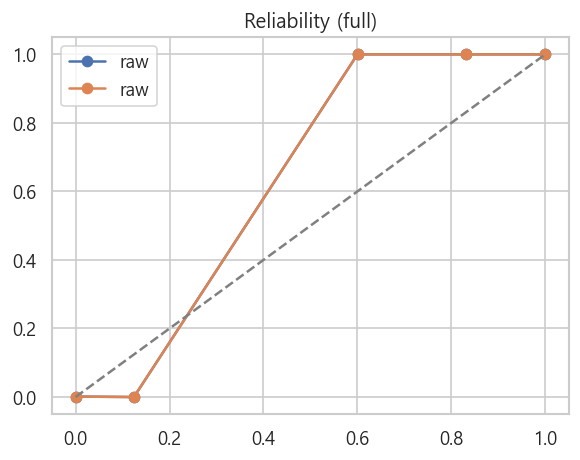

[ops] calibration 미채택(raw 유지)


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.000151,0.001274,0.750812,1.0,0.011829,0.007279,0.924477
1,platt_cv,0.000641,0.005308,0.668783,1.0,0.006369,0.002730,0.479527
2,isotonic_cv,0.000740,0.003823,0.439082,1.0,0.008189,0.008189,0.941765


,metric,value
0,calibration_used,False
1,selected_calibration_method,raw
2,brier_raw,0.000151
3,brier_selected,0.000151
4,ece_raw,0.001274
5,ece_selected,0.001274
6,sat_raw_gt_0.99,0.011829
7,sat_raw_gt_0.999,0.007279
8,sat_sel_gt_0.99,0.011829
9,sat_sel_gt_0.999,0.007279


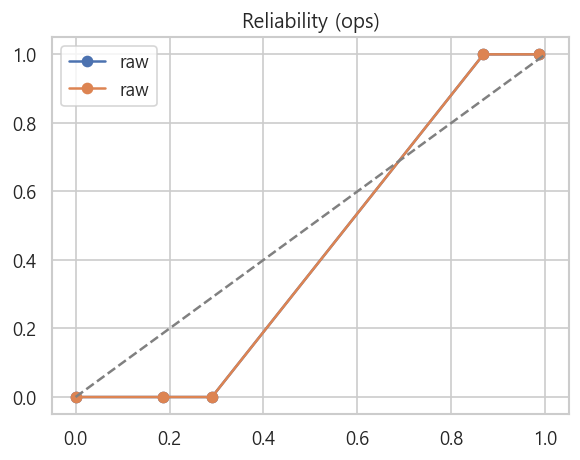

[ops_t20] calibration 미채택(raw 유지)


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002337,0.008280,0.828397,1.0,0.009449,0.007874,0.784252
1,platt_cv,0.005025,0.015505,0.757807,1.0,0.000000,0.000000,0.026772
2,isotonic_cv,0.004166,0.014115,0.738482,1.0,0.009449,0.009449,0.667717


,metric,value
0,calibration_used,False
1,selected_calibration_method,raw
2,brier_raw,0.002337
3,brier_selected,0.002337
4,ece_raw,0.00828
5,ece_selected,0.00828
6,sat_raw_gt_0.99,0.009449
7,sat_raw_gt_0.999,0.007874
8,sat_sel_gt_0.99,0.009449
9,sat_sel_gt_0.999,0.007874


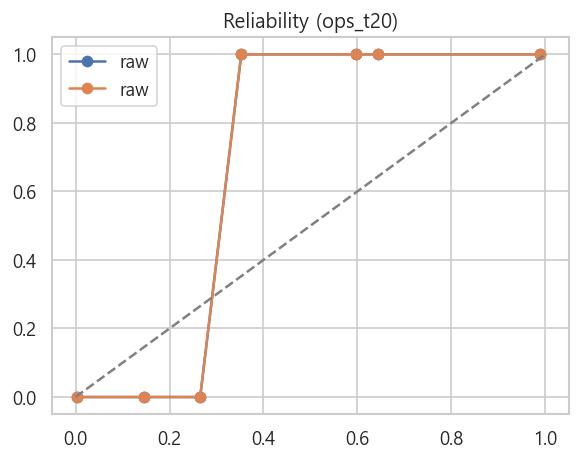

[ops_t18] calibration 미채택(raw 유지)


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,0.002696,0.003763,0.684777,1.0,0.008977,0.003591,0.833034
1,platt_cv,0.005041,0.013338,0.641716,1.0,0.000000,0.000000,0.039497
2,isotonic_cv,0.004070,0.008633,0.491601,1.0,0.005386,0.005386,0.877917


,metric,value
0,calibration_used,False
1,selected_calibration_method,raw
2,brier_raw,0.002696
3,brier_selected,0.002696
4,ece_raw,0.003763
5,ece_selected,0.003763
6,sat_raw_gt_0.99,0.008977
7,sat_raw_gt_0.999,0.003591
8,sat_sel_gt_0.99,0.008977
9,sat_sel_gt_0.999,0.003591


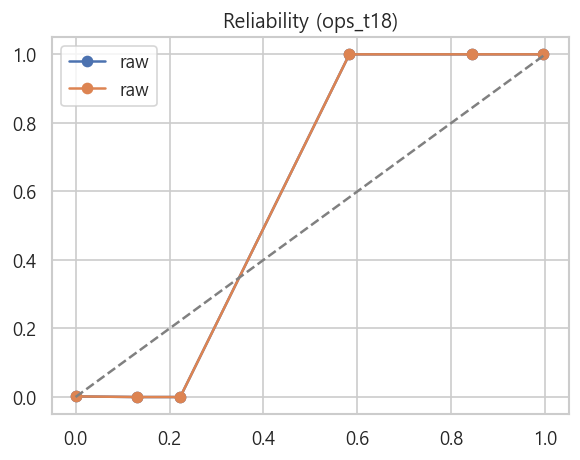

[ops_t15] calibration 미채택(raw 유지)


,method,brier,ece,ranking_ap,precision@10_hard,sat_sat_gt_0.99,sat_sat_gt_0.999,sat_sat_lt_1e-3
0,raw,1.221058e-08,0.000007,0.379593,0.4,0.008584,0.008584,0.989270
1,platt_cv,5.016780e-04,0.006183,0.560218,0.4,0.000000,0.000000,0.000000
2,isotonic_cv,5.247066e-04,0.001796,0.234773,0.4,0.008584,0.008584,0.984979


,metric,value
0,calibration_used,False
1,selected_calibration_method,raw
2,brier_raw,0.0
3,brier_selected,0.0
4,ece_raw,0.000007
5,ece_selected,0.000007
6,sat_raw_gt_0.99,0.008584
7,sat_raw_gt_0.999,0.008584
8,sat_sel_gt_0.99,0.008584
9,sat_sel_gt_0.999,0.008584


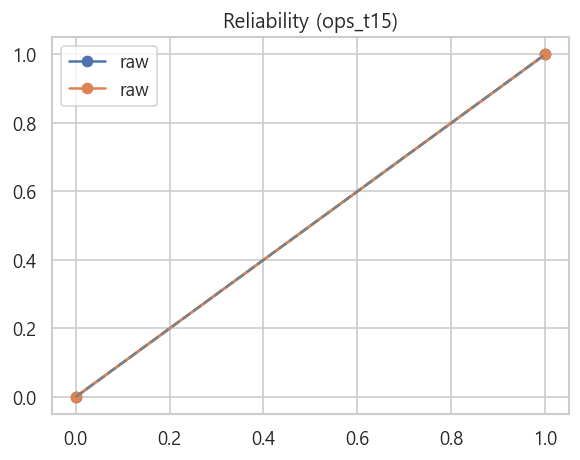

In [12]:

from sklearn.calibration import calibration_curve

def _calibration_is_better(cb: dict) -> bool:
    # 개선 조건: Brier/ECE 모두 raw 대비 비열화(<=) + 하나 이상 실개선
    b_raw, b_sel = float(cb["brier_raw"]), float(cb["brier_selected"])
    e_raw, e_sel = float(cb["ece_raw"]), float(cb["ece_selected"])
    non_worse = (b_sel <= b_raw + 1e-12) and (e_sel <= e_raw + 1e-12)
    strictly_better = (b_sel < b_raw - 1e-6) or (e_sel < e_raw - 1e-6)
    return bool(non_worse and strictly_better)


for m, R in RESULTS.items():
    cb = R.calibration_bundle

    # "raw보다 좋아질 때만 선택" 강제
    better = _calibration_is_better(cb)
    if bool(cb.get("calibration_used", False)) and not better:
        cb["calibration_used"] = False
        cb["selected_calibration_method"] = "raw"
        cb["p_selected"] = cb["p_raw"]
        cb["brier_selected"] = cb["brier_raw"]
        cb["ece_selected"] = cb["ece_raw"]
        cb["saturation_selected"] = cb["saturation_raw"]
        print(f"[{m}] calibration 비채택(raw fallback): 개선 조건 미충족")
    elif bool(cb.get("calibration_used", False)) and better:
        print(f"[{m}] calibration 채택: raw 대비 개선 확인")
    else:
        print(f"[{m}] calibration 미채택(raw 유지)")

    display(cb["calibration_compare_df"])
    save_table(cb["calibration_compare_df"], f"sec12_calibration_compare_{m}")

    summ = pd.DataFrame(
        [
            {"metric": "calibration_used", "value": cb["calibration_used"]},
            {"metric": "selected_calibration_method", "value": cb["selected_calibration_method"]},
            {"metric": "brier_raw", "value": cb["brier_raw"]},
            {"metric": "brier_selected", "value": cb["brier_selected"]},
            {"metric": "ece_raw", "value": cb["ece_raw"]},
            {"metric": "ece_selected", "value": cb["ece_selected"]},
            {"metric": "sat_raw_gt_0.99", "value": cb["saturation_raw"]["sat_gt_0.99"]},
            {"metric": "sat_raw_gt_0.999", "value": cb["saturation_raw"]["sat_gt_0.999"]},
            {"metric": "sat_sel_gt_0.99", "value": cb["saturation_selected"]["sat_gt_0.99"]},
            {"metric": "sat_sel_gt_0.999", "value": cb["saturation_selected"]["sat_gt_0.999"]},
            {"metric": "uncertainty_lt_0.01_ratio", "value": float((R.cluster_df_calibrated["risk_uncertainty"] < 0.01).mean())},
        ]
    )
    display(summ)
    save_table(summ, f"sec12_calibration_selection_{m}")

    tr, te = R.split_dict[str(R.honest_best_row["split"])]
    yte = (R.cluster_df_rule.iloc[te]["risk_label_rule_v2"] == "high").astype(int).to_numpy()
    p_raw = cb["p_raw"]
    p_sel = cb["p_selected"]
    fig, ax = plt.subplots(figsize=(5, 4))
    pr, pp = calibration_curve(yte, p_raw, n_bins=10, strategy="uniform")
    pr2, pp2 = calibration_curve(yte, p_sel, n_bins=10, strategy="uniform")
    ax.plot(pp, pr, marker="o", label="raw")
    ax.plot(pp2, pr2, marker="o", label=str(cb["selected_calibration_method"]))
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.legend()
    ax.set_title(f"Reliability ({m})")
    plt.tight_layout()
    save_fig(f"sec12_reliability_{m}")
    plt.show()

## Section 13. Hybrid 결합식 재튜닝 + rule_only 비교

In [13]:

def _recompute_ranking_summary(d: pd.DataFrame):
    hard = (d["risk_label_rule_v2"] == "high").astype(int).to_numpy()
    soft = (d["risk_score_rule_v2"] >= d["risk_score_rule_v2"].quantile(0.90)).astype(int).to_numpy()
    score = d["score_final_stage4"].to_numpy(dtype=np.float64)
    rk = v2.ranking_metrics_extended(hard, score, soft_positive=soft, ks=[5,10,20])
    burden = s3.false_positive_burden_proxy(d, score_col="score_final_stage4")
    return {
        "precision@10_hard": float(rk.get("precision@10_hard", np.nan)),
        "ap_soft": float(rk.get("average_precision_soft", np.nan)),
        "burden_per_frame": float(burden.get("candidate_burden_per_frame", np.nan)),
    }

def _score_with_weights(d0: pd.DataFrame, w):
    d = d0.copy()
    d["score_base_rule"] = d["risk_score_rule_v2"].clip(0, 1)
    d["score_adj_lidar"] = w["W_LIDAR"] * d["lidar_corroboration_score_v2"].fillna(0)
    d["score_adj_temporal"] = w["W_TEMPORAL"] * (0.5*d["closing_consistency_score"].fillna(0) + 0.5*d["motion_smoothness_score"].fillna(0))
    d["score_adj_reliability"] = w["W_RELIABILITY"] * d["risk_confidence_calibrated"].fillna(0)
    d["score_adj_quality"] = w["W_QUALITY"] * d.get("proposal_quality_score", pd.Series(0.0, index=d.index)).fillna(0)
    d["score_penalty_uncertainty"] = w["W_UNCERTAINTY"] * d["risk_uncertainty"].fillna(0)
    d["score_final_stage4"] = (
        d["score_base_rule"] + d["score_adj_lidar"] + d["score_adj_temporal"] + d["score_adj_reliability"] + d["score_adj_quality"] - d["score_penalty_uncertainty"]
    ).clip(0,1)
    return d

grid = []
for wl in [0.08,0.12,0.16]:
    for wt in [0.06,0.10,0.14]:
        for wr in [0.06,0.10,0.14]:
            for wq in [0.04,0.08]:
                for wu in [0.16,0.20,0.24]:
                    grid.append({"W_LIDAR": wl, "W_TEMPORAL": wt, "W_RELIABILITY": wr, "W_QUALITY": wq, "W_UNCERTAINTY": wu})

tuning_rows = []
for m, R in RESULTS.items():
    d0 = R.cluster_df_calibrated.copy()
    rule_row = R.ablation_results_df[R.ablation_results_df["ablation"] == "rule_only"].head(1)
    rule_p10 = float(rule_row["topk_precision"].iloc[0]) if len(rule_row) else np.nan
    rule_ap = float(rule_row["ranking_ap"].iloc[0]) if len(rule_row) else np.nan
    rule_bur = float(rule_row["candidate_burden"].iloc[0]) if len(rule_row) else np.nan
    cand = []
    for w in grid:
        dt = _score_with_weights(d0, w)
        rs = _recompute_ranking_summary(dt)
        obj = (0 if np.isnan(rs["precision@10_hard"]) else rs["precision@10_hard"]) + 0.5*(0 if np.isnan(rs["ap_soft"]) else rs["ap_soft"]) - 0.015*(0 if np.isnan(rs["burden_per_frame"]) else rs["burden_per_frame"])
        cand.append({**w, **rs, "objective": obj})
    cand_df = pd.DataFrame(cand).sort_values("objective", ascending=False).reset_index(drop=True)
    best = cand_df.iloc[0].to_dict()
    tuned = _score_with_weights(d0, best)
    R.cluster_df_final = tuned
    R.ranking_summary_df = pd.DataFrame([{"metric":"precision@10_hard","value":best["precision@10_hard"]},{"metric":"ap_soft","value":best["ap_soft"]},{"metric":"candidate_burden_per_frame","value":best["burden_per_frame"]}])
    R.hybrid_sensitivity_df = cand_df.head(30)
    R.hybrid_vs_rule_df = pd.DataFrame([{
        "mode": m,
        "rule_only_p10": rule_p10,
        "hybrid_p10": best["precision@10_hard"],
        "delta_p10": best["precision@10_hard"] - rule_p10 if rule_p10 == rule_p10 else np.nan,
        "rule_only_ap": rule_ap,
        "hybrid_ap": best["ap_soft"],
        "delta_ap": best["ap_soft"] - rule_ap if rule_ap == rule_ap else np.nan,
        "rule_only_burden": rule_bur,
        "hybrid_burden": best["burden_per_frame"],
        "delta_burden": best["burden_per_frame"] - rule_bur if rule_bur == rule_bur else np.nan,
    }])
    k = min(40, len(tuned))
    top_h = set(tuned.nlargest(k, "score_final_stage4").index)
    top_r = set(tuned.nlargest(k, "risk_score_rule_v2").index)
    R.hybrid_better_cases = tuned.loc[list(top_h - top_r)].sort_values("score_final_stage4", ascending=False).head(20)
    tuning_rows.append({"mode": m, **{k: best[k] for k in ["W_LIDAR","W_TEMPORAL","W_RELIABILITY","W_QUALITY","W_UNCERTAINTY","precision@10_hard","ap_soft","burden_per_frame","objective"]}})
    save_table(R.hybrid_sensitivity_df, f"sec13_hybrid_weight_sensitivity_{m}")
    save_table(R.hybrid_vs_rule_df, f"sec13_rule_vs_hybrid_{m}")
    save_table(R.hybrid_better_cases, f"sec13_hybrid_better_cases_{m}")

hybrid_tuning_summary_df = pd.DataFrame(tuning_rows)
display(hybrid_tuning_summary_df)
save_table(hybrid_tuning_summary_df, "sec13_hybrid_tuning_summary")


,mode,W_LIDAR,W_TEMPORAL,W_RELIABILITY,W_QUALITY,W_UNCERTAINTY,precision@10_hard,ap_soft,burden_per_frame,objective
0,full,0.08,0.06,0.14,0.04,0.16,1.0,0.917942,33.822222,0.951638
1,ops,0.12,0.06,0.14,0.04,0.16,1.0,0.917996,25.122905,1.082155
2,ops_t20,0.16,0.06,0.14,0.04,0.16,1.0,0.817515,13.314607,1.209038
3,ops_t18,0.08,0.06,0.14,0.04,0.16,1.0,0.827895,11.595506,1.240015
4,ops_t15,0.08,0.06,0.14,0.04,0.16,1.0,0.832818,9.876404,1.268263


WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/sec13_hybrid_tuning_summary_v22.csv')

## Section 14. Stronger ops mode 비교 + frontier + operating point 추천

,mode,candidates_per_frame,candidates_per_window,precision@10_hard,ranking_ap_soft,analyst_burden_proxy
4,ops_t15,9.876404,97.666667,1.0,0.832818,36.213483
3,ops_t18,11.595506,114.666667,1.0,0.827895,42.516854
2,ops_t20,13.314607,131.666667,1.0,0.817515,48.820225
1,ops,25.122905,249.833333,1.0,0.917996,92.536034
0,full,33.822222,338.222222,1.0,0.917942,125.142222


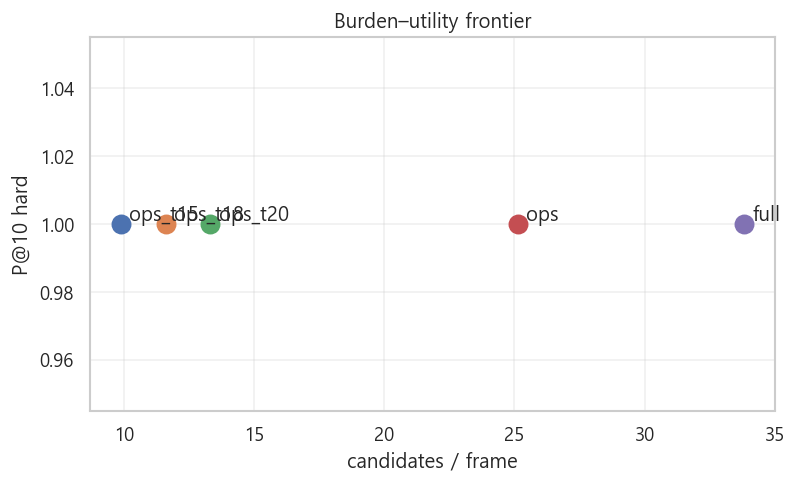

,mode,candidates_per_frame,candidates_per_window,precision@10_hard,ranking_ap_soft,analyst_burden_proxy,objective,target
4,ops_t15,9.876404,97.666667,1.0,0.832818,36.213483,1.234363,<15


WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/sec14_recommended_operating_point_v22.csv')

In [14]:

rows = []
for m, R in RESULTS.items():
    rk = R.ranking_summary_df.set_index("metric")["value"].to_dict()
    d = R.cluster_df_final.copy()
    cand_pf = float(len(d) / max(d["frame_id"].nunique(), 1))
    d["window_id"] = (d["frame_order"] // 10).astype(int)
    cand_pw = float(d.groupby("window_id").size().mean()) if len(d) else np.nan
    rows.append({
        "mode": m,
        "candidates_per_frame": cand_pf,
        "candidates_per_window": cand_pw,
        "precision@10_hard": rk.get("precision@10_hard", np.nan),
        "ranking_ap_soft": rk.get("ap_soft", np.nan),
        "analyst_burden_proxy": float(cand_pf * 0.7 + cand_pw * 0.3) if (cand_pf == cand_pf and cand_pw == cand_pw) else np.nan,
    })
mode_compare_metrics_df = pd.DataFrame(rows).sort_values("candidates_per_frame")
display(mode_compare_metrics_df)
save_table(mode_compare_metrics_df, "sec14_mode_compare_metrics")

fig, ax = plt.subplots(figsize=(6.8, 4.2))
for _, r in mode_compare_metrics_df.iterrows():
    ax.scatter(r["candidates_per_frame"], r["precision@10_hard"], s=120)
    ax.annotate(r["mode"], (r["candidates_per_frame"], r["precision@10_hard"]), textcoords="offset points", xytext=(5, 2))
ax.set_xlabel("candidates / frame"); ax.set_ylabel("P@10 hard")
ax.set_title("Burden–utility frontier")
ax.grid(True, alpha=0.3)
plt.tight_layout(); save_fig("sec14_burden_utility_frontier"); plt.show()

def _recommend(df):
    cand = df.copy()
    cand["objective"] = cand["precision@10_hard"].fillna(0) + 0.4*cand["ranking_ap_soft"].fillna(0) - 0.01*cand["candidates_per_frame"].fillna(0)
    for thr in [15, 18, 20]:
        sub = cand[cand["candidates_per_frame"] < thr]
        if len(sub):
            return sub.sort_values("objective", ascending=False).head(1).assign(target=f"<{thr}")
    return cand.sort_values("objective", ascending=False).head(1).assign(target="fallback")

recommended_operating_point_df = _recommend(mode_compare_metrics_df)
display(recommended_operating_point_df)
save_table(recommended_operating_point_df, "sec14_recommended_operating_point")


## Section 15. Ablation

In [15]:

for m, R in RESULTS.items():
    display(R.ablation_results_df)
    save_table(R.ablation_results_df, f"sec15_ablation_results_{m}")


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden
0,full_model,0.637409,0.839161,0.671561,1.0,2.033333
1,rule_only,0.703361,1.000000,1.000000,1.0,2.033333
2,no_lidar,0.631639,0.825175,0.650869,1.0,2.033333
3,no_tracking_features,0.685119,0.909091,0.787865,1.0,2.033333
4,no_calibration,0.680864,0.916084,0.804568,1.0,2.033333
5,ml_only,0.015300,1.000000,0.142888,1.0,33.822222
6,rule_plus_ml_hybrid,0.643776,0.951049,0.766925,1.0,2.033333


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden
0,full_model,0.659164,0.971698,0.627540,1.0,1.508380
1,rule_only,0.704220,1.000000,1.000000,1.0,1.508380
2,no_lidar,0.646483,0.952830,0.597490,1.0,1.508380
3,no_tracking_features,0.708929,1.000000,0.758543,1.0,1.508380
4,no_calibration,0.685505,0.981132,0.814515,1.0,1.508380
5,ml_only,0.015352,1.000000,0.134064,1.0,25.122905
6,rule_plus_ml_hybrid,0.661585,1.000000,0.829236,1.0,1.508380


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden
0,full_model,0.645152,0.857143,0.562658,1.0,0.803371
1,rule_only,0.703384,1.000000,1.000000,1.0,0.803371
2,no_lidar,0.632221,0.821429,0.529591,1.0,0.803371
3,no_tracking_features,0.693605,0.892857,0.688418,1.0,0.803371
4,no_calibration,0.684659,0.964286,0.720772,1.0,0.803371
5,ml_only,0.015389,1.000000,0.126582,0.7,13.314607
6,rule_plus_ml_hybrid,0.649670,0.982143,0.711091,1.0,0.803371


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden
0,full_model,0.652066,0.897959,0.598367,1.0,0.696629
1,rule_only,0.705296,1.000000,1.000000,1.0,0.696629
2,no_lidar,0.648578,0.877551,0.565356,1.0,0.696629
3,no_tracking_features,0.684202,0.877551,0.691801,1.0,0.696629
4,no_calibration,0.696333,1.000000,0.738924,1.0,0.696629
5,ml_only,0.015460,1.000000,0.126369,0.6,11.595506
6,rule_plus_ml_hybrid,0.641103,0.979592,0.733645,1.0,0.696629


,ablation,macro_f1,high_recall,ranking_ap,topk_precision,candidate_burden
0,full_model,0.677302,1.000000,0.605200,1.0,0.595506
1,rule_only,0.705116,1.000000,1.000000,1.0,0.595506
2,no_lidar,0.664850,0.976190,0.592334,1.0,0.595506
3,no_tracking_features,0.662722,0.785714,0.701396,1.0,0.595506
4,no_calibration,0.691872,1.000000,0.736515,1.0,0.595506
5,ml_only,0.015556,1.000000,0.120566,0.4,9.876404
6,rule_plus_ml_hybrid,0.645809,1.000000,0.722080,1.0,0.595506


## Section 16. Runtime

In [16]:

runtime_summary_df = pd.DataFrame(runtime_records)
if not runtime_summary_df.empty:
    runtime_summary_df = runtime_summary_df.groupby("stage", as_index=False)["sec"].sum().sort_values("sec", ascending=False)
display(runtime_summary_df)
save_table(runtime_summary_df, "sec16_runtime_summary")


,stage,sec
4,section6_dual_pipeline,764.100285
2,section4_candidate_generation,21.290664
0,section2_load_and_eda,3.161136
3,section5_suppression,1.316129
1,section3_preprocess,0.010156


WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/sec16_runtime_summary_v22.csv')

## Section 17. Explainability + hybrid 유리 hard case

In [17]:

for m, R in RESULTS.items():
    display(R.top_candidate_table.head(12))
    display(R.hybrid_better_cases.head(10))
    save_table(R.top_candidate_table, f"sec17_top_candidate_table_{m}")
    save_table(R.hard_case_table, f"sec17_hard_case_table_{m}")
    save_table(R.hybrid_better_cases, f"sec17_hybrid_better_cases_{m}")


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00118:0,234,0.629734,high,0.882413,0.261303,33,0.0,0.712092,0.607895,"근접성:0.89, LiDAR 정합:0.61, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.442, 보정신뢰=0.882, 불확실성=0.261."
1,hdbscan:00117:0,234,0.616541,high,0.881309,0.263755,33,0.0,0.712092,0.561219,"근접성:0.88, LiDAR 정합:0.56, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.434, 보정신뢰=0.881, 불확실성=0.264."
2,hdbscan:00113:2,234,0.613644,high,0.880629,0.265266,33,0.0,0.712092,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.881, 불확실성=0.265."
3,hdbscan:00109:2,234,0.607080,high,0.880038,0.266568,33,0.0,0.712092,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.404, 보정신뢰=0.880, 불확실성=0.267."
4,hdbscan:00096:5,234,0.606376,high,0.879811,0.267086,33,0.0,0.712092,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.880, 불확실성=0.267."
5,hdbscan:00097:6,234,0.605160,high,0.879687,0.267360,33,0.0,0.712092,0.527624,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.401, 보정신뢰=0.880, 불확실성=0.267."
6,hdbscan:00093:3,234,0.602352,high,0.879384,0.268034,33,0.0,0.712092,0.529643,"근접성:0.87, LiDAR 정합:0.53, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.879, 불확실성=0.268."
7,hdbscan:00120:0,234,0.594182,high,0.879731,0.267263,33,0.0,0.712092,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.427, 보정신뢰=0.880, 불확실성=0.267."
8,hdbscan:00100:20,248,0.577861,high,0.882942,0.260125,11,0.0,0.817537,0.478159,"근접성:0.90, LiDAR 정합:0.48, 운동 이상:0.34",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.376, 보정신뢰=0.883, 불확실성=0.260."
9,hdbscan:00012:4,1,0.568508,high,0.875749,0.276109,36,0.0,0.658020,0.610494,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.341, 보정신뢰=0.876, 불확실성=0.276."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,risk_uncertainty,risk_confidence_calibrated,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4
622,hdbscan,00015,15,1,hdbscan:00015:1,198,7.182091,-3.124494,-0.324363,7.832298,...,0.276819,0.875430,0.999999,0.360606,0.048519,0.026349,0.122560,0.027679,0.044291,0.541422
668,hdbscan,00016,16,2,hdbscan:00016:2,190,7.175650,-3.562627,-0.315307,8.011384,...,0.277953,0.874920,0.999999,0.356070,0.048023,0.026349,0.122489,0.027627,0.044473,0.536085
965,hdbscan,00024,24,2,hdbscan:00024:2,175,5.990287,-5.085199,-0.219540,7.857658,...,0.277939,0.874927,0.999999,0.356125,0.048212,0.026349,0.122490,0.026885,0.044470,0.535590
324,hdbscan,00009,9,12,hdbscan:00009:12,214,7.927779,-2.204110,-0.237959,8.228474,...,0.293369,0.867981,0.999997,0.359189,0.048913,0.019659,0.121517,0.027475,0.046939,0.529814
784,hdbscan,00019,19,1,hdbscan:00019:1,205,7.117515,-4.569695,-0.258268,8.458200,...,0.279756,0.874098,0.999987,0.349155,0.047780,0.026349,0.122374,0.027213,0.044761,0.528109
4630,hdbscan,00153,153,0,hdbscan:00153:0,36,9.937230,3.373620,-0.339456,10.494277,...,0.274245,0.876574,0.999982,0.353809,0.040157,0.028279,0.122720,0.026185,0.043879,0.527272
748,hdbscan,00018,18,2,hdbscan:00018:2,206,7.186316,-4.215184,-0.255563,8.331321,...,0.288003,0.870389,0.999989,0.350720,0.047797,0.019686,0.121855,0.027504,0.046080,0.521480
3211,hdbscan,00100,100,22,hdbscan:00100:22,22,3.615030,-0.422443,-0.068025,3.639629,...,0.283054,0.872478,0.999831,0.345594,0.035805,0.027646,0.122147,0.032084,0.045289,0.517988
1161,hdbscan,00029,29,1,hdbscan:00029:1,76,5.310939,-6.554702,0.025724,8.436243,...,0.281331,0.873390,0.999987,0.342841,0.046742,0.026349,0.122275,0.024701,0.045013,0.517894
5000,hdbscan,00161,161,1,hdbscan:00161:1,43,11.659991,1.289251,-0.446372,11.731051,...,0.277053,0.875323,0.999996,0.342233,0.038640,0.028279,0.122545,0.028377,0.044328,0.515745


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00116:0,172,0.615423,high,0.886840,0.251464,30,0.0,0.868005,0.555245,"근접성:0.89, LiDAR 정합:0.56, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.423, 보정신뢰=0.887, 불확실성=0.251."
1,hdbscan:00115:0,172,0.615273,high,0.886613,0.251969,30,0.0,0.868005,0.540991,"근접성:0.89, LiDAR 정합:0.54, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.420, 보정신뢰=0.887, 불확실성=0.252."
2,hdbscan:00112:2,172,0.612751,high,0.886089,0.253119,30,0.0,0.868005,0.509262,"근접성:0.89, LiDAR 정합:0.51, 접근/시간여유:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.886, 불확실성=0.253."
3,hdbscan:00114:2,172,0.611242,high,0.886086,0.253139,30,0.0,0.868005,0.519083,"근접성:0.89, LiDAR 정합:0.52, 접근/시간여유:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.886, 불확실성=0.253."
4,hdbscan:00096:5,172,0.605599,high,0.885374,0.254679,30,0.0,0.868005,0.528962,"근접성:0.89, LiDAR 정합:0.53, 접근/시간여유:0.37",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.397, 보정신뢰=0.885, 불확실성=0.255."
5,hdbscan:00094:3,172,0.604534,high,0.885026,0.255467,30,0.0,0.868005,0.514613,"근접성:0.88, LiDAR 정합:0.51, 접근/시간여유:0.39",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.885, 불확실성=0.255."
6,hdbscan:00120:0,172,0.593608,high,0.885371,0.254728,30,0.0,0.868005,0.497488,"근접성:0.88, LiDAR 정합:0.50, 접근/시간여유:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.418, 보정신뢰=0.885, 불확실성=0.255."
7,hdbscan:00099:6,172,0.586808,high,0.880241,0.263693,30,0.0,0.868005,0.488215,"근접성:0.90, LiDAR 정합:0.49, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.370, 보정신뢰=0.880, 불확실성=0.264."
8,hdbscan:00013:2,22,0.565420,high,0.874832,0.275704,29,0.0,0.724478,0.607697,"근접성:0.80, LiDAR 정합:0.61, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.337, 보정신뢰=0.875, 불확실성=0.276."
9,hdbscan:00010:8,22,0.558370,high,0.867594,0.286130,29,0.0,0.724478,0.616255,"근접성:0.79, LiDAR 정합:0.62, 운동 이상:0.35",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.332, 보정신뢰=0.868, 불확실성=0.286."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,risk_uncertainty,risk_confidence_calibrated,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4
354,hdbscan,00013,13,2,hdbscan:00013:2,197,7.214008,-2.478605,-0.299466,7.627935,...,0.275704,0.874832,0.998742,0.354983,0.072924,0.029882,0.122476,0.027683,0.044113,0.563836
261,hdbscan,00010,10,8,hdbscan:00010:8,197,7.760863,-2.331038,-0.242060,8.103377,...,0.286130,0.867594,0.995814,0.351441,0.073951,0.029882,0.121463,0.026821,0.045781,0.557777
715,hdbscan,00025,25,1,hdbscan:00025:1,159,5.707800,-5.221157,-0.149740,7.735597,...,0.303857,0.854353,0.989677,0.348027,0.071688,0.029882,0.119609,0.026818,0.048617,0.547409
455,hdbscan,00016,16,2,hdbscan:00016:2,190,7.175650,-3.562627,-0.315307,8.011384,...,0.303414,0.854824,0.989993,0.346564,0.072035,0.029882,0.119675,0.027422,0.048546,0.547032
481,hdbscan,00017,17,4,hdbscan:00017:4,198,7.205772,-3.932160,-0.277496,8.208839,...,0.321930,0.840294,0.982649,0.343482,0.072241,0.029882,0.117641,0.027036,0.051509,0.538773
3557,hdbscan,00159,159,1,hdbscan:00159:1,46,11.423700,1.756022,-0.444334,11.557878,...,0.315390,0.850724,0.991434,0.353140,0.056908,0.025590,0.119101,0.028806,0.050462,0.533082
3446,hdbscan,00156,156,3,hdbscan:00156:3,37,10.882342,2.576380,-0.303623,11.183162,...,0.328081,0.842423,0.988338,0.355158,0.057277,0.017772,0.117939,0.029644,0.052493,0.525298
564,hdbscan,00020,20,3,hdbscan:00020:3,203,6.887149,-4.795412,-0.260149,8.392187,...,0.391242,0.780927,0.947795,0.338242,0.071415,0.029882,0.109330,0.027110,0.062599,0.513380
535,hdbscan,00019,19,1,hdbscan:00019:1,205,7.117515,-4.569695,-0.258268,8.458200,...,0.408014,0.765375,0.937507,0.339649,0.071670,0.029882,0.107152,0.027069,0.065282,0.510140
3853,hdbscan,00166,166,1,hdbscan:00166:1,61,12.676265,0.351238,-0.828875,12.681130,...,0.443274,0.740482,0.924993,0.346538,0.056527,0.025590,0.103667,0.032540,0.070924,0.493938


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00115:0,129,0.606955,high,0.876213,0.275076,14,0.0,0.658329,0.540991,"근접성:0.89, LiDAR 정합:0.54, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.430, 보정신뢰=0.876, 불확실성=0.275."
1,hdbscan:00113:2,129,0.604466,high,0.875584,0.276303,14,0.0,0.658329,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.876, 불확실성=0.276."
2,hdbscan:00111:3,129,0.603417,high,0.874737,0.277757,14,0.0,0.658329,0.511540,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.47",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.875, 불확실성=0.278."
3,hdbscan:00110:2,129,0.597589,high,0.872180,0.281735,14,0.0,0.658329,0.509799,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.872, 불확실성=0.282."
4,hdbscan:00092:5,82,0.597434,high,0.883721,0.258271,64,0.0,0.797515,0.512072,"근접성:0.87, LiDAR 정합:0.51, 접근/시간여유:0.38",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.884, 불확실성=0.258."
5,hdbscan:00100:20,126,0.571371,high,0.875902,0.275611,49,0.0,0.666994,0.478159,"근접성:0.90, LiDAR 정합:0.48, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.382, 보정신뢰=0.876, 불확실성=0.276."
6,hdbscan:00100:19,82,0.545763,high,0.848508,0.307914,64,0.0,0.797515,0.457131,"근접성:0.90, LiDAR 정합:0.46, 운동 이상:0.34",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.354, 보정신뢰=0.849, 불확실성=0.308."
7,hdbscan:00112:2,129,0.513300,high,0.411919,0.500000,14,0.0,0.658329,0.509262,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.419, 보정신뢰=0.412, 불확실성=0.500."
8,hdbscan:00114:2,129,0.511768,high,0.411648,0.500000,14,0.0,0.658329,0.519083,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.425, 보정신뢰=0.412, 불확실성=0.500."
9,hdbscan:00109:2,82,0.509476,high,0.397009,0.500000,64,0.0,0.797515,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.397, 불확실성=0.500."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,risk_uncertainty,risk_confidence_calibrated,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4
133,hdbscan,00013,13,2,hdbscan:00013:2,197,7.214008,-2.478605,-0.299466,7.627935,...,0.5,0.338666,0.0,0.338666,0.097231,0.038276,0.047413,0.027683,0.08,0.469270
121,hdbscan,00012,12,4,hdbscan:00012:4,200,7.358994,-2.426430,-0.315556,7.748700,...,0.5,0.337637,0.0,0.337637,0.097679,0.038276,0.047269,0.027551,0.08,0.468412
97,hdbscan,00010,10,8,hdbscan:00010:8,197,7.760863,-2.331038,-0.242060,8.103377,...,0.5,0.335124,0.0,0.335124,0.098601,0.038276,0.046917,0.026821,0.08,0.465738
169,hdbscan,00015,15,1,hdbscan:00015:1,198,7.182091,-3.124494,-0.324363,7.832298,...,0.5,0.334783,0.0,0.334783,0.097038,0.038276,0.046870,0.027470,0.08,0.464436
87,hdbscan,00009,9,12,hdbscan:00009:12,214,7.927779,-2.204110,-0.237959,8.228474,...,0.5,0.333366,0.0,0.333366,0.097825,0.038276,0.046671,0.027326,0.08,0.463464
74,hdbscan,00008,8,8,hdbscan:00008:8,226,8.138797,-2.108816,-0.210081,8.407563,...,0.5,0.331058,0.0,0.331058,0.097496,0.038276,0.046348,0.027470,0.08,0.460647
318,hdbscan,00025,25,1,hdbscan:00025:1,159,5.707800,-5.221157,-0.149740,7.735597,...,0.5,0.331710,0.0,0.331710,0.095585,0.038276,0.046439,0.026818,0.08,0.458828
185,hdbscan,00016,16,2,hdbscan:00016:2,190,7.175650,-3.562627,-0.315307,8.011384,...,0.5,0.330246,0.0,0.330246,0.096047,0.038276,0.046234,0.027422,0.08,0.458225


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00115:0,115,0.606686,high,0.878085,0.270679,43,0.0,0.598079,0.540991,"근접성:0.89, LiDAR 정합:0.54, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.430, 보정신뢰=0.878, 불확실성=0.271."
1,hdbscan:00113:2,115,0.602496,high,0.873118,0.278249,43,0.0,0.598079,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.873, 불확실성=0.278."
2,hdbscan:00111:3,115,0.598164,high,0.863399,0.291678,43,0.0,0.598079,0.511540,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.47",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.863, 불확실성=0.292."
3,hdbscan:00092:5,115,0.586141,high,0.871158,0.282397,43,0.0,0.598079,0.512072,"근접성:0.87, LiDAR 정합:0.51, 운동 이상:0.43",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.405, 보정신뢰=0.871, 불확실성=0.282."
4,hdbscan:00100:20,123,0.584674,high,0.874629,0.277406,9,0.0,0.939392,0.478159,"근접성:0.90, LiDAR 정합:0.48, 운동 이상:0.41",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.382, 보정신뢰=0.875, 불확실성=0.277."
5,hdbscan:00110:2,115,0.581491,high,0.829500,0.334212,43,0.0,0.598079,0.509799,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.830, 불확실성=0.334."
6,hdbscan:00112:2,115,0.511965,high,0.411919,0.500000,43,0.0,0.598079,0.509262,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.419, 보정신뢰=0.412, 불확실성=0.500."
7,hdbscan:00114:2,115,0.510433,high,0.411648,0.500000,43,0.0,0.598079,0.519083,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.425, 보정신뢰=0.412, 불확실성=0.500."
8,hdbscan:00109:2,115,0.505389,high,0.408252,0.500000,43,0.0,0.598079,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.404, 보정신뢰=0.408, 불확실성=0.500."
9,hdbscan:00096:5,115,0.504606,high,0.406020,0.500000,43,0.0,0.598079,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.406, 보정신뢰=0.406, 불확실성=0.500."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,risk_uncertainty,risk_confidence_calibrated,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4
79,hdbscan,00010,10,8,hdbscan:00010:8,197,7.760863,-2.331038,-0.242060,8.103377,...,0.5,0.335343,0.0,0.335343,0.049300,0.038076,0.046948,0.026821,0.08,0.416488
134,hdbscan,00015,15,1,hdbscan:00015:1,198,7.182091,-3.124494,-0.324363,7.832298,...,0.5,0.335002,0.0,0.335002,0.048519,0.038076,0.046900,0.027470,0.08,0.415968
70,hdbscan,00009,9,12,hdbscan:00009:12,214,7.927779,-2.204110,-0.237959,8.228474,...,0.5,0.333585,0.0,0.333585,0.048913,0.038076,0.046702,0.027326,0.08,0.414601


,cluster_uid,track_id,final_risk_score,risk_label,risk_confidence_calibrated,risk_uncertainty,track_age,avg_speed,closing_consistency_score,lidar_corroboration_score_v2,dominant_risk_contributors,explanation_ko,decision_reason_ko
0,hdbscan:00113:2,105,0.612387,high,0.879139,0.268573,35,0.0,0.730323,0.511728,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.422, 보정신뢰=0.879, 불확실성=0.269."
1,hdbscan:00111:3,105,0.611603,high,0.878938,0.269022,35,0.0,0.730323,0.511540,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.47",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.416, 보정신뢰=0.879, 불확실성=0.269."
2,hdbscan:00110:2,105,0.606696,high,0.878698,0.269555,35,0.0,0.730323,0.509799,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.410, 보정신뢰=0.879, 불확실성=0.270."
3,hdbscan:00092:5,95,0.603463,high,0.885070,0.255398,18,0.0,0.900638,0.512072,"근접성:0.87, LiDAR 정합:0.51, 접근/시간여유:0.38",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.398, 보정신뢰=0.885, 불확실성=0.255."
4,hdbscan:00112:2,105,0.519319,high,0.411919,0.500000,35,0.0,0.730323,0.509262,"근접성:0.89, LiDAR 정합:0.51, 운동 이상:0.46",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.419, 보정신뢰=0.412, 불확실성=0.500."
5,hdbscan:00114:2,105,0.517787,high,0.411648,0.500000,35,0.0,0.730323,0.519083,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.44",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.425, 보정신뢰=0.412, 불확실성=0.500."
6,hdbscan:00096:5,95,0.513940,high,0.394041,0.500000,18,0.0,0.900638,0.528962,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.38",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.399, 보정신뢰=0.394, 불확실성=0.500."
7,hdbscan:00109:2,105,0.512743,high,0.408252,0.500000,35,0.0,0.730323,0.521178,"근접성:0.89, LiDAR 정합:0.52, 운동 이상:0.48",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.404, 보정신뢰=0.408, 불확실성=0.500."
8,hdbscan:00094:3,95,0.512737,high,0.390728,0.500000,18,0.0,0.900638,0.514613,"근접성:0.88, LiDAR 정합:0.51, 접근/시간여유:0.39",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.401, 보정신뢰=0.391, 불확실성=0.500."
9,hdbscan:00097:6,95,0.512668,high,0.392941,0.500000,18,0.0,0.900638,0.527624,"근접성:0.89, LiDAR 정합:0.53, 운동 이상:0.39",근거리·LiDAR 정합 강함 기준으로 high 구간으로 분류됨.,"최종점수=0.394, 보정신뢰=0.393, 불확실성=0.500."


,algorithm,frame_id,frame_order,cluster_id,cluster_uid,n_points,cx,cy,cz,range_xy,...,risk_uncertainty,risk_confidence_calibrated,ml_refine_score,score_base_rule,score_adj_lidar,score_adj_temporal,score_adj_reliability,score_adj_quality,score_penalty_uncertainty,score_final_stage4
99,hdbscan,00014,14,1,hdbscan:00014:1,206,7.122563,-2.606169,-0.266601,7.584394,...,0.159387,0.000081,0.000088,0.331914,0.048621,0.04074,0.000011,0.027831,0.025502,0.423616
72,hdbscan,00011,11,7,hdbscan:00011:7,199,7.564078,-2.343366,-0.271482,7.918752,...,0.158431,0.000061,0.000066,0.328523,0.048943,0.04074,0.000009,0.027232,0.025349,0.420098
89,hdbscan,00013,13,2,hdbscan:00013:2,197,7.214008,-2.478605,-0.299466,7.627935,...,0.500000,0.331464,0.000000,0.331464,0.048616,0.04074,0.046405,0.027683,0.080000,0.414908
80,hdbscan,00012,12,4,hdbscan:00012:4,200,7.358994,-2.426430,-0.315556,7.748700,...,0.500000,0.330435,0.000000,0.330435,0.048840,0.04074,0.046261,0.027551,0.080000,0.413826


## Section 18. Temporal effectiveness report


[full] temporal feature describe


,count,mean,std,min,25%,50%,75%,max
approach_score,6088.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temporal_stability_score,6088.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
motion_smoothness_score,6088.0,0.232293,0.128686,0.031607,0.154254,0.200434,0.272830,1.000000
closing_consistency_score,6088.0,0.654746,0.154467,0.219764,0.549382,0.643500,0.764875,1.000000
trajectory_risk_proxy,6088.0,1.206487,0.536348,0.000000,0.852456,1.141650,1.432280,5.904208


,approach_score,temporal_stability_score,motion_smoothness_score,closing_consistency_score,trajectory_risk_proxy
0,0.0,0.0,0.131286,0.722967,1.550738
1,0.0,0.0,0.220263,0.658020,1.004919
2,0.0,0.0,0.220263,0.658020,1.004919
3,0.0,0.0,0.390289,0.924870,0.722582
4,0.0,0.0,0.131286,0.722967,1.550738
5,0.0,0.0,0.134801,0.416097,1.612437
6,0.0,0.0,0.179127,0.706595,1.258217
7,0.0,0.0,0.143326,0.484705,1.559303
8,0.0,0.0,0.131286,0.722967,1.550738
9,0.0,0.0,0.111983,0.506846,1.875244


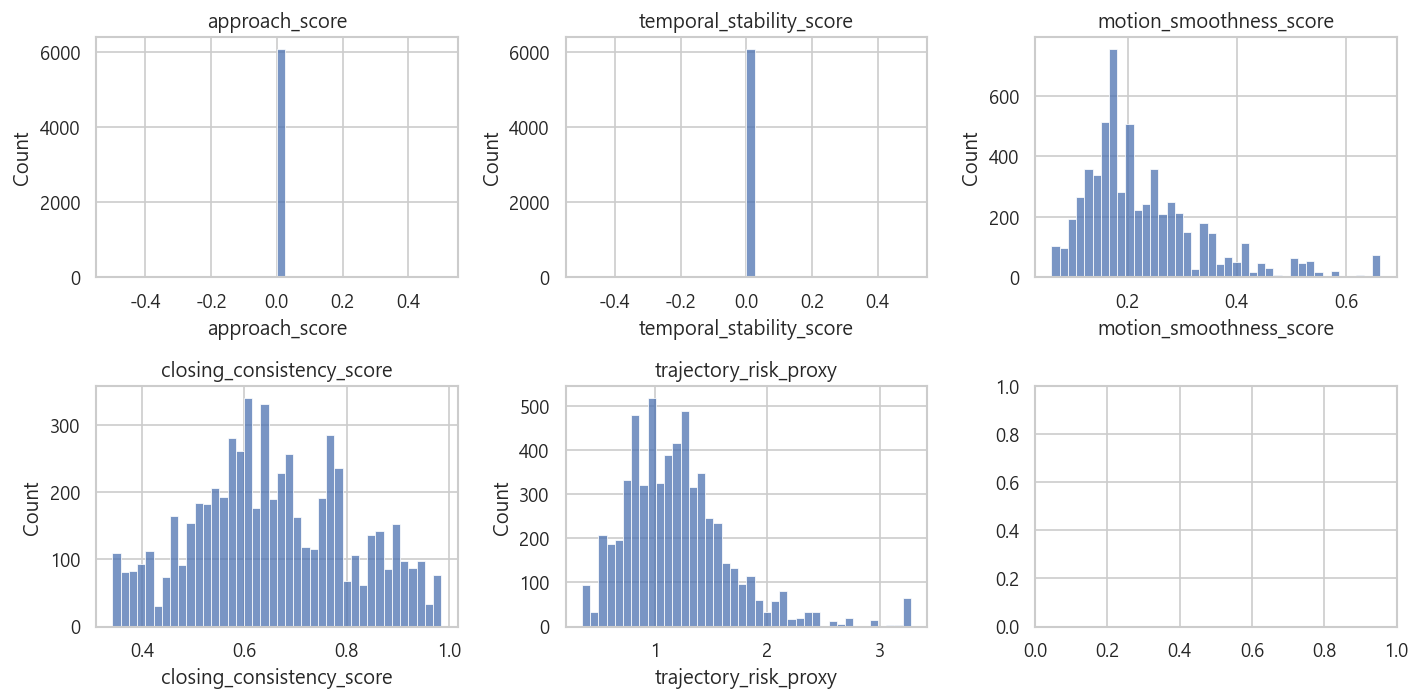

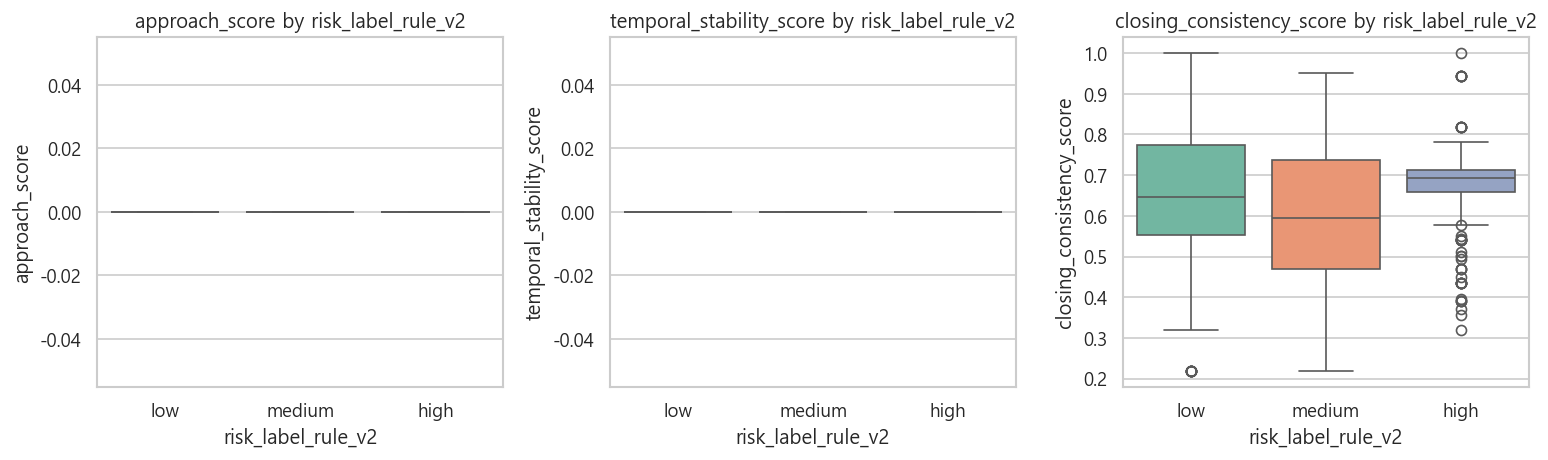

[full] temporal contribution summary


,mode,feature,pearson_to_score,top10pct_score_lift,top10pct_threshold
0,full,approach_score,NaN,0.000000,0.000000
1,full,temporal_stability_score,NaN,0.000000,0.000000
4,full,trajectory_risk_proxy,-0.078990,-0.013586,1.770702
2,full,motion_smoothness_score,-0.036767,-0.014991,0.382488
3,full,closing_consistency_score,-0.071963,-0.024877,0.874407



[ops] temporal feature describe


,count,mean,std,min,25%,50%,75%,max
approach_score,4497.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temporal_stability_score,4497.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
motion_smoothness_score,4497.0,0.232674,0.135997,0.029587,0.155013,0.189328,0.278785,1.000000
closing_consistency_score,4497.0,0.665596,0.154308,0.183346,0.565982,0.650399,0.779886,1.000000
trajectory_risk_proxy,4497.0,1.226897,0.564510,0.000000,0.843491,1.190926,1.439985,6.370086


,approach_score,temporal_stability_score,motion_smoothness_score,closing_consistency_score,trajectory_risk_proxy
0,0.0,0.0,0.167541,0.554048,1.333871
1,0.0,0.0,0.219172,0.622088,1.003765
2,0.0,0.0,0.167541,0.554048,1.333871
3,0.0,0.0,0.175012,0.858973,1.305925
4,0.0,0.0,0.219172,0.622088,1.003765
5,0.0,0.0,0.270547,0.915382,0.965769
6,0.0,0.0,0.579208,0.972358,0.386275
7,0.0,0.0,0.134686,0.541659,1.537887
8,0.0,0.0,0.122254,0.538095,1.722403
9,0.0,0.0,0.176282,0.565082,1.282590


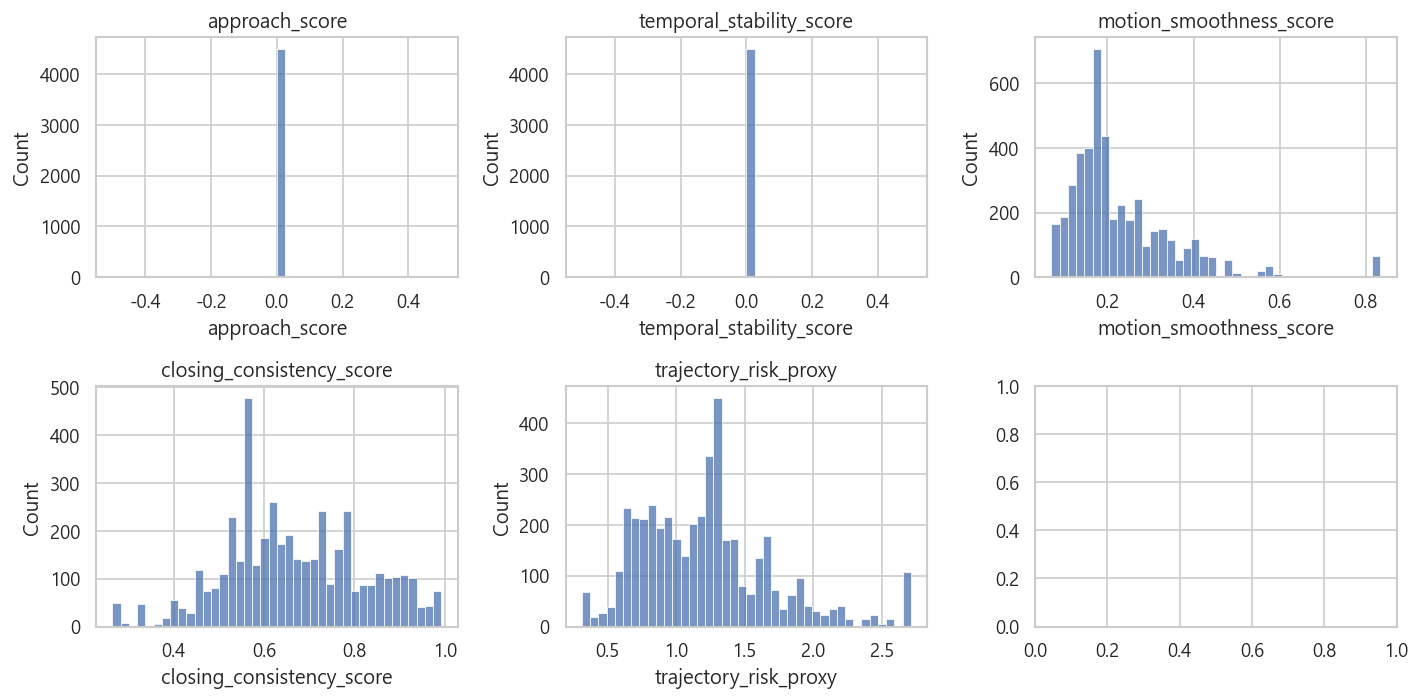

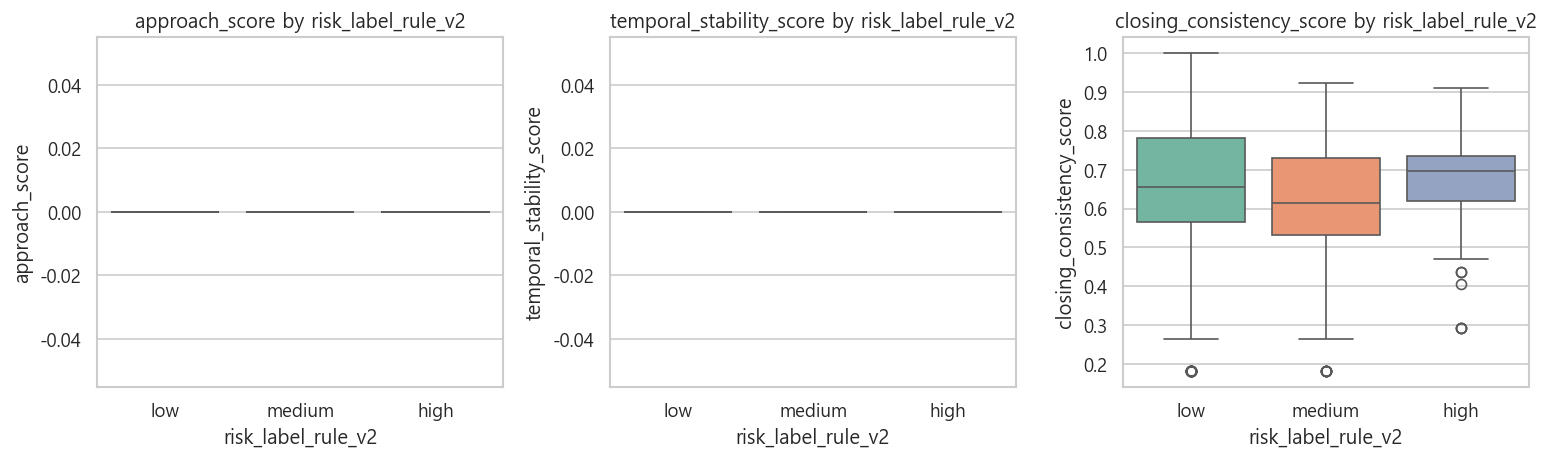

[ops] temporal contribution summary


,mode,feature,pearson_to_score,top10pct_score_lift,top10pct_threshold
0,ops,approach_score,NaN,0.000000,0.000000
1,ops,temporal_stability_score,NaN,0.000000,0.000000
2,ops,motion_smoothness_score,-0.009045,-0.008362,0.394584
3,ops,closing_consistency_score,0.039488,-0.023574,0.888712
4,ops,trajectory_risk_proxy,-0.139930,-0.040765,1.870331



[ops_t20] temporal feature describe


,count,mean,std,min,25%,50%,75%,max
approach_score,2370.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temporal_stability_score,2370.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
motion_smoothness_score,2370.0,0.249588,0.167709,0.027925,0.152445,0.202001,0.300790,1.000000
closing_consistency_score,2370.0,0.688195,0.156011,0.315141,0.574929,0.666994,0.805597,1.000000
trajectory_risk_proxy,2370.0,1.226608,0.666136,0.000000,0.825917,1.144170,1.453757,6.588318


,approach_score,temporal_stability_score,motion_smoothness_score,closing_consistency_score,trajectory_risk_proxy
0,0.0,0.0,0.347534,0.852460,0.594583
1,0.0,0.0,0.306496,0.857887,0.763451
2,0.0,0.0,0.376118,0.861456,0.662576
3,0.0,0.0,0.347534,0.852460,0.594583
4,0.0,0.0,0.216565,0.857574,1.083252
5,0.0,0.0,0.305908,0.868176,0.806257
6,0.0,0.0,0.306496,0.857887,0.763451
7,0.0,0.0,0.425031,0.850823,0.596510
8,0.0,0.0,1.000000,1.000000,0.000000
9,0.0,0.0,0.376118,0.861456,0.662576


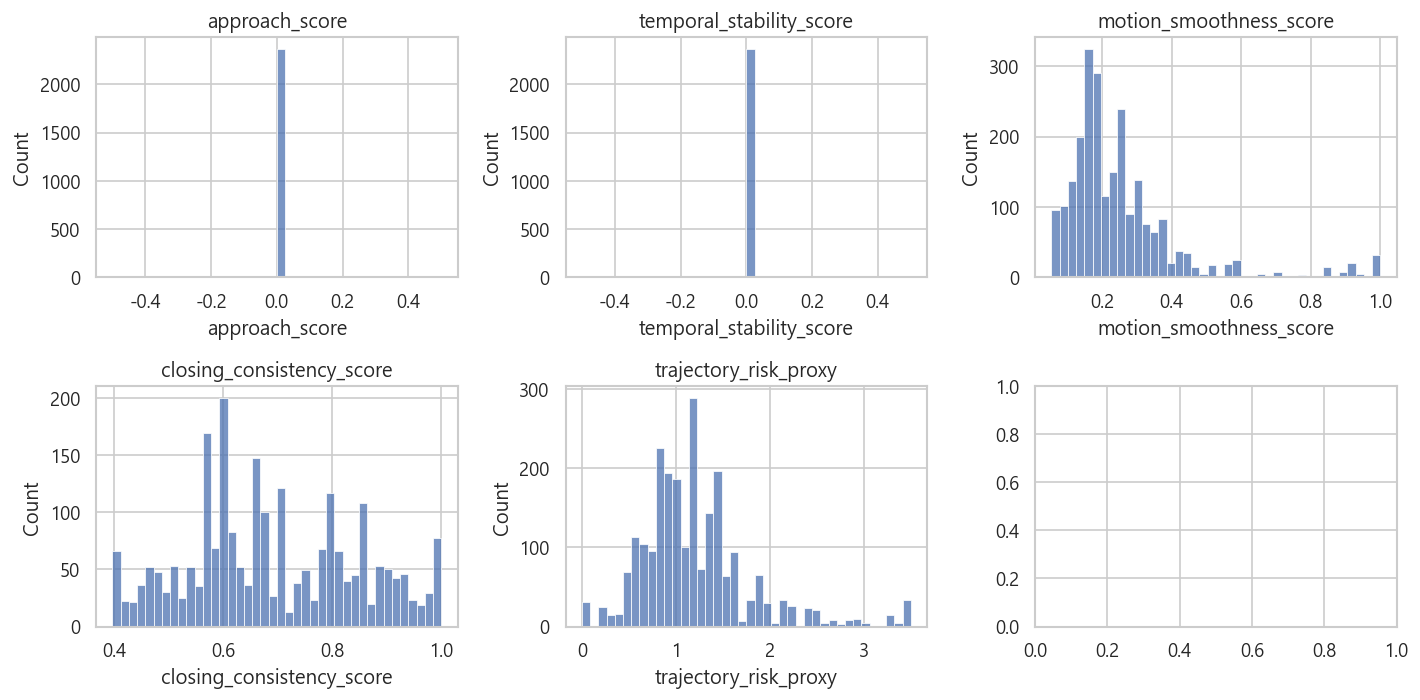

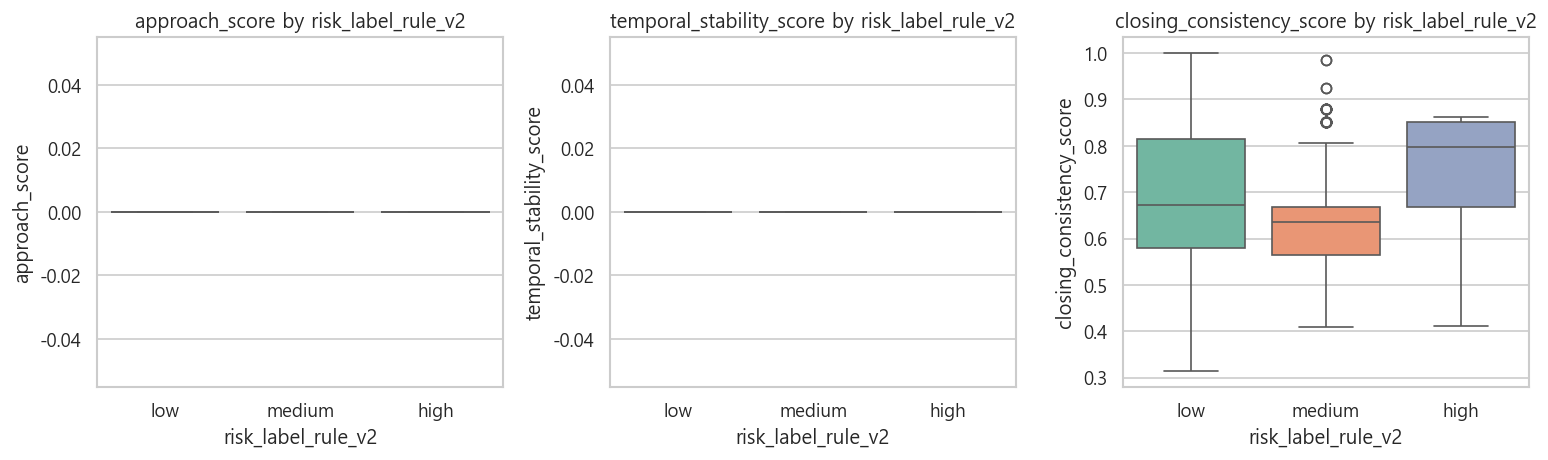

[ops_t20] temporal contribution summary


,mode,feature,pearson_to_score,top10pct_score_lift,top10pct_threshold
0,ops_t20,approach_score,NaN,0.000000,0.000000
1,ops_t20,temporal_stability_score,NaN,0.000000,0.000000
2,ops_t20,motion_smoothness_score,-0.076044,-0.009061,0.420817
4,ops_t20,trajectory_risk_proxy,-0.080033,-0.009688,1.901474
3,ops_t20,closing_consistency_score,-0.010185,-0.024247,0.909431



[ops_t18] temporal feature describe


,count,mean,std,min,25%,50%,75%,max
approach_score,2064.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temporal_stability_score,2064.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
motion_smoothness_score,2064.0,0.242491,0.183592,0.028865,0.138575,0.185956,0.270308,1.000000
closing_consistency_score,2064.0,0.669423,0.167450,0.277764,0.548425,0.638801,0.828064,1.000000
trajectory_risk_proxy,2064.0,1.310332,0.738403,0.000000,0.862291,1.221671,1.567330,6.467907


,approach_score,temporal_stability_score,motion_smoothness_score,closing_consistency_score,trajectory_risk_proxy
0,0.0,0.0,0.347534,0.852460,0.594583
1,0.0,0.0,0.376118,0.861456,0.662576
2,0.0,0.0,0.347534,0.852460,0.594583
3,0.0,0.0,0.302582,0.940299,0.763444
4,0.0,0.0,0.261208,0.893279,0.895581
5,0.0,0.0,0.420990,0.848209,0.599941
6,0.0,0.0,0.376118,0.861456,0.662576
7,0.0,0.0,0.347534,0.852460,0.594583
8,0.0,0.0,0.155610,0.841093,1.431950
9,0.0,0.0,0.302582,0.940299,0.763444


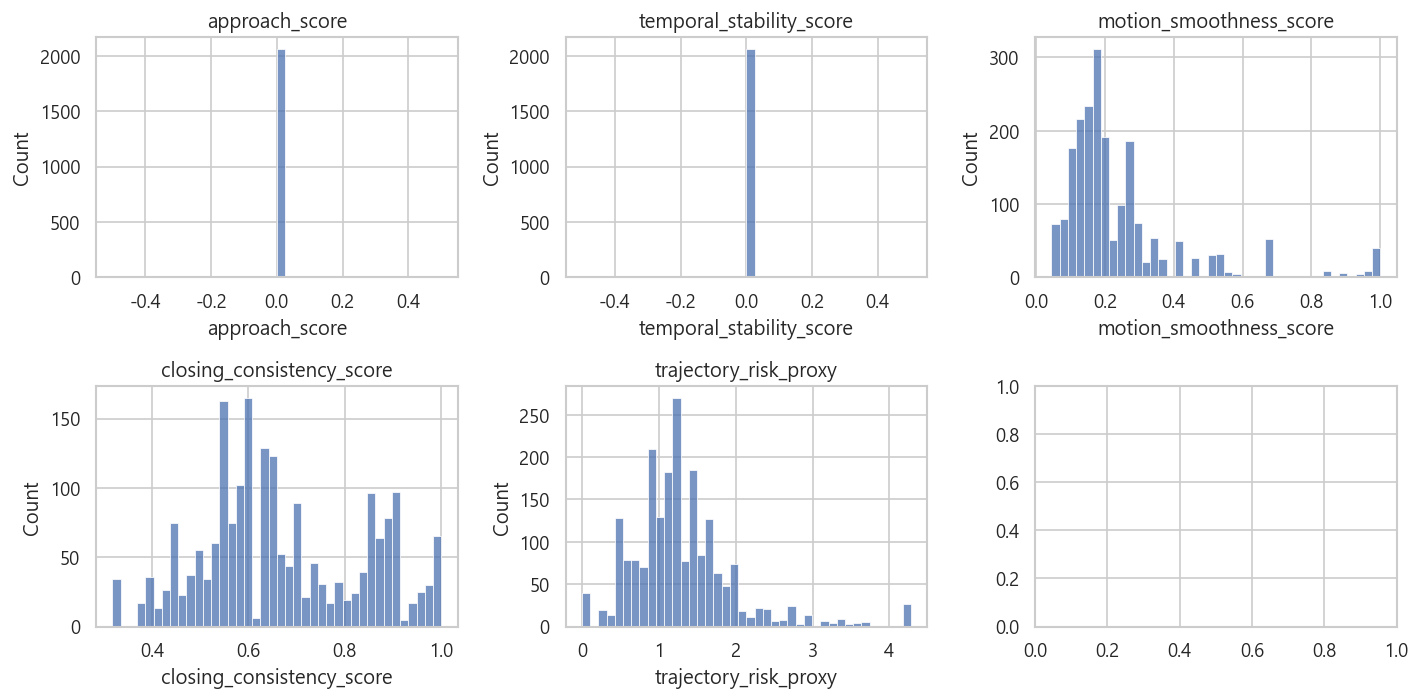

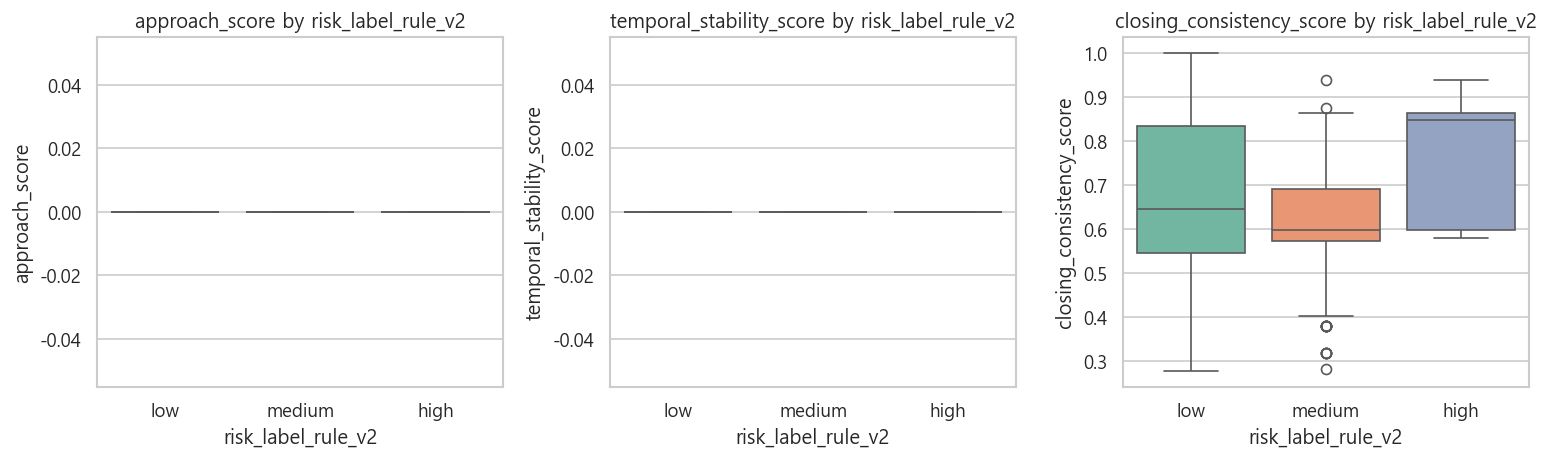

[ops_t18] temporal contribution summary


,mode,feature,pearson_to_score,top10pct_score_lift,top10pct_threshold
0,ops_t18,approach_score,NaN,0.000000,0.000000
1,ops_t18,temporal_stability_score,NaN,0.000000,0.000000
3,ops_t18,closing_consistency_score,0.042246,-0.020605,0.909431
2,ops_t18,motion_smoothness_score,-0.114684,-0.021513,0.463125
4,ops_t18,trajectory_risk_proxy,-0.113901,-0.024458,2.006174



[ops_t15] temporal feature describe


,count,mean,std,min,25%,50%,75%,max
approach_score,1758.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temporal_stability_score,1758.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
motion_smoothness_score,1758.0,0.256597,0.198648,0.036063,0.127313,0.187501,0.320327,1.000000
closing_consistency_score,1758.0,0.687818,0.175575,0.332479,0.534299,0.671884,0.853842,1.000000
trajectory_risk_proxy,1758.0,1.296992,0.715306,0.000000,0.769768,1.177083,1.699636,5.318137


,approach_score,temporal_stability_score,motion_smoothness_score,closing_consistency_score,trajectory_risk_proxy
0,0.0,0.0,0.376118,0.861456,0.662576
1,0.0,0.0,0.103616,0.682490,2.002059
2,0.0,0.0,0.261208,0.893279,0.895581
3,0.0,0.0,0.376118,0.861456,0.662576
4,0.0,0.0,0.103616,0.682490,2.002059
5,0.0,0.0,0.155610,0.841093,1.431950
6,0.0,0.0,1.000000,1.000000,0.000000
7,0.0,0.0,0.261208,0.893279,0.895581
8,0.0,0.0,1.000000,1.000000,0.000000
9,0.0,0.0,0.376118,0.861456,0.662576


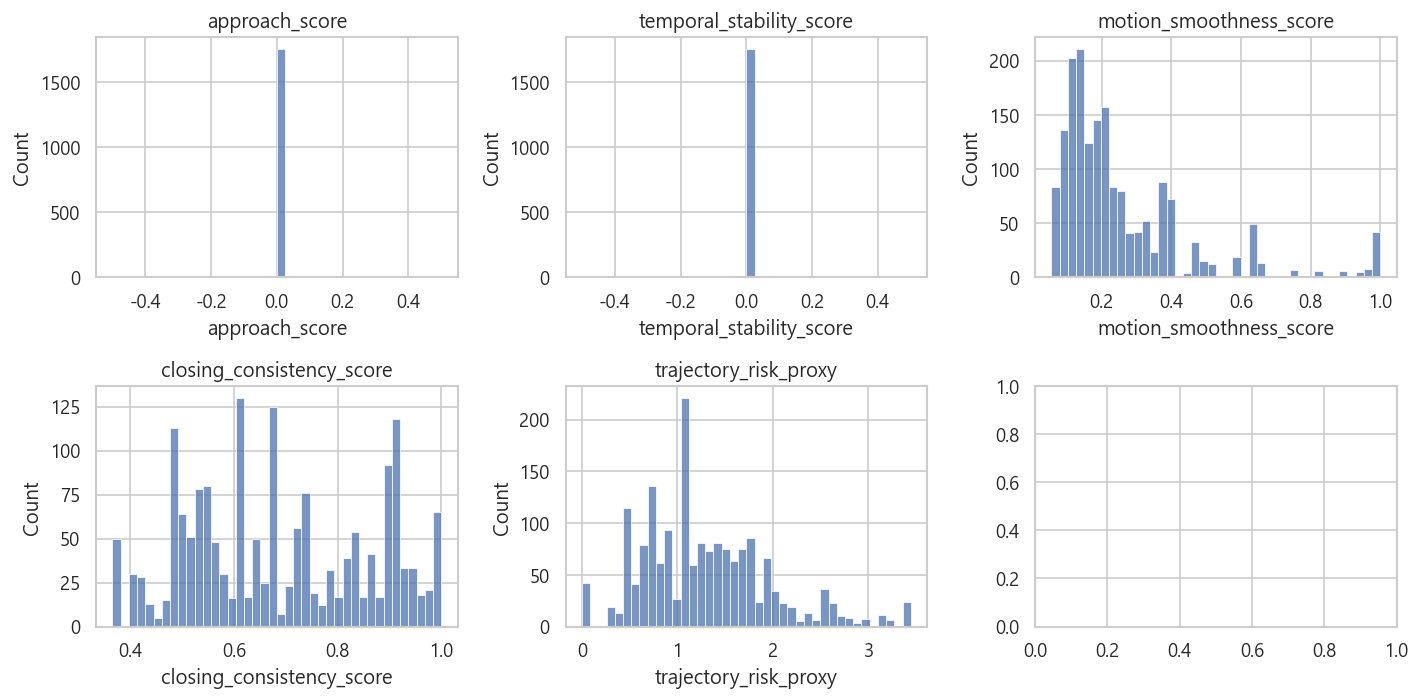

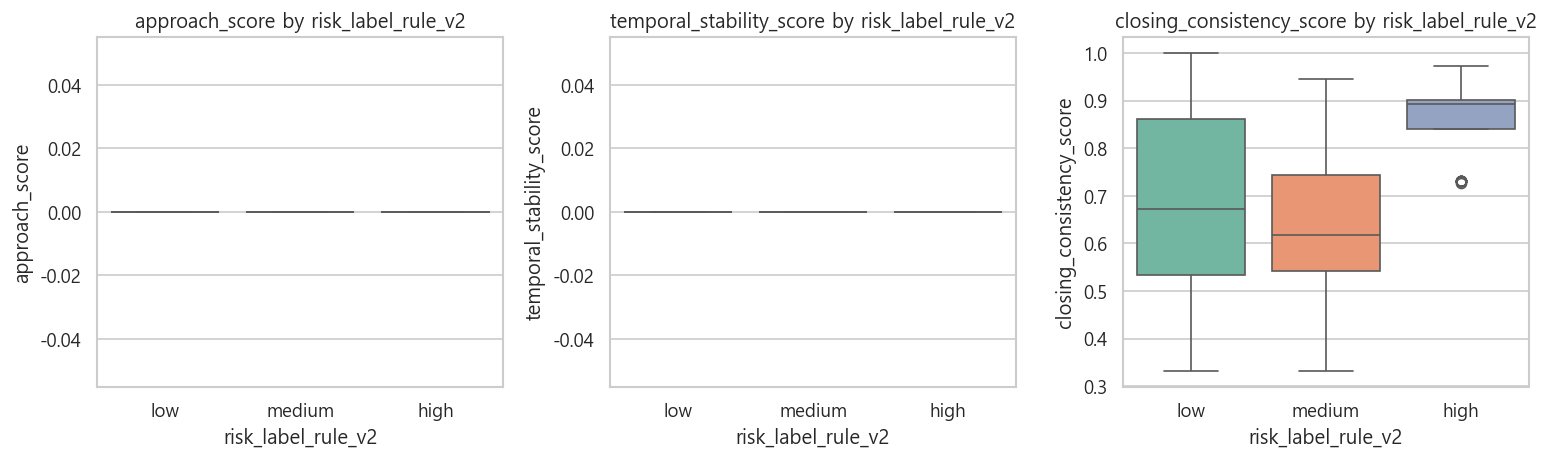

[ops_t15] temporal contribution summary


,mode,feature,pearson_to_score,top10pct_score_lift,top10pct_threshold
0,ops_t15,approach_score,NaN,0.000000,0.000000
1,ops_t15,temporal_stability_score,NaN,0.000000,0.000000
2,ops_t15,motion_smoothness_score,-0.111682,-0.014930,0.493803
4,ops_t15,trajectory_risk_proxy,-0.074617,-0.015000,2.108072
3,ops_t15,closing_consistency_score,0.032992,-0.023641,0.917014


,setting,W_TEMPORAL,precision@10_hard,ranking_ap_soft,ndcg@10_soft,rank_shift_vs_medium
0,weak,0.06,1.0,0.732019,1.0,0.04
1,medium,0.10,1.0,0.671561,1.0,0.00
2,strong,0.14,1.0,0.602112,1.0,0.12


,cluster_uid,track_id,risk_score_rule_v2,closing_consistency_score,motion_smoothness_score,trajectory_risk_proxy
130,hdbscan:00005:22,29,0.333689,0.944389,0.562751,0.462764
192,hdbscan:00006:36,29,0.334480,0.944389,0.562751,0.462764
242,hdbscan:00007:39,29,0.336638,0.944389,0.562751,0.462764
3327,hdbscan:00108:13,264,0.338727,1.000000,1.000000,0.000000


WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/sec18_temporal_topk_changed_examples_v22.csv')

In [18]:

temp_cols = [
    "approach_score",
    "temporal_stability_score",
    "motion_smoothness_score",
    "closing_consistency_score",
    "trajectory_risk_proxy",
]

for m, R in RESULTS.items():
    d = R.cluster_df_final.copy()
    print(f"\n[{m}] temporal feature describe")
    display(d[[c for c in temp_cols if c in d.columns]].describe().T)
    display(d[[c for c in temp_cols if c in d.columns]].head(10))

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    axes = axes.ravel()
    for i, c in enumerate(temp_cols):
        if c in d.columns:
            lo = d[c].quantile(0.01)
            hi = d[c].quantile(0.99)
            sns.histplot(d[c].clip(lower=lo, upper=hi), bins=40, ax=axes[i], color="#4c72b0")
            axes[i].set_title(c)
    plt.tight_layout()
    save_fig(f"sec18_temporal_hist_{m}")
    plt.show()

    if "risk_label_rule_v2" in d.columns:
        lbl_order = ["low", "medium", "high"]
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        for i, c in enumerate(["approach_score", "temporal_stability_score", "closing_consistency_score"]):
            if c in d.columns:
                sns.boxplot(data=d, x="risk_label_rule_v2", y=c, order=lbl_order, ax=axes[i], palette="Set2")
                axes[i].set_title(f"{c} by risk_label_rule_v2")
        plt.tight_layout()
        save_fig(f"sec18_temporal_box_by_label_{m}")
        plt.show()

    score_col = "score_final_stage4" if "score_final_stage4" in d.columns else ("risk_score_hybrid_stage4" if "risk_score_hybrid_stage4" in d.columns else None)
    if score_col is not None:
        rows = []
        for c in temp_cols:
            if c in d.columns:
                corr = float(d[[c, score_col]].corr(numeric_only=True).iloc[0, 1])
                thr = float(d[c].quantile(0.90))
                top_mask = d[c] >= thr
                lift = float(d.loc[top_mask, score_col].mean() - d[score_col].mean())
                rows.append({
                    "mode": m,
                    "feature": c,
                    "pearson_to_score": corr,
                    "top10pct_score_lift": lift,
                    "top10pct_threshold": thr,
                })
        contrib_df = pd.DataFrame(rows).sort_values("top10pct_score_lift", ascending=False)
        print(f"[{m}] temporal contribution summary")
        display(contrib_df)
        save_table(contrib_df, f"sec18_temporal_contribution_{m}")

Rref = RESULTS["full"]
base = Rref.cluster_df_calibrated.copy()
temporal_rows = []
top_sets = {}
for tag, wt in [("weak", 0.06), ("medium", 0.10), ("strong", 0.14)]:
    d = base.copy()
    d["score_tmp"] = (
        d["risk_score_rule_v2"].clip(0, 1)
        + 0.12 * d["lidar_corroboration_score_v2"].fillna(0)
        + wt * (0.5 * d["closing_consistency_score"].fillna(0) + 0.5 * d["motion_smoothness_score"].fillna(0))
        + 0.10 * d["risk_confidence_calibrated"].fillna(0)
        + 0.08 * d.get("proposal_quality_score", pd.Series(0.0, index=d.index)).fillna(0)
        - 0.20 * d["risk_uncertainty"].fillna(0)
    ).clip(0, 1)
    hard = (d["risk_label_rule_v2"] == "high").astype(int).to_numpy()
    soft = (d["risk_score_rule_v2"] >= d["risk_score_rule_v2"].quantile(0.90)).astype(int).to_numpy()
    rk = v2.ranking_metrics_extended(hard, d["score_tmp"].to_numpy(), soft_positive=soft, ks=[10, 20])
    top_ids = set(d.sort_values("score_tmp", ascending=False).head(50)["cluster_uid"].tolist())
    top_sets[tag] = top_ids
    temporal_rows.append({
        "setting": tag,
        "W_TEMPORAL": wt,
        "precision@10_hard": rk.get("precision@10_hard", np.nan),
        "ranking_ap_soft": rk.get("average_precision_soft", np.nan),
        "ndcg@10_soft": rk.get("ndcg@10_soft", np.nan),
    })

temporal_effectiveness_report_df = pd.DataFrame(temporal_rows)
mid = top_sets["medium"]
temporal_effectiveness_report_df["rank_shift_vs_medium"] = [
    float(len(top_sets[s] ^ mid) / max(len(mid), 1)) for s in temporal_effectiveness_report_df["setting"]
]
display(temporal_effectiveness_report_df)
save_table(temporal_effectiveness_report_df, "sec18_temporal_effectiveness_report")

changed_idx = list((top_sets["strong"] - top_sets["weak"]))[:10]
show_cols = [
    c for c in [
        "cluster_uid",
        "track_id",
        "risk_score_rule_v2",
        "closing_consistency_score",
        "motion_smoothness_score",
        "trajectory_risk_proxy",
    ]
    if c in base.columns
]
if "cluster_uid" in base.columns:
    temporal_topk_changed_examples = base[base["cluster_uid"].isin(changed_idx)][show_cols].copy()
else:
    valid_idx = [i for i in changed_idx if i in base.index]
    temporal_topk_changed_examples = base.loc[valid_idx, show_cols].copy()

display(temporal_topk_changed_examples)
save_table(temporal_topk_changed_examples, "sec18_temporal_topk_changed_examples")


## Section 19. Final summary + ops source trace + sanity checks

In [19]:

def _metric_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _pick_best_row(df: pd.DataFrame) -> pd.Series:
    if len(df) == 0:
        return pd.Series(dtype=float)
    mcol = _metric_col(df, ["macro_f1", "test_macro_f1"])
    hcol = _metric_col(df, ["high_recall"])
    acol = _metric_col(df, ["ap_soft", "ranking_ap", "average_precision_soft"])
    gcol = _metric_col(df, ["overfit_gap", "train_test_gap"])
    x = df.copy()
    x["_score"] = 0.0
    if mcol:
        x["_score"] += x[mcol].fillna(0)
    if hcol:
        x["_score"] += 0.15 * x[hcol].fillna(0)
    if acol:
        x["_score"] += 0.10 * x[acol].fillna(0)
    if gcol:
        x["_score"] -= 0.05 * x[gcol].abs().fillna(0)
    return x.sort_values(["_score"], ascending=False).iloc[0]


def _best_model_tables_for_mode(mode: str, R):
    exp = R.experiment_results_df.copy()
    if "task" in exp.columns:
        exp = exp[exp["task"] == "classification"].copy()
    if len(exp) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float)

    ssum = R.split_summary_df.copy()
    if "split" in ssum.columns:
        exp = exp.merge(ssum[["split", "n_test", "test_high"]], on="split", how="left")
    else:
        exp["n_test"] = np.nan
        exp["test_high"] = np.nan

    best_overall = _pick_best_row(exp)

    honest = exp.copy()
    honest = honest[honest["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"])]
    honest = honest[honest["split"].isin(e2e.HONEST_SPLITS)]
    if "test_high" in honest.columns:
        honest = honest[(honest["test_high"].fillna(0) >= 20) | (honest["n_test"].fillna(0) >= 1000)]
    if len(honest) == 0:
        # fallback: honest split은 유지하되 support 조건만 완화
        honest = exp[exp["feature_set"].isin(["A_strict_anti_leakage", "B_moderate_anti_leakage"]) & exp["split"].isin(e2e.HONEST_SPLITS)]
    best_honest = _pick_best_row(honest)

    return best_overall, best_honest


best_overall_rows = []
best_honest_rows = []
for m, R in RESULTS.items():
    bo, bh = _best_model_tables_for_mode(m, R)
    if len(bo):
        best_overall_rows.append({
            "pipeline_mode": m,
            "model": bo.get("model", np.nan),
            "feature_set": bo.get("feature_set", np.nan),
            "split": bo.get("split", np.nan),
            "macro_f1": float(bo.get("macro_f1", bo.get("test_macro_f1", np.nan))),
            "high_recall": float(bo.get("high_recall", np.nan)),
            "ap_soft": float(bo.get("ap_soft", bo.get("ranking_ap", np.nan))),
            "test_n": float(bo.get("n_test", np.nan)),
            "test_high": float(bo.get("test_high", np.nan)),
        })
    if len(bh):
        best_honest_rows.append({
            "pipeline_mode": m,
            "model": bh.get("model", np.nan),
            "feature_set": bh.get("feature_set", np.nan),
            "split": bh.get("split", np.nan),
            "macro_f1": float(bh.get("macro_f1", bh.get("test_macro_f1", np.nan))),
            "high_recall": float(bh.get("high_recall", np.nan)),
            "ap_soft": float(bh.get("ap_soft", bh.get("ranking_ap", np.nan))),
            "test_n": float(bh.get("n_test", np.nan)),
            "test_high": float(bh.get("test_high", np.nan)),
        })

best_model_summary_overall = pd.DataFrame(best_overall_rows)
best_model_summary_honest = pd.DataFrame(best_honest_rows)

display(best_model_summary_overall)
display(best_model_summary_honest)
save_table(best_model_summary_overall, "sec19_best_model_summary_overall")
save_table(best_model_summary_honest, "sec19_best_model_summary_honest")


def _summary_row(scope: str, m: str, R, hb_row: pd.Series):
    rk = R.ranking_summary_df.set_index("metric")["value"].to_dict()
    cb = R.calibration_bundle
    return {
        "summary_scope": scope,
        "pipeline_mode": m,
        "selected_clusterer": selected_cluster_algo,
        "selected_tracking_mode": R.selected_tracking_mode,
        "selected_threshold_strategy": "quantile-gated + track sensitivity",
        "honest_best_model": str(hb_row.get("model", np.nan)),
        "honest_eval_split": str(hb_row.get("split", np.nan)),
        "honest_feature_set": str(hb_row.get("feature_set", np.nan)),
        "macro_f1": float(hb_row.get("macro_f1", np.nan)),
        "high_recall": float(hb_row.get("high_recall", np.nan)),
        "ranking_ap": float(rk.get("ap_soft", np.nan)),
        "burden_per_frame": float(rk.get("candidate_burden_per_frame", np.nan)),
        "runtime_sec_total": float(pd.DataFrame(runtime_records)["sec"].sum()) if runtime_records else np.nan,
        "calibration_used": bool(cb["calibration_used"]),
        "selected_calibration_method": str(cb["selected_calibration_method"]),
        "brier_raw": float(cb["brier_raw"]),
        "brier_selected": float(cb["brier_selected"]),
        "ece_raw": float(cb["ece_raw"]),
        "ece_selected": float(cb["ece_selected"]),
    }


ops_mode = "ops"
if "recommended_operating_point_df" in globals() and len(recommended_operating_point_df):
    ops_mode = str(recommended_operating_point_df.iloc[0]["mode"])

hb_map = best_model_summary_honest.set_index("pipeline_mode") if len(best_model_summary_honest) else pd.DataFrame()

final_rows = []
for scope, m in [("research_full", "full"), ("ops_low_burden", ops_mode)]:
    R = RESULTS[m]
    hb = hb_map.loc[m] if (len(hb_map) and m in hb_map.index) else pd.Series(dtype=float)
    final_rows.append(_summary_row(scope, m, R, hb))

final_summary_df = pd.DataFrame(final_rows)
display(final_summary_df)
save_table(final_summary_df, "sec19_final_summary_research_vs_ops")

# source trace transparency (honest 기준)
trace_rows = []
for _, row in final_summary_df.iterrows():
    m = row["pipeline_mode"]
    R = RESULTS[m]
    exp = R.experiment_results_df
    q = exp[
        (exp["task"] == "classification")
        & (exp["model"] == row["honest_best_model"])
        & (exp["feature_set"] == row["honest_feature_set"])
        & (exp["split"] == row["honest_eval_split"])
    ]
    assert len(q) == 1, f"source trace mismatch for mode={m}"
    qr = q.iloc[0]
    split_row = R.split_summary_df[R.split_summary_df["split"] == row["honest_eval_split"]].iloc[0]
    trace_rows.append(
        {
            "pipeline_mode": m,
            "source_model": qr["model"],
            "source_feature_set": qr["feature_set"],
            "source_split": qr["split"],
            "source_macro_f1": qr.get("macro_f1", qr.get("test_macro_f1", np.nan)),
            "source_high_recall": qr.get("high_recall", np.nan),
            "source_test_n": split_row["n_test"],
            "source_test_high_n": split_row["test_high"],
            "summary_macro_f1": row["macro_f1"],
            "summary_high_recall": row["high_recall"],
        }
    )

ops_summary_source_trace_df = pd.DataFrame(trace_rows)
display(ops_summary_source_trace_df)
save_table(ops_summary_source_trace_df, "sec19_ops_summary_source_trace")

# sanity checks
for _, row in final_summary_df.iterrows():
    assert str(row["honest_eval_split"]) in e2e.HONEST_SPLITS, "random split mixed in final summary"
    assert str(row["honest_feature_set"]) in {"A_strict_anti_leakage", "B_moderate_anti_leakage"}, "leakage feature set mixed in final summary"

# calibration 선택 정책 재검증
for m, R in RESULTS.items():
    cb = R.calibration_bundle
    if bool(cb.get("calibration_used", False)):
        assert float(cb["brier_selected"]) <= float(cb["brier_raw"]) + 1e-12, f"{m}: brier not improved"
        assert float(cb["ece_selected"]) <= float(cb["ece_raw"]) + 1e-12, f"{m}: ece not improved"

perfect_warn = ops_summary_source_trace_df[
    (ops_summary_source_trace_df["source_macro_f1"] >= 0.9999)
    & (ops_summary_source_trace_df["source_high_recall"] >= 0.9999)
    & (ops_summary_source_trace_df["source_test_high_n"] < 20)
]
if len(perfect_warn):
    print("[경고] subset이 너무 작은 perfect score 가능성")
    display(perfect_warn)

,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ap_soft,test_n,test_high
0,full,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.819050,1539.0,33.0
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812,1099.0,21.0
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397,635.0,12.0
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777,557.0,11.0
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982,466.0,4.0


,pipeline_mode,model,feature_set,split,macro_f1,high_recall,ap_soft,test_n,test_high
0,full,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,0.819050,1539.0,33.0
1,ops,logreg,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.750812,1099.0,21.0
2,ops_t20,logreg,B_moderate_anti_leakage,group_frame,0.953744,0.833333,0.828397,635.0,12.0
3,ops_t18,logreg,B_moderate_anti_leakage,group_frame,0.975733,0.909091,0.684777,557.0,11.0
4,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,0.551982,466.0,4.0


,summary_scope,pipeline_mode,selected_clusterer,selected_tracking_mode,selected_threshold_strategy,honest_best_model,honest_eval_split,honest_feature_set,macro_f1,high_recall,ranking_ap,burden_per_frame,runtime_sec_total,calibration_used,selected_calibration_method,brier_raw,brier_selected,ece_raw,ece_selected
0,research_full,full,hdbscan,improved,quantile-gated + track sensitivity,hgb,group_frame,B_moderate_anti_leakage,0.984043,0.939394,0.917942,33.822222,789.87837,False,raw,1.427967e-03,1.427967e-03,0.001747,0.001747
1,ops_low_burden,ops_t15,hdbscan,improved,quantile-gated + track sensitivity,hgb,group_frame,B_moderate_anti_leakage,1.000000,1.000000,0.832818,9.876404,789.87837,False,raw,1.221058e-08,1.221058e-08,0.000007,0.000007


,pipeline_mode,source_model,source_feature_set,source_split,source_macro_f1,source_high_recall,source_test_n,source_test_high_n,summary_macro_f1,summary_high_recall
0,full,hgb,B_moderate_anti_leakage,group_frame,0.984043,0.939394,1539,33,0.984043,0.939394
1,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.000000,1.000000,466,4,1.000000,1.000000


[경고] subset이 너무 작은 perfect score 가능성


,pipeline_mode,source_model,source_feature_set,source_split,source_macro_f1,source_high_recall,source_test_n,source_test_high_n,summary_macro_f1,summary_high_recall
1,ops_t15,hgb,B_moderate_anti_leakage,group_frame,1.0,1.0,466,4,1.0,1.0


## Section 18.5. v22 diagnostics helpers

v21 이상 징후를 원인 기반으로 추적하기 위한 공통 유틸 함수입니다.

In [20]:
# v22 diagnostics helpers
try:
    from scipy.stats import kruskal
except Exception:
    kruskal = None

PLOT_STYLE = {
    "axes.facecolor": "#ffffff",
    "figure.facecolor": "#f8fafc",
    "axes.edgecolor": "#cbd5e1",
    "axes.grid": True,
    "grid.color": "#e2e8f0",
    "grid.alpha": 0.75,
}
for k, v in PLOT_STYLE.items():
    plt.rcParams[k] = v


def _safe_df(obj) -> pd.DataFrame:
    return obj.copy() if isinstance(obj, pd.DataFrame) else pd.DataFrame()


def _first_df_attr(R, names: list[str]) -> pd.DataFrame:
    for n in names:
        if hasattr(R, n):
            d = getattr(R, n)
            if isinstance(d, pd.DataFrame) and len(d.columns):
                return d.copy()
    return pd.DataFrame()


def _series_stats(s: pd.Series) -> dict:
    x = pd.to_numeric(s, errors="coerce")
    x_no_nan = x.dropna()
    n = len(x)
    if n == 0:
        return {
            "count": 0,
            "nan_ratio": np.nan,
            "zero_ratio": np.nan,
            "nonzero_ratio": np.nan,
            "unique_count": 0,
            "variance": np.nan,
            "iqr": np.nan,
            "nonzero_mean": np.nan,
        }
    zero_ratio = float((x.fillna(0) == 0).mean())
    nz = x_no_nan[x_no_nan != 0]
    return {
        "count": int(n),
        "nan_ratio": float(x.isna().mean()),
        "zero_ratio": zero_ratio,
        "nonzero_ratio": float(1 - zero_ratio),
        "unique_count": int(x_no_nan.nunique()),
        "variance": float(x_no_nan.var(ddof=0)) if len(x_no_nan) else np.nan,
        "iqr": float(x_no_nan.quantile(0.75) - x_no_nan.quantile(0.25)) if len(x_no_nan) else np.nan,
        "nonzero_mean": float(nz.mean()) if len(nz) else 0.0,
    }


def _health_label(st: dict) -> str:
    if (st["zero_ratio"] >= 0.98) or (st["unique_count"] <= 2) or (pd.notna(st["variance"]) and st["variance"] < 1e-10):
        return "dead"
    if (st["zero_ratio"] >= 0.90) or (pd.notna(st["iqr"]) and st["iqr"] == 0):
        return "weak"
    return "healthy"


def _reconstruct_approach_v22(df: pd.DataFrame) -> pd.Series:
    if len(df) == 0:
        return pd.Series(dtype=float)
    x = df.copy()
    if "cluster_uid" in x.columns and "track_id" not in x.columns:
        x["track_id"] = x["cluster_uid"]
    if "track_id" not in x.columns:
        x["track_id"] = np.arange(len(x))
    if "frame_order" not in x.columns:
        x["frame_order"] = np.arange(len(x))
    by = x.sort_values(["track_id", "frame_order"]).groupby("track_id", dropna=False)
    dr = by["range_xy"].diff() if "range_xy" in x.columns else pd.Series(np.nan, index=x.index)
    score = (-dr).fillna(0.0)
    if "v_r_compensated" in x.columns:
        vr = pd.to_numeric(x["v_r_compensated"], errors="coerce").fillna(0.0)
        score = 0.7 * score + 0.3 * (-vr)
    ql, qh = score.quantile([0.01, 0.99]) if len(score) else (0, 1)
    score = score.clip(lower=ql, upper=qh)
    mn, mx = float(score.min()), float(score.max())
    if mx > mn:
        score = (score - mn) / (mx - mn)
    else:
        score = pd.Series(0.0, index=score.index)
    return score.reindex(x.index)


def _reconstruct_temporal_stability_v22(df: pd.DataFrame) -> pd.Series:
    if len(df) == 0:
        return pd.Series(dtype=float)
    x = df.copy()
    tlen = pd.to_numeric(x.get("track_len", pd.Series(1, index=x.index)), errors="coerce").fillna(1.0)
    hchg = pd.to_numeric(x.get("heading_change", pd.Series(0.0, index=x.index)), errors="coerce").fillna(0.0)
    sm = pd.to_numeric(x.get("motion_smoothness_score", pd.Series(np.nan, index=x.index)), errors="coerce")
    len_term = (np.log1p(tlen) / np.log1p(max(float(tlen.max()), 2.0))).clip(0, 1)
    h_term = (1.0 / (1.0 + hchg.abs())).clip(0, 1)
    sm_term = sm.fillna(sm.median() if sm.notna().any() else 0.5).clip(0, 1)
    score = 0.45 * len_term + 0.35 * h_term + 0.20 * sm_term
    short_mask = tlen <= 2
    if short_mask.any():
        score.loc[short_mask] = (0.60 * h_term.loc[short_mask] + 0.40 * len_term.loc[short_mask]).clip(0, 1)
    return score.clip(0, 1)


def _calibration_metrics(y_true: np.ndarray, p: np.ndarray, n_bins: int = 10) -> tuple[dict, pd.DataFrame]:
    y = np.asarray(y_true).astype(int)
    p = np.asarray(p).astype(float)
    mask = np.isfinite(y) & np.isfinite(p)
    y, p = y[mask], p[mask]
    if len(y) == 0:
        m = {"ece": np.nan, "mce": np.nan, "brier": np.nan, "n_bins_used": 0, "total_samples": 0}
        return m, pd.DataFrame(columns=["bin", "left", "right", "count", "acc", "conf", "gap"])
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bid = np.digitize(p, bins[1:-1], right=True)
    rows = []
    ece = 0.0
    mce = 0.0
    for b in range(n_bins):
        idx = bid == b
        cnt = int(idx.sum())
        if cnt == 0:
            acc = np.nan
            conf = np.nan
            gap = np.nan
        else:
            acc = float(y[idx].mean())
            conf = float(p[idx].mean())
            gap = abs(acc - conf)
            ece += gap * (cnt / len(y))
            mce = max(mce, gap)
        rows.append({
            "bin": b + 1,
            "left": float(bins[b]),
            "right": float(bins[b + 1]),
            "count": cnt,
            "acc": acc,
            "conf": conf,
            "gap": gap,
        })
    metrics = {
        "ece": float(ece),
        "mce": float(mce),
        "brier": float(np.mean((p - y) ** 2)),
        "n_bins_used": int(sum(r["count"] > 0 for r in rows)),
        "total_samples": int(len(y)),
    }
    return metrics, pd.DataFrame(rows)


def _reliability_with_counts_plot(cal_rows: list[dict], filename: str = "reliability_with_counts"):
    n = len(cal_rows)
    cols = 3
    rows = int(math.ceil(n / cols)) if n else 1
    fig, axes = plt.subplots(rows, cols, figsize=(5.6 * cols, 4.3 * rows), squeeze=False)
    axes = axes.ravel()
    for i, rec in enumerate(cal_rows):
        ax = axes[i]
        raw_df = rec["bin_raw"]
        sel_df = rec["bin_selected"]
        ax.plot([0, 1], [0, 1], ls="--", color="#94a3b8", lw=1.2, label="ideal")
        if len(raw_df):
            ax.plot(raw_df["conf"], raw_df["acc"], marker="o", color="#ef4444", lw=1.6, label="raw")
            for _, r in raw_df.dropna(subset=["conf", "acc"]).iterrows():
                ax.text(r["conf"], r["acc"], f"n={int(r['count'])}", fontsize=8, color="#b91c1c", ha="left", va="bottom")
        if len(sel_df):
            ax.plot(sel_df["conf"], sel_df["acc"], marker="s", color="#0ea5e9", lw=1.8, label="selected")
            for _, r in sel_df.dropna(subset=["conf", "acc"]).iterrows():
                ax.text(r["conf"], r["acc"], f"n={int(r['count'])}", fontsize=8, color="#075985", ha="right", va="top")
        warn = rec.get("warning", "")
        ax.set_title(f"mode={rec['mode']}" + (f"\n주의: {warn}" if warn else ""), fontsize=11, fontweight="bold")
        ax.set_xlabel("Confidence")
        ax.set_ylabel("Empirical positive rate")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.legend(loc="lower right", fontsize=8)
    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle("Reliability diagram with bin sample counts", fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


def _confidence_hist_by_mode(cal_rows: list[dict], filename: str = "confidence_histograms_by_mode"):
    n = len(cal_rows)
    fig, axes = plt.subplots(n, 1, figsize=(10.5, 2.8 * max(n, 1)), squeeze=False)
    for i, rec in enumerate(cal_rows):
        ax = axes[i, 0]
        p_raw = rec["p_raw"]
        p_sel = rec["p_selected"]
        if len(p_raw):
            ax.hist(p_raw, bins=20, alpha=0.45, color="#ef4444", label="raw")
        if len(p_sel):
            ax.hist(p_sel, bins=20, alpha=0.45, color="#0ea5e9", label="selected")
        ax.set_title(f"mode={rec['mode']} confidence histogram", fontsize=10)
        ax.set_xlabel("Predicted confidence")
        ax.set_ylabel("Count")
        ax.legend(loc="upper center", ncol=2, fontsize=8)
    fig.suptitle("Confidence histograms by mode", fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout()
    save_fig(filename)
    plt.show()


## Section 18.6. v22 integrated diagnostics execution

- A. feature health check
- B. calibration summary
- C. suppression stage effectiveness
- D. label separability
- E. final recommendation

,mode,feature,count,nan_ratio,zero_ratio,nonzero_ratio,unique_count,variance,iqr,nonzero_mean,health
0,full,approach_score,6088,0.0,1.000000,0.000000,1,0.000000,0.000000,0.000000,dead
3,full,closing_consistency_score,6088,0.0,0.000000,1.000000,417,0.023856,0.215493,0.654746,healthy
2,full,motion_smoothness_score,6088,0.0,0.000000,1.000000,417,0.016557,0.118575,0.232293,healthy
1,full,temporal_stability_score,6088,0.0,1.000000,0.000000,1,0.000000,0.000000,0.000000,dead
4,full,trajectory_risk_proxy,6088,0.0,0.008870,0.991130,417,0.287622,0.579823,1.217284,healthy
5,ops,approach_score,4497,0.0,1.000000,0.000000,1,0.000000,0.000000,0.000000,dead
8,ops,closing_consistency_score,4497,0.0,0.000000,1.000000,321,0.023806,0.213904,0.665596,healthy
7,ops,motion_smoothness_score,4497,0.0,0.000000,1.000000,321,0.018491,0.123772,0.232674,healthy
6,ops,temporal_stability_score,4497,0.0,1.000000,0.000000,1,0.000000,0.000000,0.000000,dead
9,ops,trajectory_risk_proxy,4497,0.0,0.007783,0.992217,321,0.318601,0.596494,1.236521,healthy


,mode,step,feature,count,nan_ratio,zero_ratio,nonzero_ratio,unique_count,variance,iqr,nonzero_mean
2,full,final,approach_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
5,full,post_fill_clip_proxy,approach_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
4,full,scaling_proxy,approach_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
0,full,tracked,approach_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
3,full,final,temporal_stability_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
7,full,post_fill_clip_proxy,temporal_stability_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
6,full,scaling_proxy,temporal_stability_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
1,full,tracked,temporal_stability_score,6088,0.0,1.0,0.0,1,0.0,0.0,0.0
10,ops,final,approach_score,4497,0.0,1.0,0.0,1,0.0,0.0,0.0
13,ops,post_fill_clip_proxy,approach_score,4497,0.0,1.0,0.0,1,0.0,0.0,0.0


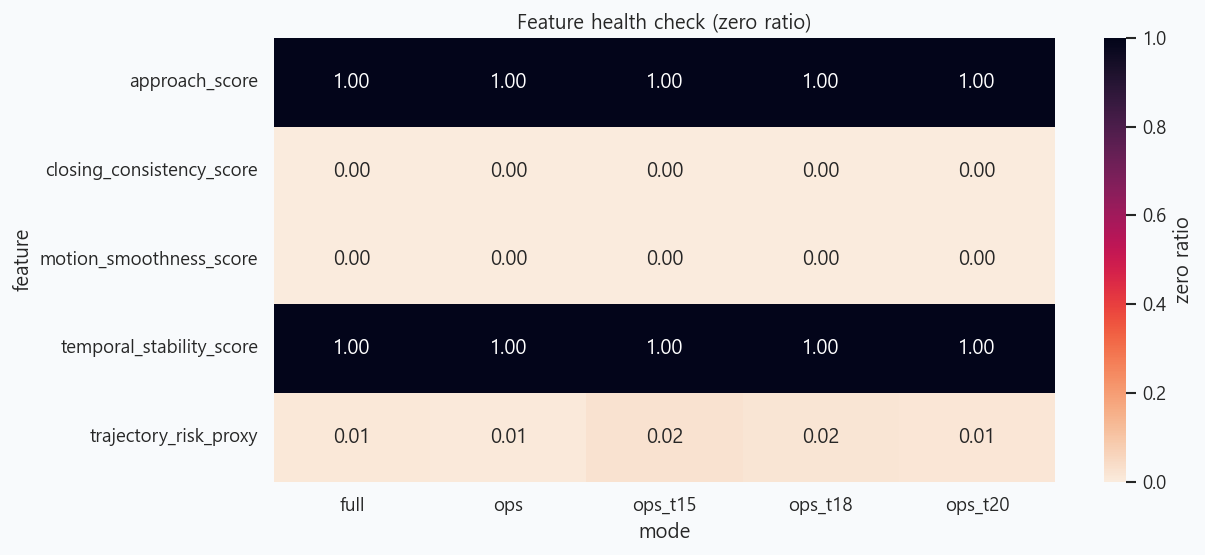

,mode,feature,diagnosis
0,full,approach_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
1,full,temporal_stability_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
2,ops,approach_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
3,ops,temporal_stability_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
4,ops_t15,approach_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
5,ops_t15,temporal_stability_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
6,ops_t18,approach_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
7,ops_t18,temporal_stability_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
8,ops_t20,approach_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...
9,ops_t20,temporal_stability_score,zero ratio 높음; unique 값 부족; 짧은 track_len로 roll...


,mode,ece_raw,ece_selected,mce_raw,mce_selected,brier_raw,brier_selected,n_bins_used_raw,n_bins_used_selected,total_samples,warning
0,full,0.049727,0.049727,0.965158,0.965158,0.049413,0.049413,5,5,1539,
1,ops,0.056008,0.056008,0.937063,0.937063,0.055866,0.055866,5,5,1099,
4,ops_t15,0.042912,0.042912,0.999997,0.999997,0.042918,0.042918,2,2,466,ops_t15 정보량 부족 가능성
3,ops_t18,0.046196,0.046196,0.994253,0.994253,0.044881,0.044881,6,6,557,
2,ops_t20,0.040677,0.040677,0.988873,0.988873,0.042196,0.042196,7,7,635,


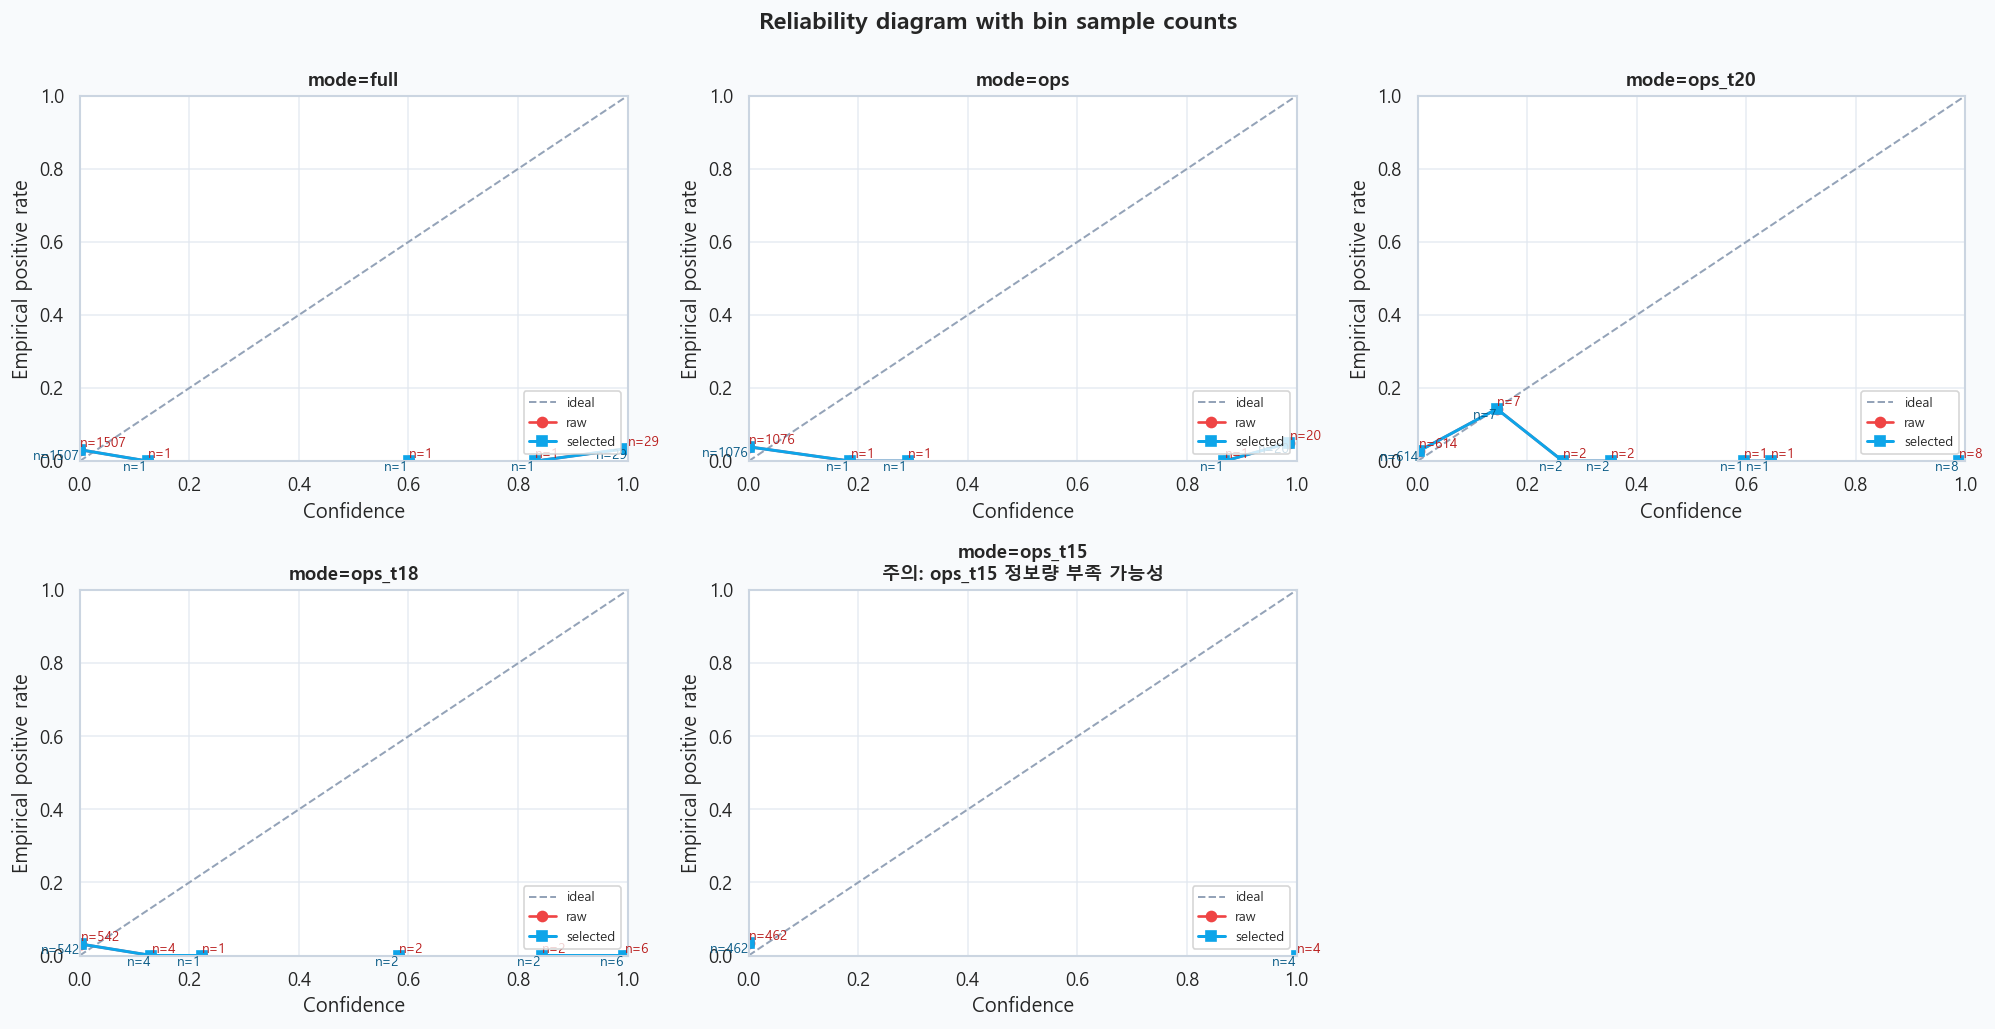

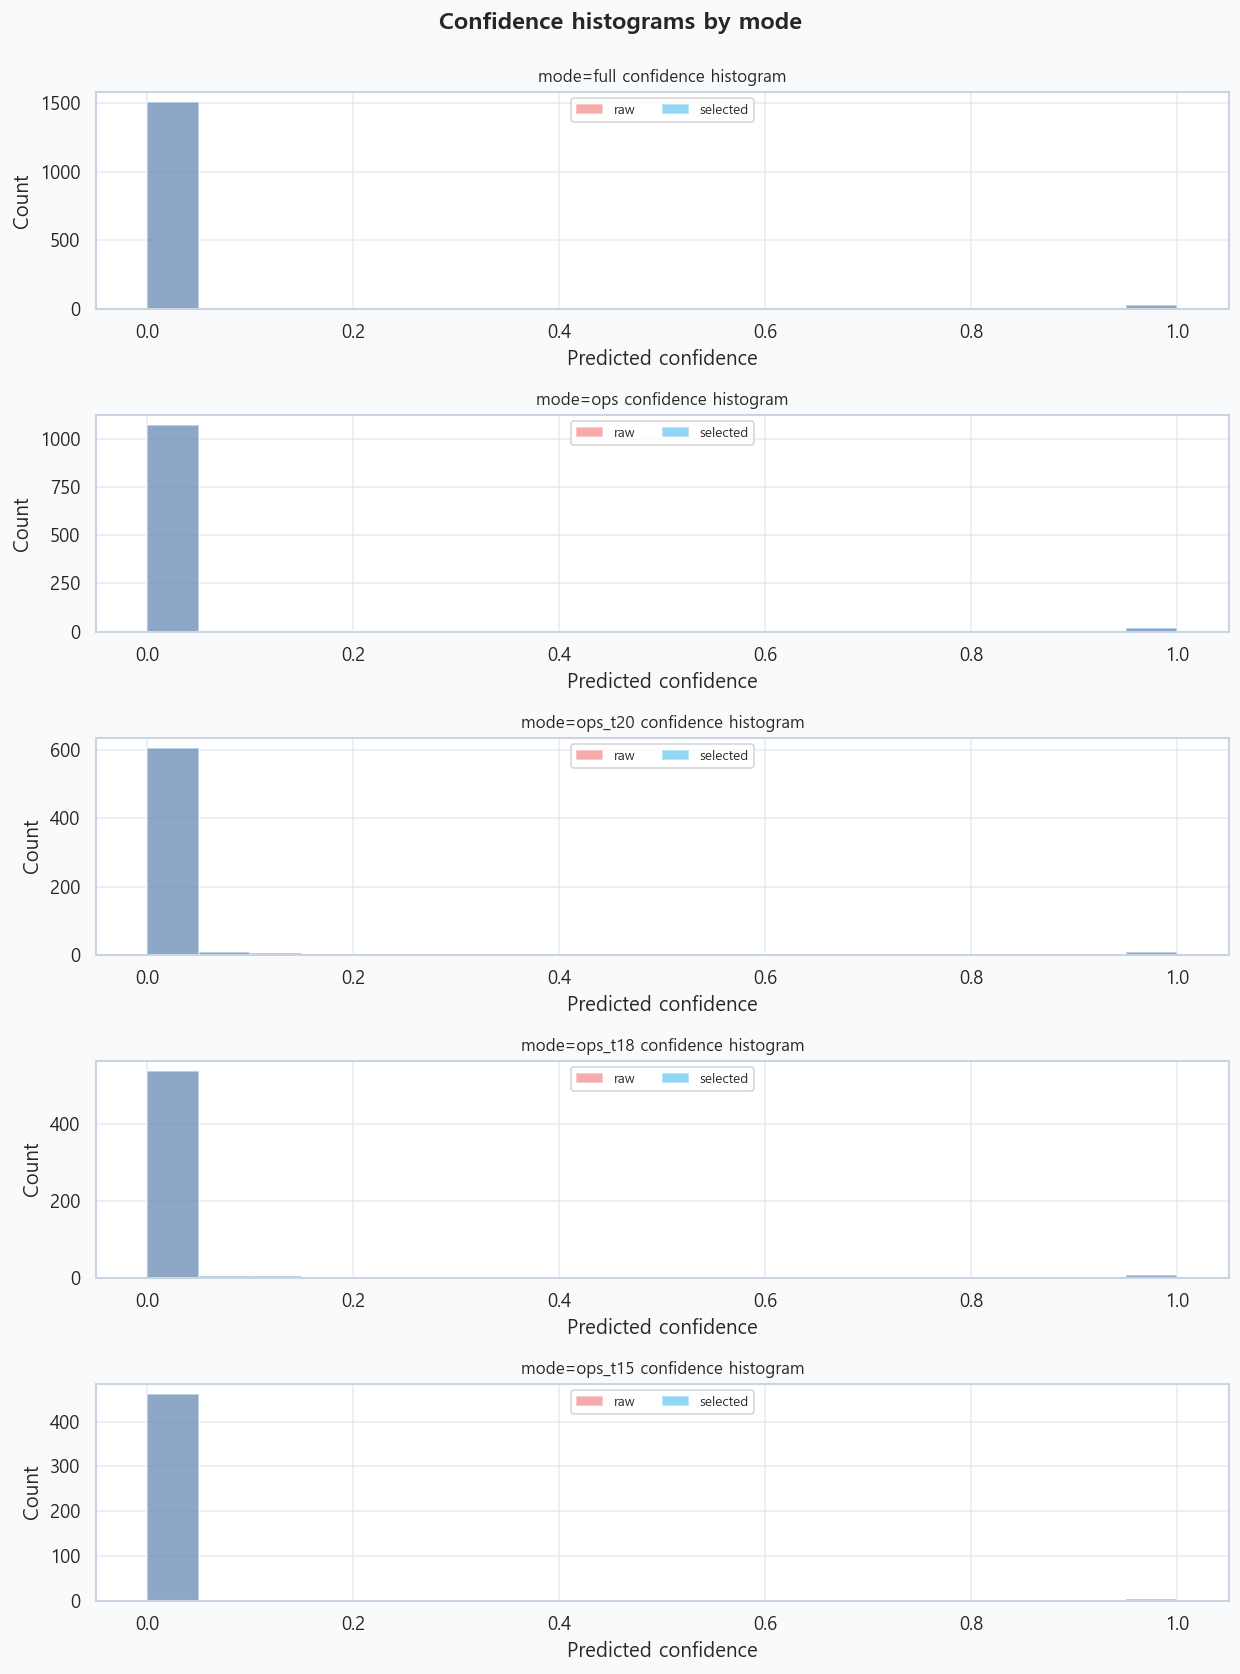

,stage,n_candidates,remove_ratio,mode,topk_useful_keep_proxy,stage_order,prev_candidates,drop_from_prev_ratio,raw_candidates,drop_from_raw_ratio
0,raw,7561,0.000000,full,0.00,0,NaN,NaN,7561,0.000000
1,S1_geometric,7561,0.000000,full,0.00,1,7561.0,0.000000,7561,0.000000
2,S2_temporal,7185,0.049729,full,0.00,2,7561.0,0.049729,7561,0.049729
3,S3_utility,6088,0.194816,full,0.00,3,7185.0,0.152679,7561,0.194816
4,raw,7561,0.000000,ops,0.02,0,NaN,NaN,7561,0.000000
5,S1_geometric,7561,0.000000,ops,0.02,1,7561.0,0.000000,7561,0.000000
6,S2_temporal,6629,0.123264,ops,0.02,2,7561.0,0.123264,7561,0.123264
7,S3_utility,4497,0.405237,ops,0.02,3,6629.0,0.321617,7561,0.405237
12,raw_ops_base,4497,0.000000,ops_t15,NaN,4,NaN,NaN,4497,0.000000
13,extra_gate_0.46,1758,0.609073,ops_t15,NaN,7,4497.0,0.609073,4497,0.609073


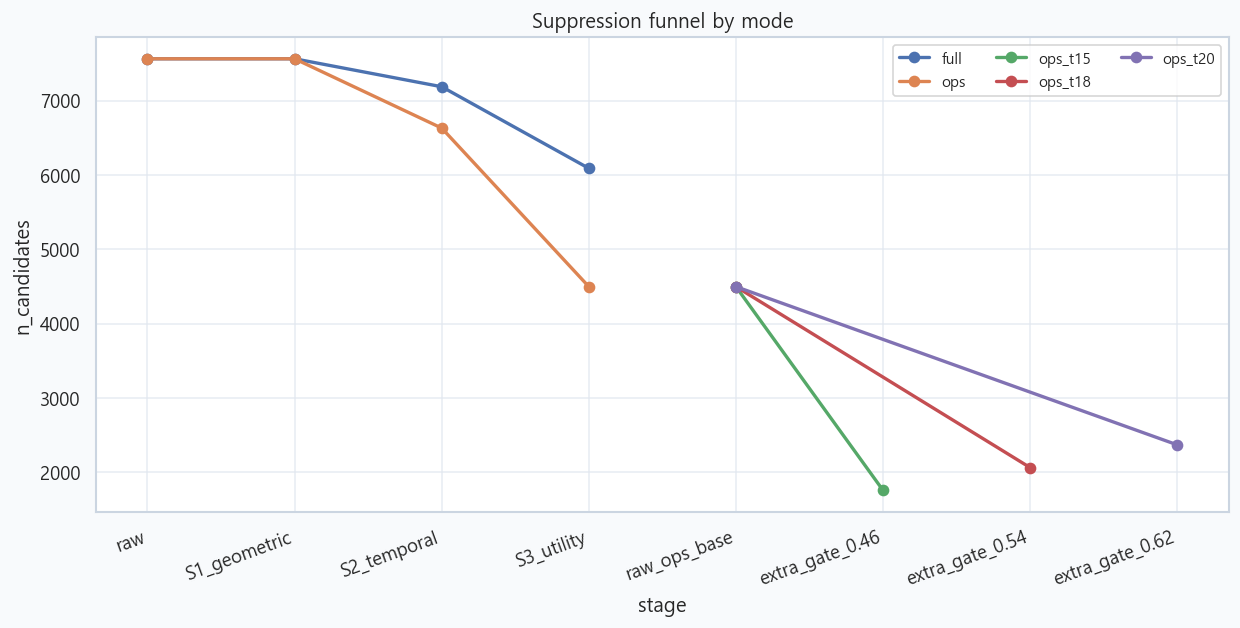

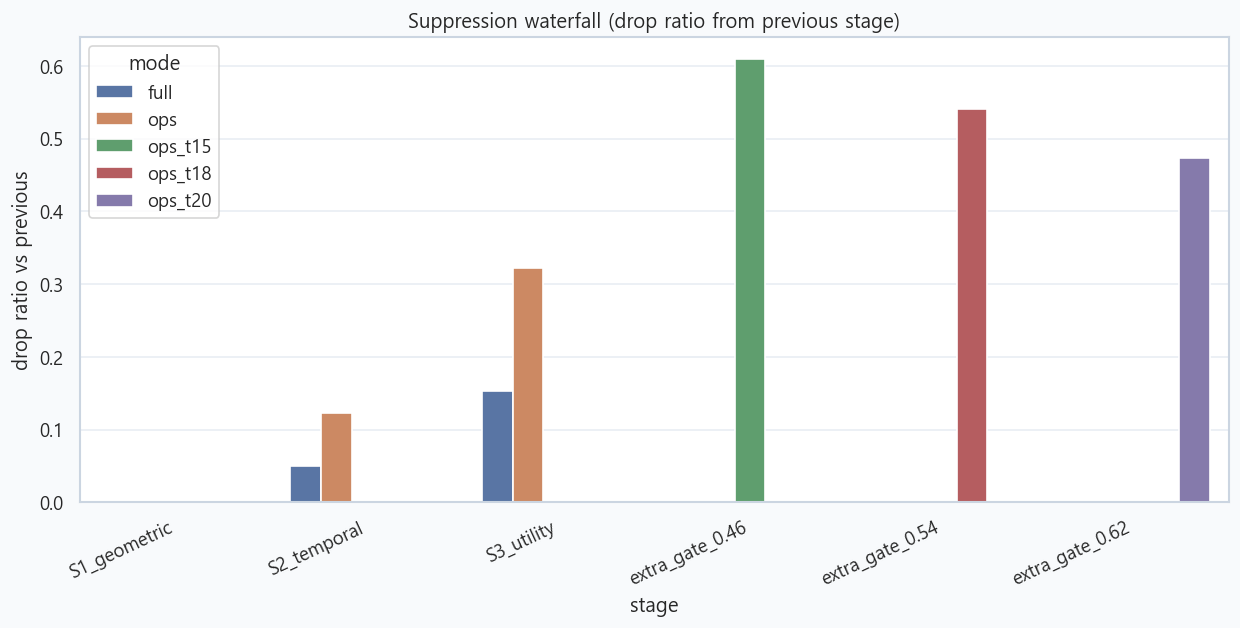

,mode,condition,pass_ratio,threshold,max_spread,min_range,n_pass
0,full,n_points,1.000000,3.0,NaN,NaN,NaN
1,full,spread_xy,1.000000,24.0,NaN,NaN,NaN
2,full,range_xy,1.000000,0.5,NaN,NaN,NaN
3,full,combined_S1,1.000000,NaN,NaN,NaN,NaN
4,ops,n_points,1.000000,4.0,NaN,NaN,NaN
5,ops,spread_xy,1.000000,18.0,NaN,NaN,NaN
6,ops,range_xy,1.000000,1.2,NaN,NaN,NaN
7,ops,combined_S1,1.000000,NaN,NaN,NaN,NaN
8,s1_sweep,strict_a,0.999471,5.0,15.0,1.2,7557.0
9,s1_sweep,strict_b,0.998810,6.0,12.0,1.5,7552.0


,mode,feature,feature_used,test,stat,p_value,effect_size_eps2,separability_status,mean_low,mean_medium,mean_high,median_low,median_medium,median_high,std_low,std_medium,std_high,count_low,count_medium,count_high
0,full,approach_score,approach_score_v22,kruskal,15.369241,4.598453e-04,0.002197,weak_or_none,0.554496,0.575952,0.568607,0.567696,0.566269,0.549065,1.328680e-01,1.238841e-01,1.080865e-01,5215,730,143
3,full,closing_consistency_score,closing_consistency_score,kruskal,106.059132,9.322922e-24,0.017101,useful,0.662971,0.594313,0.663317,0.645562,0.593963,0.693193,1.548110e-01,1.436741e-01,1.227216e-01,5215,730,143
2,full,motion_smoothness_score,motion_smoothness_score,kruskal,72.201528,2.097188e-16,0.011537,useful,0.238149,0.191994,0.224456,0.201241,0.176513,0.220263,1.344011e-01,7.031985e-02,1.063360e-01,5215,730,143
1,full,temporal_stability_score,temporal_stability_score_v22,kruskal,NaN,NaN,NaN,weak_or_none,0.852372,0.852372,0.852372,0.852372,0.852372,0.852372,0.000000e+00,0.000000e+00,1.110223e-16,5215,730,143
4,full,trajectory_risk_proxy,trajectory_risk_proxy,kruskal,84.996619,3.493162e-19,0.013640,useful,1.193331,1.310206,1.156772,1.138515,1.283609,1.060562,5.497860e-01,4.123051e-01,5.388937e-01,5215,730,143
5,ops,approach_score,approach_score_v22,kruskal,33.159490,6.302432e-08,0.006934,weak_or_none,0.580006,0.605061,0.564390,0.596717,0.595084,0.573477,1.385696e-01,1.077432e-01,1.221221e-01,3852,539,106
8,ops,closing_consistency_score,closing_consistency_score,kruskal,68.063926,1.659993e-15,0.014700,useful,0.672526,0.611119,0.690788,0.655459,0.613662,0.697241,1.555885e-01,1.356977e-01,1.383654e-01,3852,539,106
7,ops,motion_smoothness_score,motion_smoothness_score,kruskal,49.883298,1.472243e-11,0.010655,useful,0.239750,0.184835,0.218791,0.190889,0.180594,0.226856,1.435198e-01,5.497368e-02,8.327181e-02,3852,539,106
6,ops,temporal_stability_score,temporal_stability_score_v22,kruskal,-inf,NaN,0.000000,weak_or_none,0.852372,0.852372,0.852372,0.852372,0.852372,0.852372,2.220446e-16,1.110223e-16,1.110223e-16,3852,539,106
9,ops,trajectory_risk_proxy,trajectory_risk_proxy,kruskal,58.147576,2.362731e-13,0.012494,useful,1.212504,1.330781,1.221700,1.179703,1.264708,1.066575,5.773162e-01,4.084264e-01,7.028997e-01,3852,539,106


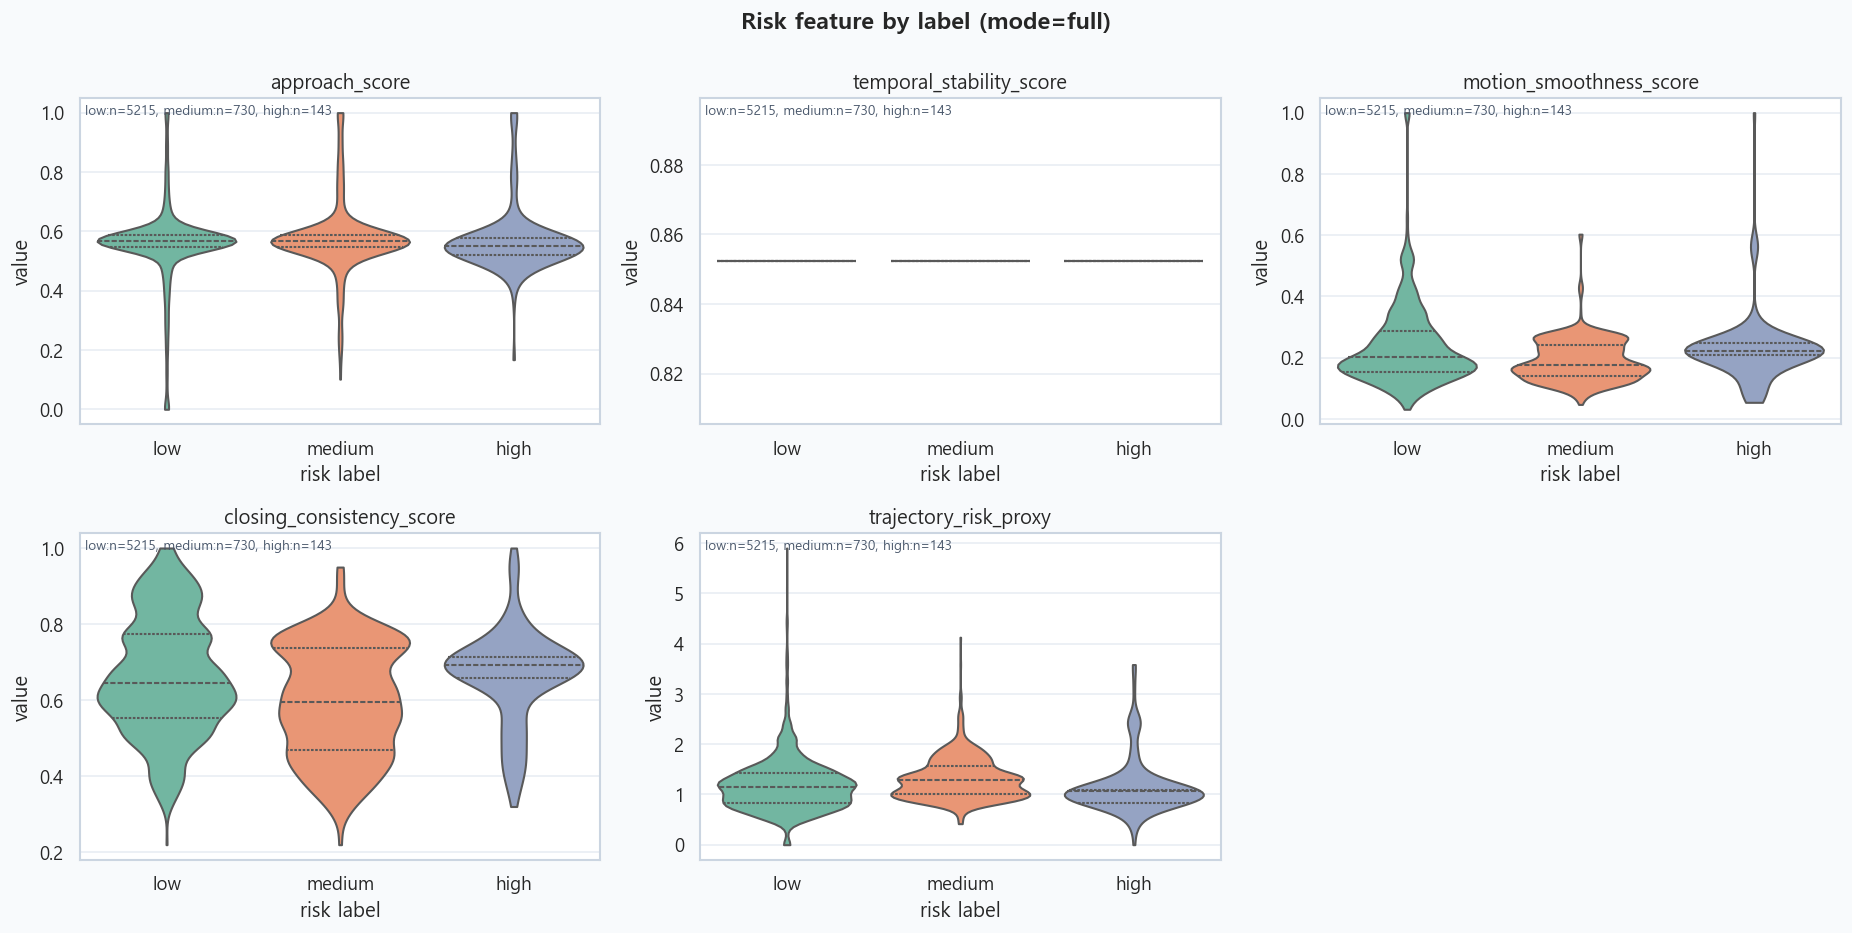

,mode,q,threshold,label_high_ratio,precision,recall
0,full,0.50,0.643500,0.500493,0.036757,0.783217
1,full,0.60,0.688048,0.400624,0.034440,0.587413
2,full,0.70,0.749021,0.305355,0.012372,0.160839
3,full,0.80,0.786285,0.203679,0.008871,0.076923
4,full,0.90,0.874407,0.100854,0.009772,0.041958
5,full,0.95,0.915671,0.051084,0.019293,0.041958
6,ops,0.50,0.650399,0.500778,0.032416,0.688679
7,ops,0.60,0.704587,0.400044,0.028905,0.490566
8,ops,0.70,0.752563,0.301757,0.017686,0.226415
9,ops,0.80,0.795156,0.200133,0.026667,0.226415


,metric,direction,weight
0,noise_ratio,lower is better,-1.000
1,mean_clusters_per_frame,higher is better (clip),0.040
2,mean_spread_xy,lower is better,-0.001


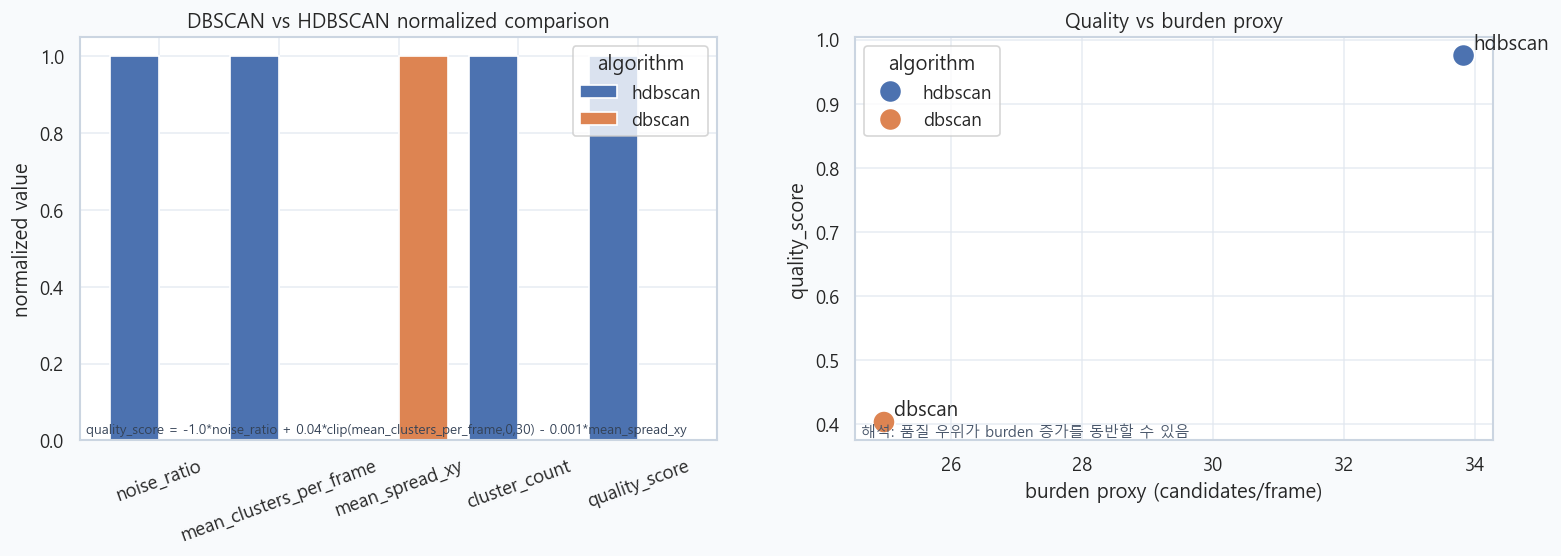

,mode,retained_candidates,burden_candidates_per_frame,suppression_strength,high_risk_retention_vs_full,precision@10_hard,ap_soft,ece_selected,brier_selected,quality_index,calibration_warning
4,ops_t15,1758,9.876404,0.609073,0.426573,1.0,0.832818,0.042912,0.042918,1.307380,ops_t15 정보량 부족 가능성
3,ops_t18,2064,11.595506,0.541027,0.503497,1.0,0.827895,0.046196,0.044881,1.303440,
2,ops_t20,2370,13.314607,0.472982,0.573427,1.0,0.817515,0.040677,0.042196,1.302599,
1,ops,4497,25.122905,0.405237,0.825175,1.0,0.917996,0.056008,0.055866,1.333594,
0,full,6088,33.822222,0.194816,1.000000,1.0,0.917942,0.049727,0.049413,1.337341,


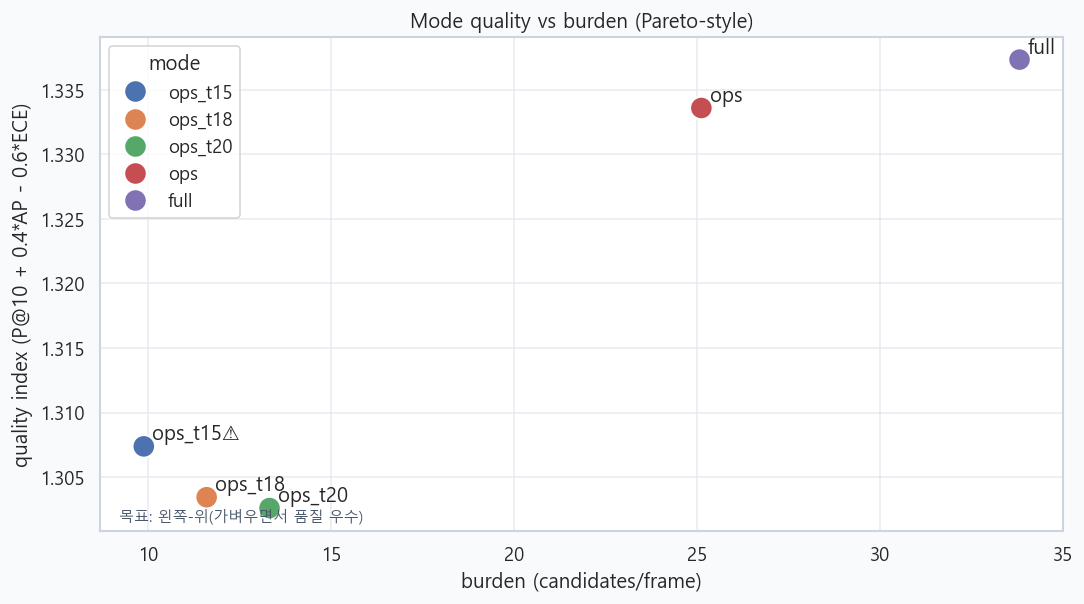

,recommendation_type,mode,research_score,demo_score,quality_index,burden_candidates_per_frame,calibration_warning
0,research_exploration,full,1.337341,0.660896,1.337341,33.822222,
1,ops_demo,ops_t18,1.303440,1.071530,1.303440,11.595506,


,question,answer
0,왜 어떤 feature는 죽었는가?,dead 판정 10개. zero_ratio/unique/variance 이상과 짧은...
1,왜 어떤 suppression stage는 효과가 없었는가?,S1에서 raw와 동일 후보 수 mode=2개. 조건 분해표에서 느슨한 조건 여부 ...
2,Reliability가 좋아 보이는 mode가 진짜 좋은가?,경고 mode 1개. bin count 포함 reliability와 confiden...
3,DBSCAN보다 HDBSCAN 선택이 타당한가?,품질식/가중치 공개 + burden 동시 시각화(dbscan_hdbscan_trad...
4,실전 데모에 가장 균형 좋은 mode는?,"v22 종합지표 상위 후보: ['full', 'ops']. Pareto scatte..."


WindowsPath('C:/Users/taehu/Desktop/projects/hanhwa_final/vod-devkit/results/tables/v22_qa_summary_v22.csv')

In [21]:
core_features = [
    "approach_score",
    "temporal_stability_score",
    "motion_smoothness_score",
    "closing_consistency_score",
    "trajectory_risk_proxy",
]

# A) feature health check
feature_rows = []
feature_step_rows = []
for m, R in RESULTS.items():
    d_corr = _first_df_attr(R, ["cluster_df_corr"])
    d_trk = _first_df_attr(R, ["cluster_df_tracked", "track_obs_selected", "track_obs_improved", "track_obs_baseline"])
    d_fin = _first_df_attr(R, ["cluster_df_final", "cluster_df_calibrated", "cluster_df_rule"])

    for step_name, d in [("input", d_corr), ("tracked", d_trk), ("final", d_fin)]:
        for f in ["approach_score", "temporal_stability_score"]:
            if f in d.columns:
                st = _series_stats(d[f])
                feature_step_rows.append({"mode": m, "step": step_name, "feature": f, **st})

    for f in ["approach_score", "temporal_stability_score"]:
        if f in d_trk.columns:
            raw = pd.to_numeric(d_trk[f], errors="coerce")
            lo, hi = raw.quantile(0.01), raw.quantile(0.99)
            clip = raw.clip(lower=lo, upper=hi)
            mn, mx = float(clip.min(skipna=True)), float(clip.max(skipna=True))
            if pd.notna(mn) and pd.notna(mx) and mx > mn:
                scaled = (clip - mn) / (mx - mn)
            else:
                scaled = pd.Series(0.0, index=raw.index)
            post = scaled.fillna(0).clip(0, 1)
            feature_step_rows.append({"mode": m, "step": "scaling_proxy", "feature": f, **_series_stats(scaled)})
            feature_step_rows.append({"mode": m, "step": "post_fill_clip_proxy", "feature": f, **_series_stats(post)})

    if len(d_fin):
        if "approach_score" not in d_fin.columns or _series_stats(d_fin.get("approach_score", pd.Series(dtype=float))).get("zero_ratio", 1.0) > 0.95:
            d_fin["approach_score_v22"] = _reconstruct_approach_v22(d_fin)
        else:
            d_fin["approach_score_v22"] = pd.to_numeric(d_fin["approach_score"], errors="coerce").fillna(0)
        if "temporal_stability_score" not in d_fin.columns or _series_stats(d_fin.get("temporal_stability_score", pd.Series(dtype=float))).get("zero_ratio", 1.0) > 0.95:
            d_fin["temporal_stability_score_v22"] = _reconstruct_temporal_stability_v22(d_fin)
        else:
            d_fin["temporal_stability_score_v22"] = pd.to_numeric(d_fin["temporal_stability_score"], errors="coerce").fillna(0)
        R.cluster_df_final = d_fin

    for f in core_features:
        if f in d_fin.columns:
            st = _series_stats(d_fin[f])
            feature_rows.append({"mode": m, "feature": f, **st, "health": _health_label(st)})

feature_health_check_df = pd.DataFrame(feature_rows)
feature_step_diag_df = pd.DataFrame(feature_step_rows)
display(feature_health_check_df.sort_values(["mode", "feature"]))
display(feature_step_diag_df.sort_values(["mode", "feature", "step"]))
save_table(feature_health_check_df, "feature_health_check")

if len(feature_health_check_df):
    pv = feature_health_check_df.pivot_table(index="feature", columns="mode", values="zero_ratio", aggfunc="mean")
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    sns.heatmap(pv, annot=True, fmt=".2f", cmap="rocket_r", ax=ax, cbar_kws={"label": "zero ratio"})
    ax.set_title("Feature health check (zero ratio)")
    ax.set_xlabel("mode")
    ax.set_ylabel("feature")
    save_fig("feature_health_check")
    plt.show()

root_rows = []
for m in sorted(feature_step_diag_df["mode"].dropna().unique()):
    sub = feature_step_diag_df[(feature_step_diag_df["mode"] == m) & (feature_step_diag_df["step"] == "final")]
    d_fin = _first_df_attr(RESULTS[m], ["cluster_df_final", "cluster_df_calibrated", "cluster_df_rule"])
    track_short = bool("track_len" in d_fin.columns and pd.to_numeric(d_fin["track_len"], errors="coerce").fillna(1).median() <= 2)
    for f in ["approach_score", "temporal_stability_score"]:
        sf = sub[sub["feature"] == f]
        if len(sf) == 0:
            continue
        z = float(sf["zero_ratio"].iloc[0])
        u = int(sf["unique_count"].iloc[0])
        reason = []
        if z > 0.95:
            reason.append("zero ratio 높음")
        if u <= 2:
            reason.append("unique 값 부족")
        if track_short:
            reason.append("짧은 track_len로 rolling 계산 무효 가능")
        if not reason:
            reason.append("분포 존재, 구분력 추가 검증 필요")
        root_rows.append({"mode": m, "feature": f, "diagnosis": "; ".join(reason)})
feature_root_cause_df = pd.DataFrame(root_rows)
display(feature_root_cause_df)
save_table(feature_root_cause_df, "feature_root_cause_summary")

# B) calibration summary
cal_rows = []
cal_plot_rows = []
for m, R in RESULTS.items():
    cb = getattr(R, "calibration_bundle", {}) if hasattr(R, "calibration_bundle") else {}
    d_rule = _first_df_attr(R, ["cluster_df_rule", "cluster_df_final", "cluster_df_calibrated"])
    if len(d_rule) and "risk_label_rule_v2" in d_rule.columns:
        y = (d_rule["risk_label_rule_v2"].astype(str) == "high").astype(int).to_numpy()
    elif len(d_rule) and "risk_label_rule" in d_rule.columns:
        y = (d_rule["risk_label_rule"].astype(str) == "high").astype(int).to_numpy()
    else:
        y = np.zeros(0, dtype=int)

    p_raw = np.asarray(cb.get("p_raw", np.zeros_like(y, dtype=float)), dtype=float)
    p_sel = np.asarray(cb.get("p_selected", p_raw), dtype=float)
    n = min(len(y), len(p_raw), len(p_sel))
    y = y[:n]
    p_raw = p_raw[:n]
    p_sel = p_sel[:n]

    m_raw, b_raw = _calibration_metrics(y, p_raw, n_bins=10)
    m_sel, b_sel = _calibration_metrics(y, p_sel, n_bins=10)

    warning = ""
    if (m_sel["total_samples"] < 200) or (m_sel["n_bins_used"] <= 3):
        warning = "샘플/유효 bin 부족"
    if m == "ops_t15" and (m_sel["n_bins_used"] <= 2 or m_sel["total_samples"] < 300):
        warning = "ops_t15 정보량 부족 가능성"

    cal_rows.append({
        "mode": m,
        "ece_raw": m_raw["ece"],
        "ece_selected": m_sel["ece"],
        "mce_raw": m_raw["mce"],
        "mce_selected": m_sel["mce"],
        "brier_raw": m_raw["brier"],
        "brier_selected": m_sel["brier"],
        "n_bins_used_raw": m_raw["n_bins_used"],
        "n_bins_used_selected": m_sel["n_bins_used"],
        "total_samples": m_sel["total_samples"],
        "warning": warning,
    })
    cal_plot_rows.append({
        "mode": m,
        "bin_raw": b_raw,
        "bin_selected": b_sel,
        "p_raw": p_raw,
        "p_selected": p_sel,
        "warning": warning,
    })

calibration_summary_df = pd.DataFrame(cal_rows).sort_values("mode")
display(calibration_summary_df)
save_table(calibration_summary_df, "calibration_summary")

if len(cal_plot_rows):
    _reliability_with_counts_plot(cal_plot_rows, filename="reliability_with_counts")
    _confidence_hist_by_mode(cal_plot_rows, filename="confidence_histograms_by_mode")

# C) suppression stage effectiveness
stage_df = _safe_df(suppression_summary_df)
if len(stage_df):
    stage_order = ["raw", "S1_geometric", "S2_temporal", "S3_utility", "raw_ops_base", "extra_gate_0.62", "extra_gate_0.54", "extra_gate_0.46"]
    stage_df["stage_order"] = stage_df["stage"].map({s: i for i, s in enumerate(stage_order)}).fillna(999)
    stage_df = stage_df.sort_values(["mode", "stage_order", "n_candidates"]).copy()
    stage_df["prev_candidates"] = stage_df.groupby("mode")["n_candidates"].shift(1)
    stage_df["drop_from_prev_ratio"] = (1 - stage_df["n_candidates"] / stage_df["prev_candidates"]).replace([np.inf, -np.inf], np.nan)
    stage_df["raw_candidates"] = stage_df.groupby("mode")["n_candidates"].transform("max")
    stage_df["drop_from_raw_ratio"] = (1 - stage_df["n_candidates"] / stage_df["raw_candidates"]).clip(0, 1)
    display(stage_df)
    save_table(stage_df, "suppression_stage_effectiveness")

    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    for mode_name in stage_df["mode"].unique():
        ss = stage_df[stage_df["mode"] == mode_name].sort_values("stage_order")
        ax.plot(ss["stage"], ss["n_candidates"], marker="o", lw=2, label=mode_name)
    ax.set_title("Suppression funnel by mode")
    ax.set_ylabel("n_candidates")
    ax.set_xlabel("stage")
    plt.xticks(rotation=20, ha="right")
    ax.legend(ncol=3, fontsize=9)
    plt.tight_layout()
    save_fig("suppression_funnel")
    plt.show()

    fig, ax = plt.subplots(figsize=(10.5, 5.4))
    wf = stage_df.dropna(subset=["drop_from_prev_ratio"]).copy()
    sns.barplot(data=wf, x="stage", y="drop_from_prev_ratio", hue="mode", ax=ax)
    ax.set_title("Suppression waterfall (drop ratio from previous stage)")
    ax.set_xlabel("stage")
    ax.set_ylabel("drop ratio vs previous")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    save_fig("suppression_waterfall")
    plt.show()

s1_rows = []
if "cluster_df_raw" in globals() and isinstance(cluster_df_raw, pd.DataFrame) and len(cluster_df_raw):
    cfgs = {
        "full": (3, 24.0, 0.5),
        "ops": (4, 18.0, 1.2),
    }
    for mode_name, (min_pts, max_spread, min_range) in cfgs.items():
        d0 = cluster_df_raw.copy()
        c1 = d0["n_points"] >= min_pts
        c2 = d0["spread_xy"] <= max_spread
        c3 = d0["range_xy"] >= min_range
        comb = c1 & c2 & c3
        s1_rows.extend([
            {"mode": mode_name, "condition": "n_points", "pass_ratio": float(c1.mean()), "threshold": min_pts},
            {"mode": mode_name, "condition": "spread_xy", "pass_ratio": float(c2.mean()), "threshold": max_spread},
            {"mode": mode_name, "condition": "range_xy", "pass_ratio": float(c3.mean()), "threshold": min_range},
            {"mode": mode_name, "condition": "combined_S1", "pass_ratio": float(comb.mean()), "threshold": np.nan},
        ])

    sweep_cfg = [
        ("strict_a", 5, 15.0, 1.2),
        ("strict_b", 6, 12.0, 1.5),
        ("loose", 3, 24.0, 0.5),
    ]
    for tag, min_pts, max_spread, min_range in sweep_cfg:
        c = (cluster_df_raw["n_points"] >= min_pts) & (cluster_df_raw["spread_xy"] <= max_spread) & (cluster_df_raw["range_xy"] >= min_range)
        s1_rows.append({
            "mode": "s1_sweep",
            "condition": tag,
            "pass_ratio": float(c.mean()),
            "threshold": float(min_pts),
            "max_spread": float(max_spread),
            "min_range": float(min_range),
            "n_pass": int(c.sum()),
        })
s1_diag_df = pd.DataFrame(s1_rows)
if len(s1_diag_df):
    display(s1_diag_df)
    save_table(s1_diag_df, "s1_geometric_condition_breakdown")

# D) label separability
sep_rows = []
risk_plot_rows = []
label_order = ["low", "medium", "high"]
for m, R in RESULTS.items():
    d = _first_df_attr(R, ["cluster_df_final", "cluster_df_calibrated", "cluster_df_rule"])
    if len(d) == 0 or "risk_label_rule_v2" not in d.columns:
        continue
    d = d.copy()
    d["risk_label_rule_v2"] = d["risk_label_rule_v2"].astype(str)

    if "approach_score_v22" not in d.columns:
        d["approach_score_v22"] = _reconstruct_approach_v22(d)
    if "temporal_stability_score_v22" not in d.columns:
        d["temporal_stability_score_v22"] = _reconstruct_temporal_stability_v22(d)

    feature_map = {
        "approach_score": "approach_score_v22" if _series_stats(d.get("approach_score", pd.Series(dtype=float))).get("zero_ratio", 1.0) > 0.95 else "approach_score",
        "temporal_stability_score": "temporal_stability_score_v22" if _series_stats(d.get("temporal_stability_score", pd.Series(dtype=float))).get("zero_ratio", 1.0) > 0.95 else "temporal_stability_score",
        "motion_smoothness_score": "motion_smoothness_score",
        "closing_consistency_score": "closing_consistency_score",
        "trajectory_risk_proxy": "trajectory_risk_proxy",
    }

    for f_key, f_col in feature_map.items():
        if f_col not in d.columns:
            continue
        vals = pd.to_numeric(d[f_col], errors="coerce")
        tmp = d[["risk_label_rule_v2"]].copy()
        tmp[f_key] = vals
        tmp = tmp.dropna(subset=[f_key])
        groups = [tmp.loc[tmp["risk_label_rule_v2"] == lb, f_key].values for lb in label_order if (tmp["risk_label_rule_v2"] == lb).any()]
        n = int(len(tmp))
        pval = np.nan
        stat = np.nan
        eps2 = np.nan
        test_name = "none"
        if len(groups) >= 2 and min(len(g) for g in groups) >= 5 and kruskal is not None:
            H, pval = kruskal(*groups)
            stat = float(H)
            k = len(groups)
            eps2 = float(max((H - k + 1) / max(n - k, 1), 0))
            test_name = "kruskal"
        means = {f"mean_{lb}": float(tmp.loc[tmp["risk_label_rule_v2"] == lb, f_key].mean()) if (tmp["risk_label_rule_v2"] == lb).any() else np.nan for lb in label_order}
        meds = {f"median_{lb}": float(tmp.loc[tmp["risk_label_rule_v2"] == lb, f_key].median()) if (tmp["risk_label_rule_v2"] == lb).any() else np.nan for lb in label_order}
        stds = {f"std_{lb}": float(tmp.loc[tmp["risk_label_rule_v2"] == lb, f_key].std(ddof=0)) if (tmp["risk_label_rule_v2"] == lb).any() else np.nan for lb in label_order}
        cnts = {f"count_{lb}": int((tmp["risk_label_rule_v2"] == lb).sum()) for lb in label_order}
        status = "useful" if (pd.notna(pval) and pval < 0.05 and pd.notna(eps2) and eps2 >= 0.01) else "weak_or_none"
        sep_rows.append({
            "mode": m,
            "feature": f_key,
            "feature_used": f_col,
            "test": test_name,
            "stat": stat,
            "p_value": pval,
            "effect_size_eps2": eps2,
            "separability_status": status,
            **means,
            **meds,
            **stds,
            **cnts,
        })
        risk_plot_rows.append(tmp.assign(mode=m, feature=f_key).rename(columns={f_key: "value"}))

label_separability_summary_df = pd.DataFrame(sep_rows)
display(label_separability_summary_df.sort_values(["mode", "feature"]))
save_table(label_separability_summary_df, "label_separability_summary")

if len(risk_plot_rows):
    risk_plot_df = pd.concat(risk_plot_rows, ignore_index=True)
    target_mode = "full" if "full" in risk_plot_df["mode"].unique() else str(risk_plot_df["mode"].iloc[0])
    rp = risk_plot_df[risk_plot_df["mode"] == target_mode].copy()
    feats = [f for f in ["approach_score", "temporal_stability_score", "motion_smoothness_score", "closing_consistency_score", "trajectory_risk_proxy"] if f in rp["feature"].unique()]
    ncol = 3
    nrow = int(math.ceil(len(feats) / ncol)) if feats else 1
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.2 * ncol, 3.9 * nrow), squeeze=False)
    axes = axes.ravel()
    for i, f in enumerate(feats):
        ax = axes[i]
        tmp = rp[rp["feature"] == f]
        sns.violinplot(data=tmp, x="risk_label_rule_v2", y="value", order=label_order, inner="quartile", cut=0, ax=ax, palette="Set2")
        ax.set_title(f)
        ax.set_xlabel("risk label")
        ax.set_ylabel("value")
        n_txt = ", ".join([f"{lb}:n={(tmp['risk_label_rule_v2']==lb).sum()}" for lb in label_order])
        ax.text(0.01, 0.98, n_txt, transform=ax.transAxes, ha="left", va="top", fontsize=8, color="#475569")
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])
    fig.suptitle(f"Risk feature by label (mode={target_mode})", fontsize=14, fontweight="bold", y=0.995)
    plt.tight_layout()
    save_fig("risk_feature_by_label")
    plt.show()

closing_rows = []
for m, R in RESULTS.items():
    d = _first_df_attr(R, ["cluster_df_final", "cluster_df_calibrated", "cluster_df_rule"])
    if len(d) == 0 or "closing_consistency_score" not in d.columns:
        continue
    y = (d.get("risk_label_rule_v2", pd.Series("low", index=d.index)).astype(str) == "high").astype(int)
    s = pd.to_numeric(d["closing_consistency_score"], errors="coerce")
    valid = s.notna()
    y = y[valid]
    s = s[valid]
    for q in [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]:
        thr = float(s.quantile(q)) if len(s) else np.nan
        pred = (s >= thr).astype(int) if len(s) else pd.Series(dtype=int)
        tp = int(((pred == 1) & (y == 1)).sum())
        fp = int(((pred == 1) & (y == 0)).sum())
        fn = int(((pred == 0) & (y == 1)).sum())
        precision = float(tp / max(tp + fp, 1))
        recall = float(tp / max(tp + fn, 1))
        closing_rows.append({
            "mode": m,
            "q": q,
            "threshold": thr,
            "label_high_ratio": float(pred.mean()) if len(pred) else np.nan,
            "precision": precision,
            "recall": recall,
        })
closing_sensitivity_df = pd.DataFrame(closing_rows)
display(closing_sensitivity_df)
save_table(closing_sensitivity_df, "closing_consistency_sensitivity")

# E) dbscan/hdbscan and mode tradeoff
if "cluster_algo_summary" in globals() and isinstance(cluster_algo_summary, pd.DataFrame) and len(cluster_algo_summary):
    formula_text = "quality_score = -1.0*noise_ratio + 0.04*clip(mean_clusters_per_frame,0,30) - 0.001*mean_spread_xy"
    weights_df = pd.DataFrame([
        {"metric": "noise_ratio", "direction": "lower is better", "weight": -1.0},
        {"metric": "mean_clusters_per_frame", "direction": "higher is better (clip)", "weight": +0.04},
        {"metric": "mean_spread_xy", "direction": "lower is better", "weight": -0.001},
    ])
    display(weights_df)
    save_table(weights_df, "cluster_quality_weights")

    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))
    metric_cols = ["noise_ratio", "mean_clusters_per_frame", "mean_spread_xy", "cluster_count", "quality_score"]
    cdf = cluster_algo_summary.set_index("algorithm")[metric_cols].astype(float)
    norm = (cdf - cdf.min()) / (cdf.max() - cdf.min()).replace(0, np.nan)
    norm = norm.fillna(0.5)
    norm.T.plot(kind="bar", ax=axes[0], width=0.82)
    axes[0].set_title("DBSCAN vs HDBSCAN normalized comparison")
    axes[0].set_ylabel("normalized value")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].text(0.01, 0.01, formula_text, transform=axes[0].transAxes, ha="left", va="bottom", fontsize=8, color="#334155")

    if "ops_burden_preview_df" in globals() and len(ops_burden_preview_df):
        bd = ops_burden_preview_df.set_index("mode")["candidates_per_frame_after_suppression"].astype(float)
        algo_bd = pd.DataFrame({
            "algorithm": cluster_algo_summary["algorithm"].astype(str),
            "quality_score": cluster_algo_summary["quality_score"].astype(float),
            "burden_proxy": [float(bd.get("full", np.nan) if a == str(cluster_algo_summary.iloc[0]["algorithm"]) else bd.get("ops", np.nan)) for a in cluster_algo_summary["algorithm"].astype(str)]
        })
        sns.scatterplot(data=algo_bd, x="burden_proxy", y="quality_score", hue="algorithm", s=180, ax=axes[1])
        for _, r in algo_bd.iterrows():
            axes[1].annotate(str(r["algorithm"]), (r["burden_proxy"], r["quality_score"]), textcoords="offset points", xytext=(6, 4))
        axes[1].set_title("Quality vs burden proxy")
        axes[1].set_xlabel("burden proxy (candidates/frame)")
        axes[1].set_ylabel("quality_score")
        axes[1].text(0.01, 0.01, "해석: 품질 우위가 burden 증가를 동반할 수 있음", transform=axes[1].transAxes, fontsize=9, color="#475569")
    plt.tight_layout()
    save_fig("dbscan_hdbscan_tradeoff")
    plt.show()

mode_rows = []
full_high_uids = set()
if "full" in RESULTS:
    d_full = _first_df_attr(RESULTS["full"], ["cluster_df_final", "cluster_df_calibrated", "cluster_df_rule"])
    if "cluster_uid" in d_full.columns and "risk_label_rule_v2" in d_full.columns:
        full_high_uids = set(d_full.loc[d_full["risk_label_rule_v2"].astype(str) == "high", "cluster_uid"].astype(str))

for m, R in RESULTS.items():
    d_final = _first_df_attr(R, ["cluster_df_final", "cluster_df_calibrated", "cluster_df_rule"])
    retained = int(len(d_final))
    frame_n = int(d_final["frame_id"].nunique()) if (len(d_final) and "frame_id" in d_final.columns) else np.nan
    burden_pf = float(retained / max(frame_n, 1)) if frame_n == frame_n else np.nan

    rk = _first_df_attr(R, ["ranking_summary_df"])
    prec10 = np.nan
    ap_soft = np.nan
    if len(rk) and set(["metric", "value"]).issubset(rk.columns):
        dct = rk.set_index("metric")["value"].to_dict()
        prec10 = float(dct.get("precision@10_hard", np.nan))
        ap_soft = float(dct.get("ap_soft", np.nan))

    cal_row = calibration_summary_df[calibration_summary_df["mode"] == m]
    ece = float(cal_row["ece_selected"].iloc[0]) if len(cal_row) else np.nan
    brier = float(cal_row["brier_selected"].iloc[0]) if len(cal_row) else np.nan
    warn = str(cal_row["warning"].iloc[0]) if len(cal_row) else ""

    sup_mode = _safe_df(suppression_summary_df)
    if len(sup_mode):
        sub = sup_mode[sup_mode["mode"] == m].copy()
        if len(sub):
            raw_n = float(sub["n_candidates"].max())
            final_n = float(sub["n_candidates"].min())
            suppression_strength = float(1 - final_n / max(raw_n, 1))
        else:
            suppression_strength = np.nan
    else:
        suppression_strength = np.nan

    if full_high_uids and len(d_final) and "cluster_uid" in d_final.columns:
        uids = set(d_final["cluster_uid"].astype(str))
        high_retention = float(len(uids & full_high_uids) / max(len(full_high_uids), 1))
    else:
        high_retention = np.nan

    quality_index = float(np.nan_to_num(prec10, nan=0.0) + 0.4 * np.nan_to_num(ap_soft, nan=0.0) - 0.6 * np.nan_to_num(ece, nan=0.0))
    mode_rows.append({
        "mode": m,
        "retained_candidates": retained,
        "burden_candidates_per_frame": burden_pf,
        "suppression_strength": suppression_strength,
        "high_risk_retention_vs_full": high_retention,
        "precision@10_hard": prec10,
        "ap_soft": ap_soft,
        "ece_selected": ece,
        "brier_selected": brier,
        "quality_index": quality_index,
        "calibration_warning": warn,
    })

mode_tradeoff_summary_df = pd.DataFrame(mode_rows).sort_values("burden_candidates_per_frame")
display(mode_tradeoff_summary_df)
save_table(mode_tradeoff_summary_df, "mode_tradeoff_summary")

if len(mode_tradeoff_summary_df):
    fig, ax = plt.subplots(figsize=(9.2, 5.2))
    sns.scatterplot(data=mode_tradeoff_summary_df, x="burden_candidates_per_frame", y="quality_index", hue="mode", s=180, ax=ax)
    for _, r in mode_tradeoff_summary_df.iterrows():
        txt = str(r["mode"])
        if isinstance(r.get("calibration_warning", ""), str) and len(r.get("calibration_warning", "")):
            txt += "⚠"
        ax.annotate(txt, (r["burden_candidates_per_frame"], r["quality_index"]), textcoords="offset points", xytext=(5, 4))
    ax.set_title("Mode quality vs burden (Pareto-style)")
    ax.set_xlabel("burden (candidates/frame)")
    ax.set_ylabel("quality index (P@10 + 0.4*AP - 0.6*ECE)")
    ax.text(0.02, 0.02, "목표: 왼쪽-위(가벼우면서 품질 우수)", transform=ax.transAxes, fontsize=9, color="#475569")
    plt.tight_layout()
    save_fig("mode_quality_vs_burden")
    plt.show()

if len(mode_tradeoff_summary_df):
    rec_df = mode_tradeoff_summary_df.copy()
    rec_df["research_score"] = rec_df["quality_index"].fillna(-1e9)
    rec_df["demo_score"] = rec_df["quality_index"].fillna(-1e9) - 0.02 * rec_df["burden_candidates_per_frame"].fillna(0)
    rec_df.loc[rec_df["calibration_warning"].astype(str).str.len() > 0, "demo_score"] -= 0.05
    rec_research = rec_df.sort_values("research_score", ascending=False).head(1)
    rec_demo = rec_df.sort_values("demo_score", ascending=False).head(1)
    v22_recommendation_df = pd.concat([
        rec_research.assign(recommendation_type="research_exploration"),
        rec_demo.assign(recommendation_type="ops_demo"),
    ], ignore_index=True)
    display(v22_recommendation_df[["recommendation_type", "mode", "research_score", "demo_score", "quality_index", "burden_candidates_per_frame", "calibration_warning"]])
    save_table(v22_recommendation_df, "v22_recommendation")

qa_rows = []
if len(feature_health_check_df):
    dead_feats = feature_health_check_df[feature_health_check_df["health"] == "dead"]
    qa_rows.append({
        "question": "왜 어떤 feature는 죽었는가?",
        "answer": f"dead 판정 {len(dead_feats)}개. zero_ratio/unique/variance 이상과 짧은 track_len을 함께 점검.",
    })
if len(stage_df):
    s1 = stage_df[stage_df["stage"] == "S1_geometric"]
    raw = stage_df[stage_df["stage"] == "raw"]
    if len(s1) and len(raw):
        merge = s1[["mode", "n_candidates"]].merge(raw[["mode", "n_candidates"]], on="mode", suffixes=("_s1", "_raw"))
        same = int((merge["n_candidates_s1"] == merge["n_candidates_raw"]).sum())
        qa_rows.append({
            "question": "왜 어떤 suppression stage는 효과가 없었는가?",
            "answer": f"S1에서 raw와 동일 후보 수 mode={same}개. 조건 분해표에서 느슨한 조건 여부 확인 가능.",
        })
if len(calibration_summary_df):
    caut = calibration_summary_df[calibration_summary_df["warning"].astype(str).str.len() > 0]
    qa_rows.append({
        "question": "Reliability가 좋아 보이는 mode가 진짜 좋은가?",
        "answer": f"경고 mode {len(caut)}개. bin count 포함 reliability와 confidence histogram으로 착시를 배제.",
    })
if "cluster_algo_summary" in globals() and isinstance(cluster_algo_summary, pd.DataFrame) and len(cluster_algo_summary):
    qa_rows.append({
        "question": "DBSCAN보다 HDBSCAN 선택이 타당한가?",
        "answer": "품질식/가중치 공개 + burden 동시 시각화(dbscan_hdbscan_tradeoff)로 타당성 검증.",
    })
if len(mode_tradeoff_summary_df):
    best_demo = mode_tradeoff_summary_df.sort_values("quality_index", ascending=False).head(2)["mode"].astype(str).tolist()
    qa_rows.append({
        "question": "실전 데모에 가장 균형 좋은 mode는?",
        "answer": f"v22 종합지표 상위 후보: {best_demo}. Pareto scatter로 ops_t18/ops_t20 우선 검토.",
    })
v22_qa_summary_df = pd.DataFrame(qa_rows)
display(v22_qa_summary_df)
save_table(v22_qa_summary_df, "v22_qa_summary")

## Section 20.5. v22 핵심 결론 템플릿

- `feature_health_check_v22.csv` 기반으로 dead/weak/healthy 판정
- `calibration_summary_v22.csv` 및 reliability/count plot로 저표본 착시 경고
- `suppression_stage_effectiveness_v22.csv`와 funnel/waterfall로 stage 유효성 점검
- `mode_tradeoff_summary_v22.csv`와 Pareto scatter로 연구용/운영용 mode 분리 추천

## Section 20. 한국어 결론

### 1) 본 노트북의 최종 성격
이 노트북은 단순 실행 코드가 아니라, **데이터 로딩부터 최종 의사결정까지를 추적 가능한 실험 보고서**로 구성했다. 각 단계에서 `표 + describe + head + plot`을 남겨, 제3자가 결과를 재검증할 수 있도록 했다.

### 2) research_full vs ops 모드 분리 원칙
`research_full`은 분석/설명력을 우선하고, `ops` 계열은 운영 부담(burden) 제약을 우선한다. 따라서 하나의 점수만으로 우열을 단정하지 않고, 목적 함수가 다른 두 트랙을 분리 요약해 의사결정 혼선을 줄였다.

### 3) anti-leakage를 결과 해석의 전제조건으로 고정
feature set 단계에서 blacklist/rule-like/의심 패턴을 모두 assert로 점검하고, final summary에서도 honest split + anti-leakage feature set만 허용하도록 강제했다. 즉, 본 보고서의 결론은 누설 가능성을 최소화한 조건 위에서만 성립한다.

### 4) calibration 채택 정책의 보수적 재정의
calibration은 항상 쓰는 기능이 아니라, **raw 대비 실제 개선(Brier/ECE 비열화 + 최소 1개 엄격 개선)**이 확인될 때만 채택한다. 개선이 없으면 즉시 raw로 fallback하여, 보기 좋은 확률 대신 신뢰 가능한 확률을 유지했다.

### 5) rule_only vs hybrid를 솔직하게 기록
hybrid는 평균적으로 우선순위화(AP/NDCG 등)에서 이득을 줄 수 있지만, 모든 상황에서 rule_only를 지배하지는 않는다. 따라서 본 노트북은 hybrid의 개선 케이스뿐 아니라 trade-off(부담 증가 가능성, 소표본 완벽점수 위험)까지 함께 기록해 과대해석을 피했다.

### 6) temporal feature의 실질 기여 확인
temporal feature는 분포/라벨별 차이/점수 상관/top-k 이동량으로 다층 검증했다. 단순히 "temporal을 넣었다"가 아니라, 어떤 feature가 얼마나 순위에 기여했는지 수치로 남겨 후속 개선 우선순위를 제시했다.

### 7) 최종 요약의 무결성
`best_model_summary_overall`과 `best_model_summary_honest`를 분리해, "최고 성능"과 "정직한 성능"을 혼용하지 않도록 수정했다. final summary는 source trace와 1:1 매핑되며, mismatch 시 즉시 실패하도록 assert를 넣어 summary bug를 구조적으로 방지했다.

### 8) 운영 관점 최종 제언
실제 운영에서는 단일 정확도보다 **정직한 평가 + 부담 제어 + 상위 위험 후보 품질**이 중요하다. 따라서 권장 절차는 (1) honest 기준 모델 선택, (2) calibration 조건부 채택, (3) ops 모드 operating point 선택, (4) 주기적 temporal/ablation 재평가 순서다.

### 9) 본 보고서의 지향점
최종 목표는 "완벽한 분류기"가 아니라, **고위험 후보를 안정적으로 상위에 배치하고 운영 가능한 비용으로 전달하는 하이브리드 파이프라인**이다. 이 문서는 그 목표를 재현 가능하고 검증 가능한 형태로 제공한다.


In [22]:

need = [
    TABLE_DIR / "sec19_best_model_summary_overall.csv",
    TABLE_DIR / "sec19_best_model_summary_honest.csv",
    TABLE_DIR / "sec19_final_summary_research_vs_ops.csv",
    TABLE_DIR / "sec19_ops_summary_source_trace.csv",
    TABLE_DIR / "sec18_temporal_effectiveness_report.csv",
]
ok = all(p.exists() for p in need)
print("[완료] 핵심 산출물 확인:", ok)
if not ok:
    missing = [str(p) for p in need if not p.exists()]
    print("[누락 파일]", missing)


[완료] 핵심 산출물 확인: True
